In [ ]:
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.stats.contingency_tables import Table2x2
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
import itertools
from scipy import stats
from sklearn.metrics import make_scorer
import random
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import math
import xgboost as xgb
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import precision_recall_curve, auc, average_precision_score
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer


from sklearn.feature_selection import SequentialFeatureSelector
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import LearningCurveDisplay

import pickle

from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.combine import SMOTEENN
from imblearn.under_sampling import RepeatedEditedNearestNeighbours
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.over_sampling import ADASYN
from imblearn.over_sampling import SVMSMOTE

import time




## Exploration

In [ ]:
metadata  = pd.read_csv('/content/metadata.csv')
microbiome = pd.read_csv('/content/microbiome.csv')
serum_lipo = pd.read_csv('/content/serum_lipo.csv')

In [ ]:
metadata['is_sick'] = (metadata['PATGROUPFINAL_C'] != '8').astype(int)
dummy_df = pd.get_dummies(metadata['PATGROUPFINAL_C'], prefix='disease')
metadata=pd.concat([metadata, dummy_df], axis=1)
dummy_df=pd.get_dummies(metadata['CENTER_C'])
metadata=pd.concat([metadata, dummy_df], axis=1)
for col in ['AGE', 'DDS']:
    metadata[col] = (metadata[col] - metadata[col].mean()) / metadata[col].std()

metadata

sample_ids = microbiome['SampleID']
taxa_columns = microbiome.drop(columns=['SampleID'])
taxa_rel_abundance = taxa_columns.div(taxa_columns.sum(axis=1), axis=0)
microbiome = pd.concat([sample_ids, taxa_rel_abundance], axis=1)


sample_ids_met = serum_lipo['SampleID']
metabolite_columns = serum_lipo.drop(columns=['SampleID'])
scaler = StandardScaler()
metabolites_standardized = pd.DataFrame(
    scaler.fit_transform(metabolite_columns),
    columns=metabolite_columns.columns
)
metabolites = pd.concat([sample_ids_met, metabolites_standardized], axis=1)
metadata

,SampleID,PATGROUPFINAL_C,GENDER,AGE,CENTER_C,SMOKE,pa_work_2cl,DDS,is_sick,disease_1,...,disease_2b,disease_3,disease_4,disease_5,disease_6,disease_7,disease_8,Danemark,France,Germany
0,x30MCx2308,5,NaN,NaN,Danemark,NaN,NaN,NaN,1,False,...,False,False,False,True,False,False,False,True,False,False
1,x30MCx3215,5,NaN,NaN,Danemark,NaN,NaN,NaN,1,False,...,False,False,False,True,False,False,False,True,False,False
2,x30MCx2753,5,NaN,NaN,Danemark,NaN,NaN,NaN,1,False,...,False,False,False,True,False,False,False,True,False,False
3,x12MCx2285,5,1.0,0.071241,France,0.0,0.0,0.388940,1,False,...,False,False,False,True,False,False,False,False,True,False
4,x30MCx1686,5,NaN,NaN,Danemark,NaN,NaN,NaN,1,False,...,False,False,False,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1378,x10MCx2541,2a,1.0,-0.865246,France,0.0,1.0,-1.429909,1,False,...,False,False,False,False,False,False,False,False,True,False
1379,x20MCx1729,2a,0.0,-0.709165,Germany,0.0,0.0,1.298365,1,False,...,False,False,False,False,False,False,False,False,False,True
1380,x10MCx2409,2a,0.0,0.305363,France,0.0,1.0,1.662135,1,False,...,False,False,False,False,False,False,False,False,True,False
1381,x20MCx2215,2a,0.0,-2.894302,Germany,0.0,1.0,-0.884254,1,False,...,False,False,False,False,False,False,False,False,False,True


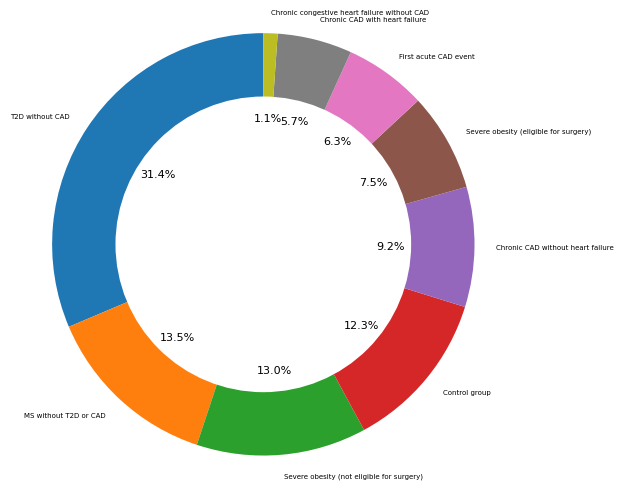

In [ ]:
patient_counts = metadata['PATGROUPFINAL_C'].value_counts(normalize=True)

name_conversion = {
    '1': "MS without T2D or CAD",
    '2a': "Severe obesity (not eligible for surgery)",
    '2b': "Severe obesity (eligible for surgery)",
    '3': "T2D without CAD",
    '4': "First acute CAD event",
    '5': "Chronic CAD without heart failure",
    '6': "Chronic CAD with heart failure",
    '7': "Chronic congestive heart failure without CAD",
    '8': "Control group"
}

plt.figure(figsize=(6, 5))
wedges, texts, autotexts = plt.pie(
    patient_counts,
    labels=[name_conversion.get(idx, str(idx)) for idx in patient_counts.index],
    autopct='%1.1f%%',
    startangle=90,
    shadow=False,
    textprops={'fontsize': 5}
)
plt.setp(autotexts, fontsize=8)

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.axis('equal')
plt.tight_layout()
plt.show()

In [ ]:
name_conversion = {
    '1': "MS w/o T2D, CAD",
    '2a': "Severe obesity (no surgery)",
    '2b': "Severe obesity (surgery elig.)",
    '3': "T2D w/o CAD",
    '4': "1st acute CAD event",
    '5': "Chronic CAD w/o heart fail",
    '6': "Chronic CAD w. heart fail",
    '7': "Chronic cong. heart fail w/o CAD",
    '8': "Control group"
}

age_clean = metadata.dropna(subset=['AGE'])

custom_order = ['1', '2a', '2b', '3', '4', '5', '6', '7', '8']

available_groups = [group for group in custom_order if group in age_clean['PATGROUPFINAL_C'].unique()]

plt.figure(figsize=(16, 8))
sns.boxplot(x='PATGROUPFINAL_C', y='AGE', data=age_clean, order=available_groups)

converted_labels = [name_conversion.get(group, group) for group in available_groups]
plt.xticks(range(len(available_groups)), converted_labels, rotation=45, ha='right')

plt.title('Distribution of Age by Patient Group', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Patient Group', fontsize=12)
plt.ylabel('Age', fontsize=12)
plt.tight_layout()

plt.show()


In [ ]:
for col in metadata.columns:
    print(f"{col} has {metadata[col].isna().sum()} missing values")
print("\n")
# Count total rows in your dataframe
total_rows = len(metadata)

# Count rows with no missing values at all
rows_with_no_missing = len(metadata.dropna(how='any'))

# Print the result
print(f"Total rows: {total_rows}")
print(f"Rows with no missing values: {rows_with_no_missing}")
print(f"Percentage of complete rows: {rows_with_no_missing/total_rows*100:.2f}%")

SampleID has 0 missing values
PATGROUPFINAL_C has 0 missing values
GENDER has 373 missing values
AGE has 373 missing values
CENTER_C has 0 missing values
SMOKE has 387 missing values
pa_work_2cl has 499 missing values
DDS has 552 missing values
is_sick has 0 missing values
disease_1 has 0 missing values
disease_2a has 0 missing values
disease_2b has 0 missing values
disease_3 has 0 missing values
disease_4 has 0 missing values
disease_5 has 0 missing values
disease_6 has 0 missing values
disease_7 has 0 missing values
disease_8 has 0 missing values
Danemark has 0 missing values
France has 0 missing values
Germany has 0 missing values


Total rows: 1383
Rows with no missing values: 799
Percentage of complete rows: 57.77%


In [ ]:
meta_metabo = pd.merge(metadata, serum_lipo, how = 'inner',on='SampleID')
merged = pd.merge(meta_metabo, microbiome, how = 'inner',on='SampleID')
merged=merged.drop(['SampleID'], axis=1)
merged

,PATGROUPFINAL_C,GENDER,AGE,CENTER_C,SMOKE,pa_work_2cl,DDS,is_sick,disease_1,disease_2a,...,CAG-1427 sp000436075,Phascolarctobacterium_A succinatutens_A,Dialister sp000434475,Megasphaera elsdenii,Prevotella sp002297965,Prevotella sp900556395,Prevotella sp900557035,Dialister sp002320515,Allisonella histaminiformans,Cryptobacteroides sp000434935
0,5,NaN,NaN,Danemark,NaN,NaN,NaN,1,False,False,...,0.001159,3.317461e-03,0.000008,5.709643e-06,5.566902e-05,0.006868,0.000190,0.000001,1.319562e-04,0.003551
1,5,NaN,NaN,Danemark,NaN,NaN,NaN,1,False,False,...,0.000001,3.009807e-06,0.000009,6.270430e-07,9.405645e-07,0.000001,0.000000,0.008000,7.524516e-07,0.000000
2,5,NaN,NaN,Danemark,NaN,NaN,NaN,1,False,False,...,0.000000,0.000000e+00,0.000000,0.000000e+00,3.663082e-06,0.000000,0.000002,0.000002,0.000000e+00,0.000000
3,5,1.0,0.071241,France,0.0,0.0,0.388940,1,False,False,...,0.000002,2.612790e-03,0.000000,7.667478e-06,1.323881e-06,0.000009,0.000012,0.000001,5.516171e-07,0.006388
4,5,NaN,NaN,Danemark,NaN,NaN,NaN,1,False,False,...,0.000255,1.858951e-06,0.000000,0.000000e+00,1.006932e-06,0.000003,0.000000,0.000000,0.000000e+00,0.000002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1378,2a,1.0,-0.865246,France,0.0,1.0,-1.429909,1,False,True,...,0.000979,3.385395e-04,0.000001,9.572542e-05,1.682936e-06,0.000004,0.000000,0.000000,3.950861e-04,0.000000
1379,2a,0.0,-0.709165,Germany,0.0,0.0,1.298365,1,False,True,...,0.000000,1.460881e-06,0.000049,1.791722e-02,3.401766e-05,0.002375,0.000084,0.002464,4.667862e-04,0.000042
1380,2a,0.0,0.305363,France,0.0,1.0,1.662135,1,False,True,...,0.000000,0.000000e+00,0.000004,1.477440e-04,0.000000e+00,0.000005,0.000000,0.000810,6.012035e-04,0.000001
1381,2a,0.0,-2.894302,Germany,0.0,1.0,-0.884254,1,False,True,...,0.000000,6.759797e-07,0.000000,8.787736e-07,0.000000e+00,0.000004,0.000002,0.000001,0.000000e+00,0.000000


In [ ]:
from sklearn.ensemble import RandomForestClassifier

disease_labels = metadata['PATGROUPFINAL_C']
exclude_cols = ['PATGROUPFINAL_C', 'is_sick', 'disease_1', 'disease_2a',
                'disease_2b', 'disease_3', 'disease_4', 'disease_5', 'disease_6',
                'disease_7', 'disease_8']
df=merged.drop(exclude_cols, axis=1)
df= pd.get_dummies(df, columns=['CENTER_C'], prefix='CENTER')
feature_names=df.columns.tolist()

diseases = metadata['PATGROUPFINAL_C'].unique()
feature_importance_results = {}

for disease in diseases:
    y_binary = (disease_labels == disease).astype(int)
    rf = RandomForestClassifier(n_estimators=500)
    rf.fit(df, y_binary)

    importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

    feature_importance_results[disease] = importance_df

top_features_per_disease = {}
for disease, importance_df in feature_importance_results.items():
    top_features_per_disease[disease] = importance_df.head(20)['feature'].tolist()


In [ ]:
top_features_per_disease = {}
for disease, importance_df in feature_importance_results.items():
    top_features_per_disease[disease] = importance_df.head(30)['feature'].tolist()


In [ ]:
all_top_features = set()
for features in top_features_per_disease.values():
    all_top_features.update(features)

feature_disease_count = {}
for feature in all_top_features:
    count = sum(1 for features in top_features_per_disease.values()
                if feature in features)
    feature_disease_count[feature] = count

# Create a clean summary
feature_summary = pd.DataFrame([
    {'feature': feature, 'num_diseases': count}
    for feature, count in feature_disease_count.items()
]).sort_values('num_diseases', ascending=False)

print(feature_summary.head(20))

                     feature  num_diseases
21                       AGE             7
156          CENTER_Danemark             5
160                    SMOKE             5
118                      DDS             5
130                   GENDER             5
15                      LDCH             4
13                      L4AB             4
55                      L3AB             4
57                      L3CH             4
157                     LDFC             4
139                     L3PL             4
72                  Danemark             3
56               pa_work_2cl             3
154         Escherichia coli             3
143                     TPCH             3
183         COE1 sp001916965             3
59                      TPFC             3
102                     LDAB             3
111  Escherichia sp004211955             3
73                      L4CH             3


In [ ]:
# Features important in only one disease
unique_features = feature_summary[feature_summary['num_diseases'] == 1]['feature'].tolist()
name_conversion = {
    '1': "MS w/o T2D, CAD",
    '2a': "Severe obesity (no surgery)",
    '2b': "Severe obesity (surgery elig.)",
    '3': "T2D w/o CAD",
    '4': "1st acute CAD event",
    '5': "Chronic CAD w/o heart fail",
    '6': "Chronic CAD w. heart fail",
    '7': "Chronic cong. heart fail w/o CAD",
    '8': "Control group"
}


# Show which disease each unique feature belongs to
unique_feature_mapping = {}
for disease, features in top_features_per_disease.items():
    for feature in features:
        if feature in unique_features:
            unique_feature_mapping[feature] = disease

unique_df = pd.DataFrame([
    {'feature': feature, 'unique_to_disease': name_conversion[disease]}
    for feature, disease in unique_feature_mapping.items()
])

print("Uniquely important features:")
print(unique_df.groupby('unique_to_disease').size())

Uniquely important features:
unique_to_disease
1st acute CAD event                  6
Chronic CAD w. heart fail           17
Chronic CAD w/o heart fail           9
Chronic cong. heart fail w/o CAD    26
Control group                       21
MS w/o T2D, CAD                     10
Severe obesity (no surgery)          7
Severe obesity (surgery elig.)      29
T2D w/o CAD                         12
dtype: int64


In [ ]:
meta_metabo = pd.merge(metadata, serum_lipo, how = 'inner',on='SampleID')
meta_metabo

,SampleID,PATGROUPFINAL_C,GENDER,AGE,CENTER_C,SMOKE,pa_work_2cl,DDS,is_sick,disease_1,disease_2a,disease_2b,disease_3,disease_4,disease_5,disease_6,disease_7,disease_8,Danemark,France,Germany,H1A1,H1A2,H1CH,H1FC,H1PL,H1TG,H2A1,H2A2,H2CH,H2FC,H2PL,H2TG,H3A1,H3A2,H3CH,H3FC,H3PL,H3TG,H4A1,H4A2,H4CH,H4FC,H4PL,H4TG,HDA1,HDA2,HDCH,HDFC,HDPL,HDTG,IDAB,IDCH,IDFC,IDPL,IDTG,L1AB,L1CH,L1FC,L1PL,L1TG,L2AB,L2CH,L2FC,L2PL,L2TG,L3AB,L3CH,L3FC,L3PL,L3TG,L4AB,L4CH,L4FC,L4PL,L4TG,L5AB,L5CH,L5FC,L5PL,L5TG,L6AB,L6CH,L6FC,L6PL,L6TG,LDAB,LDCH,LDFC,LDPL,LDTG,TPA1,TPA2,TPAB,TPCH,TPFC,TPTG,V1CH,V1FC,V1PL,V1TG,V2CH,V2FC,V2PL,V2TG,V3CH,V3FC,V3PL,V3TG,V4CH,V4FC,V4PL,V4TG,V5CH,V5FC,V5PL,V5TG,V6CH,V6FC,V6PL,V6TG,VLAB,VLCH,VLFC,VLPL,VLTG
0,x30MCx2308,5,NaN,NaN,Danemark,NaN,NaN,NaN,1,False,False,False,False,False,True,False,False,False,True,False,False,68.145043,7.546384,38.060658,10.181717,50.687844,6.720503,29.244058,5.287209,12.647830,3.633418,20.731385,2.246679,27.798080,6.360355,11.228333,2.877764,18.769990,1.603165,59.232460,14.230147,14.656535,3.166383,22.698265,2.109495,181.057715,34.438408,77.767910,22.128855,111.017884,12.919812,2.933563,7.572214,1.861621,4.612699,8.125258,8.685838,21.193164,6.579874,12.804922,3.411194,8.461043,20.448212,6.371732,11.764484,1.635339,6.530753,14.390383,2.710148,8.735635,1.324403,1.593370,0.000000,1.523138,0.663418,1.525154,6.441099,2.490497,1.806987,6.560991,2.524327,16.783839,26.479835,7.033206,15.621420,5.891465,34.422433,62.459350,23.633727,40.148243,17.041031,179.786310,33.831620,41.952419,157.285283,51.115866,80.477404,1.803126,0.971009,1.589229,9.311156,0.665987,0.187061,1.385201,6.128058,1.767691,0.429585,2.080246,6.459469,3.219087,1.331301,3.240799,7.515960,0.319629,0.442022,0.809810,3.062151,0.157582,0.098274,0.259154,2.772559,3.753844,10.616591,5.082904,10.769434,35.424192
1,x30MCx3215,5,NaN,NaN,Danemark,NaN,NaN,NaN,1,False,False,False,False,False,True,False,False,False,True,False,False,23.488392,2.280155,13.825292,4.568310,17.721135,3.867592,18.888769,2.514639,8.189754,1.940854,12.957006,1.752449,26.563628,5.103612,9.832903,2.477412,15.918569,1.874658,81.037809,20.347719,21.967456,4.500006,30.240946,3.457169,146.412219,31.184239,58.004564,16.003978,80.107668,11.295029,3.824692,13.742118,3.079437,7.058779,8.754248,7.661433,18.293053,5.655031,11.203829,6.335331,5.622331,13.621818,4.181878,7.925470,2.027103,6.783721,14.237425,4.117335,8.652828,2.171930,7.624327,10.900835,3.768772,6.839113,2.501531,5.504824,12.296346,3.514749,5.761352,1.979936,10.663981,15.891881,3.955763,9.457112,4.078561,39.638996,78.265139,25.944910,48.574902,19.939564,147.670519,29.543162,52.815358,162.300813,50.907077,76.318171,2.496717,1.422880,1.251618,5.831863,0.570283,0.233980,1.621549,6.406563,1.596877,0.468217,2.260381,7.037517,4.318741,1.812117,4.152001,8.269145,1.627918,0.504087,1.606606,3.107502,0.128459,0.096696,0.254989,1.684253,4.799361,10.972197,5.777651,11.288957,33.001996
2,x30MCx2753,5,NaN,NaN,Danemark,NaN,NaN,NaN,1,False,False,False,False,False,True,False,False,False,True,False,False,22.948651,3.450097,13.717779,4.533730,19.574302,4.349904,21.130579,3.683557,8.633324,2.448356,14.780596,2.305183,29.637544,6.935929,10.648425,2.813638,18.499896,2.447942,84.598485,22.331437,21.713886,4.407180,31.778686,4.353765,157.228916,37.078649,56.751186,15.470708,84.421946,13.702963,3.881265,13.000566,3.339532,8.693914,21.314239,6.693770,16.617990,5.076212,10.196155,4.770487,6.085249,8.794995,2.924010,8.371473,1.489488,4.396555,8.438416,2.729865,6.055034,1.771484,6.007096,11.261661,4.329888,7.075884,2.862432,9.735770,13.638252,4.057849,10.432345,2.845160,14.962163,22.184562,5.096510,12.734550,5.226659,40.426563,79.482317,24.366556,48.011093,20.246202,159.389719,35.840232,55.980686,171.680156,55.034147,149.691777,7.152677,3.088016,6.931398,43.962810,2.965267,1.304391,3.563549,14.794123,4.028133,1.524670,4.440684,13.690249,5.312739,2.730336,5.791509,12.302201,1.287535,0.480319,1.842748,3.672691,0.125421,0.105790,0.279391,2.341134,7.454894,

Analyzing MS without T2D or CAD...
  Tests performed: 105
  Significant (raw p < 0.05): 81
  Significant (FDR corrected): 79

Top elevated metabolites for MS without T2D or CAD (FDR corrected):
   Metabolite  Fold_Change       P_value    P_adjusted
79       V1TG     2.495958  1.057527e-15  1.233782e-14
78       V1PL     2.244753  2.521784e-15  2.407157e-14
81       V2FC     2.122366  8.455290e-14  5.202676e-13
77       V1FC     1.881438  5.446887e-17  3.780054e-15
76       V1CH     1.879289  8.568296e-16  1.124589e-14

Top reduced metabolites for MS without T2D or CAD (FDR corrected):
  Metabolite  Fold_Change       P_value    P_adjusted
0       H1A1     0.508024  4.547140e-16  9.577744e-15
2       H1CH     0.556966  4.560831e-16  9.577744e-15
4       H1PL     0.571683  6.391512e-16  1.118515e-14
1       H1A2     0.608835  2.083692e-12  8.414911e-12
3       H1FC     0.640493  1.320877e-15  1.386921e-14

----------------------------------------------------------------------

Analyzing S

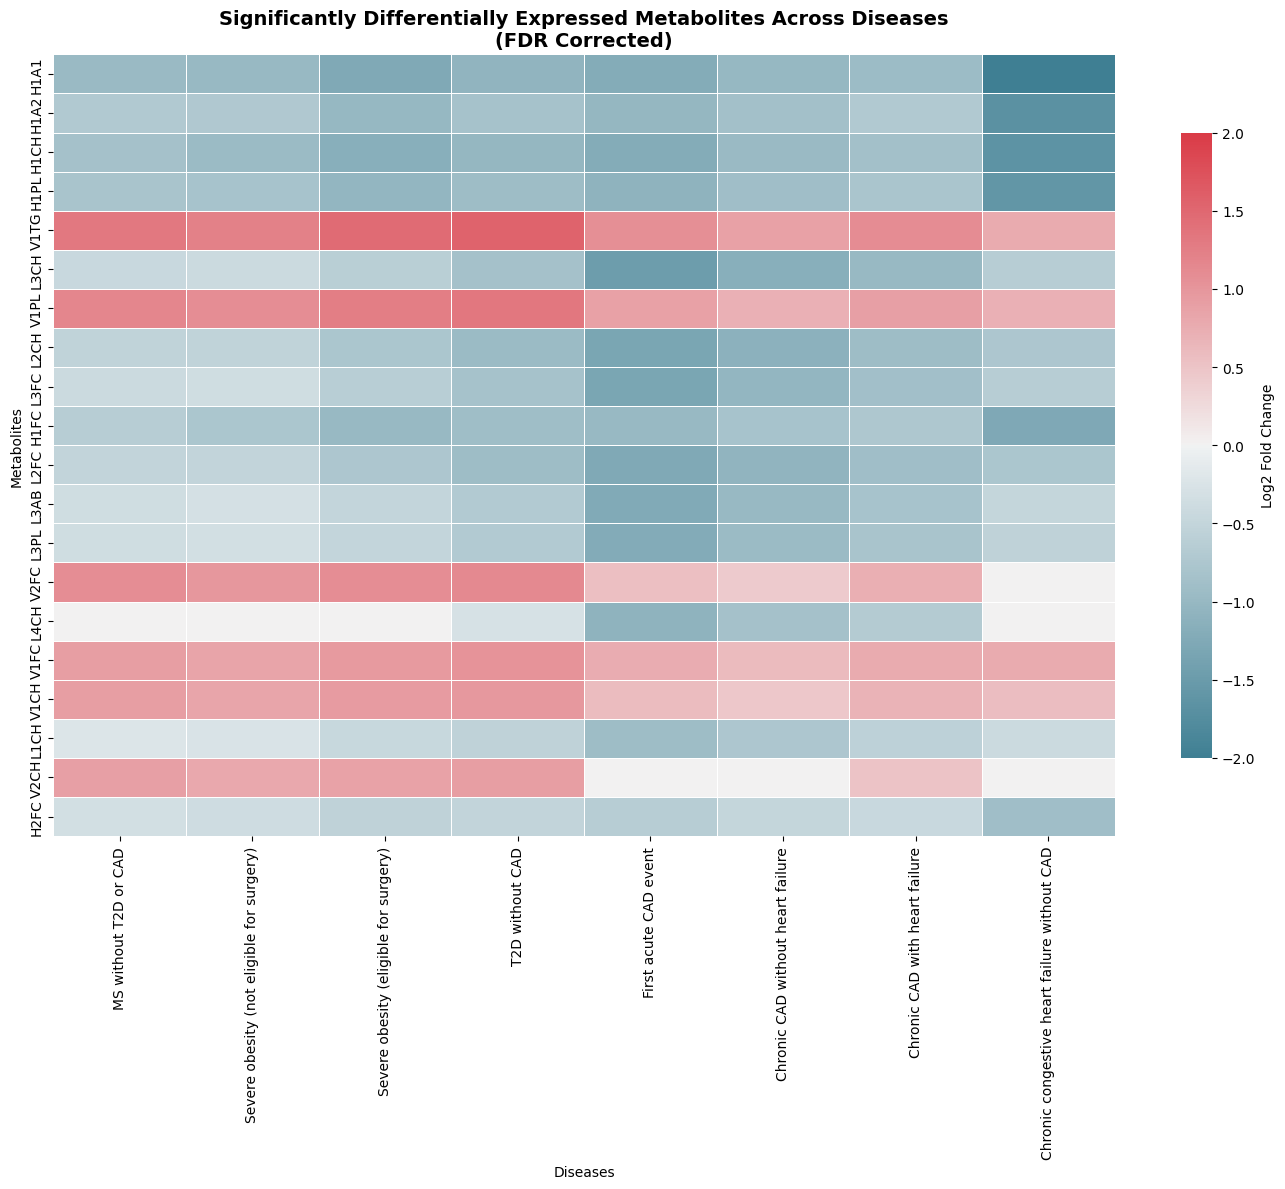

In [ ]:
from scipy import stats
from statsmodels.stats.multitest import multipletests

name_conversion = {
    '1': "MS without T2D or CAD",
    '2a': "Severe obesity (not eligible for surgery)",
    '2b': "Severe obesity (eligible for surgery)",
    '3': "T2D without CAD",
    '4': "First acute CAD event",
    '5': "Chronic CAD without heart failure",
    '6': "Chronic CAD with heart failure",
    '7': "Chronic congestive heart failure without CAD",
    '8': "Control group"
}

disease_cols = [col for col in meta_metabo.columns if col.startswith('disease_')]
metabolite_cols = meta_metabo.columns[21:].tolist()  # All columns from H1A1 onward

def analyze_disease_metabolites(df, disease_col, metabolite_cols, control_col='disease_8'):

    # Get disease patients and control patients
    disease_patients = df[df[disease_col] == 1]
    control_patients = df[df[control_col] == 1]

    results = []

    for metabolite in metabolite_cols:
        if (df[metabolite].isna().sum() / len(df)) > 0.3:  # Skip if >30% missing
            continue

        disease_values = disease_patients[metabolite].dropna()
        control_values = control_patients[metabolite].dropna()

        if len(disease_values) < 5 or len(control_values) < 5:
            continue

        disease_mean = disease_values.mean()
        control_mean = control_values.mean()

        fold_change = disease_mean / control_mean if control_mean != 0 else np.nan

        t_stat, p_value = stats.ttest_ind(
            disease_values,
            control_values,
            equal_var=False  # Use Welch's t-test which doesn't assume equal variance
        )

        # Store results
        results.append({
            'Metabolite': metabolite,
            'Disease_Mean': disease_mean,
            'Control_Mean': control_mean,
            'Fold_Change': fold_change,
            'Direction': 'Elevated' if fold_change > 1 else 'Reduced',
            'P_value': p_value,
            'T_stat': t_stat,
            'Disease_N': len(disease_values),
            'Control_N': len(control_values)
        })

    results_df = pd.DataFrame(results)

    if len(results_df) > 0:
        p_values = results_df['P_value'].values

        rejected, p_adjusted, alpha_sidak, alpha_bonf = multipletests(
            p_values,
            alpha=0.05,
            method='fdr_bh'  # Benjamini-Hochberg FDR correction
        )

        results_df['P_adjusted'] = p_adjusted
        results_df['Significant_raw'] = results_df['P_value'] < 0.05
        results_df['Significant_corrected'] = rejected

        results_df = results_df.sort_values(by=['Significant_corrected', 'P_adjusted', 'P_value'],
                                          ascending=[False, True, True])

    return results_df

all_results = {}
total_tests = 0

for disease_col in disease_cols:
    if disease_col == 'disease_8':  # Skip if this is the control group
        continue

    disease_name = disease_col.replace('disease_', '')
    disease_name = name_conversion[disease_name]

    print(f"Analyzing {disease_name}...")

    results = analyze_disease_metabolites(meta_metabo, disease_col, metabolite_cols)

    if len(results) > 0:
        total_tests += len(results)

        # Store the results
        all_results[disease_name] = results

        n_sig_raw = results['Significant_raw'].sum()
        n_sig_corrected = results['Significant_corrected'].sum()

        print(f"  Tests performed: {len(results)}")
        print(f"  Significant (raw p < 0.05): {n_sig_raw}")
        print(f"  Significant (FDR corrected): {n_sig_corrected}")

        elevated = results[(results['Fold_Change'] > 1) & (results['Significant_corrected'])]
        print(f"\nTop elevated metabolites for {disease_name} (FDR corrected):")
        if len(elevated) > 0:
            elevated_sorted = elevated.sort_values(by='Fold_Change', ascending=False).head(5)
            print(elevated_sorted[['Metabolite', 'Fold_Change', 'P_value', 'P_adjusted']])
        else:
            print("No significantly elevated metabolites found after FDR correction.")

        reduced = results[(results['Fold_Change'] < 1) & (results['Significant_corrected'])]
        print(f"\nTop reduced metabolites for {disease_name} (FDR corrected):")
        if len(reduced) > 0:
            reduced_sorted = reduced.sort_values(by='Fold_Change', ascending=True).head(5)
            print(reduced_sorted[['Metabolite', 'Fold_Change', 'P_value', 'P_adjusted']])
        else:
            print("No significantly reduced metabolites found after FDR correction.")

        print("\n" + "-"*70 + "\n")

print(f"TOTAL TESTS PERFORMED ACROSS ALL DISEASES: {total_tests}")

def create_heatmap(all_results, top_n=20, use_corrected=True):
    """Create a heatmap of top differentially expressed metabolites across diseases"""

    # Collect significant metabolites across all diseases
    sig_column = 'Significant_corrected' if use_corrected else 'Significant_raw'
    all_significant = set()

    for disease, results in all_results.items():
        sig_metabolites = results[results[sig_column]]['Metabolite'].tolist()
        all_significant.update(sig_metabolites)

    print(f"Total unique significant metabolites ({sig_column}): {len(all_significant)}")

    # If too many significant metabolites, take only the most significant ones
    if len(all_significant) > top_n:
        # Get top metabolites by most extreme fold change (in either direction) across diseases
        all_sig_data = []
        for disease, results in all_results.items():
            sig_results = results[results[sig_column]]
            if len(sig_results) > 0:
                # Calculate extreme_fold_change which represents magnitude in either direction
                sig_results = sig_results.copy()
                sig_results['extreme_fold_change'] = sig_results['Fold_Change'].apply(
                    lambda x: max(x, 1/x) if x > 0 else 0
                )
                all_sig_data.append(sig_results[['Metabolite', 'extreme_fold_change']])

        if all_sig_data:
            combined = pd.concat(all_sig_data)
            # Get the maximum extreme fold change for each metabolite across all diseases
            max_fold_changes = combined.groupby('Metabolite')['extreme_fold_change'].max()
            # Sort by the most extreme fold change and take the top N
            top_metabolites = max_fold_changes.sort_values(ascending=False).head(top_n).index.tolist()
        else:
            return None
    else:
        top_metabolites = list(all_significant)

    if not top_metabolites:
        print("No significant metabolites found for heatmap!")
        return None

    # Create matrix for heatmap
    heatmap_data = []
    for metabolite in top_metabolites:
        row = {'Metabolite': metabolite}
        for disease, results in all_results.items():
            match = results[results['Metabolite'] == metabolite]
            if len(match) > 0:
                # Use log2 fold change for better visualization
                log2_fc = np.log2(match['Fold_Change'].values[0]) if match['Fold_Change'].values[0] > 0 else 0
                # Only color significant changes (using corrected significance)
                value = log2_fc if match[sig_column].values[0] else 0
                row[disease] = value
            else:
                row[disease] = 0
        heatmap_data.append(row)

    if not heatmap_data:
        return None

    heatmap_df = pd.DataFrame(heatmap_data)
    heatmap_df = heatmap_df.set_index('Metabolite')

    return heatmap_df

heatmap_df = create_heatmap(all_results, use_corrected=True)
if heatmap_df is not None:
    plt.figure(figsize=(14, len(heatmap_df)*0.5+2))
    cmap = sns.diverging_palette(220, 10, as_cmap=True)
    sns.heatmap(heatmap_df, cmap=cmap, center=0,
                vmin=-2, vmax=2,
                linewidths=0.5,
                annot=False,
                cbar_kws={"shrink": 0.8, "label": "Log2 Fold Change"})
    plt.title('Significantly Differentially Expressed Metabolites Across Diseases\n(FDR Corrected)',
              fontsize=14, fontweight='bold')
    plt.ylabel('Metabolites')
    plt.xlabel('Diseases')
    plt.tight_layout()
    plt.savefig('metabolite_heatmap_fdr_corrected.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No significant metabolites found after FDR correction - no heatmap created.")

### Microbiome-Metabolome Correlations

In [ ]:
metadata_cols = list(metadata.columns)
metadata_cols.remove("SampleID")
microbiome_cols = list(microbiome.columns)
microbiome_cols.remove("SampleID")
metabolites_cols = list(metabolites.columns)
metabolites_cols.remove("SampleID")
total_tests = len(microbiome_cols) * len(metabolites_cols)
total_tests

69720

In [ ]:
pd.set_option('display.width', None)  # Auto-detect width
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.expand_frame_repr', False)  # Don't wrap to multiple lines

metadata_cols = list(metadata.columns)
metadata_cols.remove("SampleID")
microbiome_cols = list(microbiome.columns)
microbiome_cols.remove("SampleID")
metabolites_cols = list(serum_lipo.columns)
metabolites_cols.remove("SampleID")

merged_df = microbiome.merge(serum_lipo, on='SampleID', how='outer')
merged_df = merged_df.merge(metadata, on='SampleID', how='outer')

def calculate_correlation_matrix(data, micro_cols, meta_cols, method='spearman'):
    corr_values = {}
    p_values = {}
    total_tests = len(micro_cols) * len(meta_cols)
    alpha = 0.05
    bonferroni_threshold = alpha / total_tests

    for micro_col, meta_col in itertools.product(microbiome_cols, metabolites_cols):
        valid_data = data[[micro_col, meta_col]].dropna()
        if len(valid_data) > 1:
            if method == 'spearman':
                corr, p = spearmanr(valid_data[micro_col], valid_data[meta_col])
            else:
                corr, p = pearsonr(valid_data[micro_col], valid_data[meta_col])

            corr_values[(micro_col, meta_col)] = corr
            p_values[(micro_col, meta_col)] = p

    return corr_values, p_values, bonferroni_threshold

def get_top_correlations(corr_values, p_values, threshold, top_n=15):
    significant_corrs = {k: v for k, v in corr_values.items() if p_values[k] < threshold}
    sorted_corrs = sorted(significant_corrs.items(), key=lambda x: abs(x[1]), reverse=True)
    top_corrs = sorted_corrs[:top_n]
    results = []
    for (micro, meta), corr in top_corrs:
        results.append({
            'Microbe': micro,
            'Metabolite': meta,
            'Correlation': corr,
            'p-value': p_values[(micro, meta)],
            'Significant': 'Yes' if p_values[(micro, meta)] < threshold else 'No'
        })
    return pd.DataFrame(results)


healthy_df = merged_df[merged_df['is_sick'] == 0]
sick_df = merged_df[merged_df['is_sick'] == 1]

healthy_corrs, healthy_pvals, healthy_threshold = calculate_correlation_matrix(
    healthy_df, microbiome_cols, metabolites_cols, 'spearman'
)
sick_corrs, sick_pvals, sick_threshold = calculate_correlation_matrix(
    sick_df, microbiome_cols, metabolites_cols, 'spearman'
)

top_healthy = get_top_correlations(healthy_corrs, healthy_pvals, healthy_threshold)
top_sick = get_top_correlations(sick_corrs, sick_pvals, sick_threshold)


# Display results
print("Top 15 Significant Correlations - Healthy Group:")
print(top_healthy)
print("\nTop 15 Significant Correlations - Sick Group:")
print(top_sick)

Top 15 Significant Correlations - Healthy Group:
Empty DataFrame
Columns: []
Index: []

Top 15 Significant Correlations - Sick Group:
                           Microbe Metabolite  Correlation       p-value Significant
0           Onthomonas sp900758315       V1TG    -0.223345  3.537958e-15         Yes
1              CAG-353 sp900066885       V1TG    -0.223285  3.600299e-15         Yes
2     Faecalibacterium sp900758465       V1TG    -0.220143  8.862890e-15         Yes
3           Onthomonas sp900758315       V1FC    -0.219747  9.919542e-15         Yes
4           Onthomonas sp900758315       V1PL    -0.218895  1.262898e-14         Yes
5           Onthomonas sp900758315       V1CH    -0.218623  1.363850e-14         Yes
6   Faecalibacterium prausnitzii_E       V1TG    -0.218210  1.532292e-14         Yes
7              CAG-353 sp900066885       V1PL    -0.216806  2.273143e-14         Yes
8           Onthomonas sp900758315       TPTG    -0.213989  4.974853e-14         Yes
9           Onth

<function matplotlib.pyplot.show(close=None, block=None)>

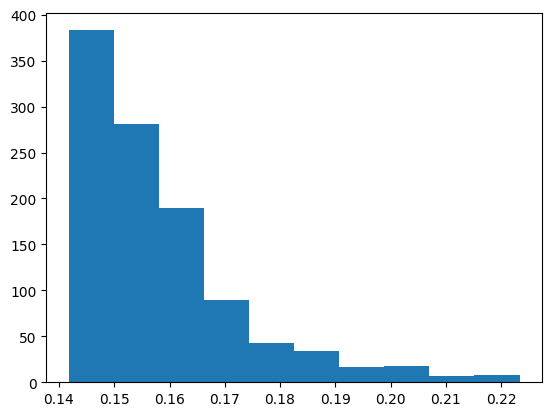

In [ ]:
a=[]
significant_corrs = {k: v for k, v in sick_corrs.items() if sick_pvals[k] < sick_threshold}
sorted_corrs = sorted(significant_corrs.items(), key=lambda x: abs(x[1]), reverse=True)
top_corrs = sorted_corrs[:1072]
for (micro, meta), corr in top_corrs:
    a.append(abs(corr))
plt.hist(a)
plt.show

In [ ]:
top_10_sick_species=set()
for (micro, meta), corr in top_corrs:
    if len(top_10_sick_species)==5:
        break
    top_10_sick_species.add(micro)
print(top_10_sick_species)

{'Faecalibacterium sp900539885', 'Faecalibacterium sp900758465', 'Onthomonas sp900758315', 'CAG-353 sp900066885', 'Faecalibacterium prausnitzii_E'}


In [ ]:
significant_corrs = {k: v for k, v in healthy_corrs.items()}
sorted_corrs = sorted(significant_corrs.items(), key=lambda x: abs(x[1]), reverse=True)[:25]
results = []
for (micro, meta), corr in sorted_corrs:
    results.append({
        'Microbe': micro,
        'Metabolite': meta,
        'Correlation': corr,
        'p-value': healthy_pvals[(micro, meta)]
    })

print(pd.DataFrame(results))
print(healthy_threshold)
print(min(healthy_pvals.values()))

                           Microbe Metabolite  Correlation   p-value
0         Limiplasma merdipullorum       L2FC     0.336670  0.000007
1         Limiplasma merdipullorum       L2CH     0.333626  0.000009
2              CAG-266 sp000436095       HDCH     0.333279  0.000009
3              CAG-266 sp000436095       L2FC     0.332424  0.000009
4              CAG-266 sp000436095       L2CH     0.329330  0.000012
5   Anaerotignum lactatifermentans       HDFC     0.328033  0.000013
6              CAG-266 sp000436095       H1FC     0.325906  0.000014
7         Limiplasma merdipullorum       L3PL     0.325160  0.000015
8         Limiplasma merdipullorum       L3CH     0.320764  0.000020
9              CAG-266 sp000436095       H1CH     0.318215  0.000023
10  Anaerotignum lactatifermentans       H1CH     0.317485  0.000025
11             CAG-266 sp000436095       HDFC     0.314275  0.000030
12             CAG-628 sp003524085       L6TG     0.312140  0.000034
13  Anaerotignum lactatifermentans

### Metadata correlations

In [ ]:

dummy_df = pd.get_dummies(metadata['PATGROUPFINAL_C'], prefix='disease')


analysis_df = pd.concat([metadata.drop('PATGROUPFINAL_C', axis=1), dummy_df], axis=1)

for col in dummy_df.columns:
    analysis_df[col] = analysis_df[col].astype(int)
numeric_df = analysis_df.select_dtypes(include=['number'])

continuous_cols = ['AGE', 'DDS']
binary_cols = ['GENDER', 'SMOKE', 'pa_work_2cl']
disease_cols = ['is_sick', 'disease_1', 'disease_2a', 'disease_2b',
                'disease_3', 'disease_4', 'disease_5',
                'disease_6', 'disease_7', 'disease_8']

pearson_corr = analysis_df[continuous_cols + disease_cols].corr(method='pearson')
pearson_matrix = pearson_corr.loc[continuous_cols, disease_cols]

kendall_corr = analysis_df[binary_cols + disease_cols].corr(method='kendall')
kendall_matrix = kendall_corr.loc[binary_cols, disease_cols]

pearson_matrix



,is_sick,disease_1,disease_2a,disease_2b,disease_3,disease_4,disease_5,disease_6,disease_7,disease_8
GENDER,0.070633,0.013514,-0.220925,-0.118222,0.095872,0.149651,0.198840,0.037461,0.096997,-0.070633
SMOKE,0.065903,-0.052761,0.070474,0.085468,-0.051345,0.061294,-0.007826,0.017678,-0.026011,-0.065903
pa_work_2cl,-0.019177,0.004946,-0.015802,-0.069728,0.017608,0.055866,0.027666,-0.035777,0.013617,0.019177


In [ ]:
pearson_matrix

,is_sick,disease_1,disease_2a,disease_2b,disease_3,disease_4,disease_5,disease_6,disease_7,disease_8
AGE,0.057890,0.066519,-0.383958,-0.240898,0.32266,0.058323,0.165428,0.041154,0.043264,-0.057890
DDS,-0.136538,-0.000118,-0.062017,-0.056360,0.02075,-0.029940,-0.036043,-0.010786,0.016331,0.136538


In [ ]:
kendall_matrix

,is_sick,disease_1,disease_2a,disease_2b,disease_3,disease_4,disease_5,disease_6,disease_7,disease_8
GENDER,0.070633,0.013514,-0.220925,-0.118222,0.095872,0.149651,0.198840,0.037461,0.096997,-0.070633
SMOKE,0.065903,-0.052761,0.070474,0.085468,-0.051345,0.061294,-0.007826,0.017678,-0.026011,-0.065903
pa_work_2cl,-0.019177,0.004946,-0.015802,-0.069728,0.017608,0.055866,0.027666,-0.035777,0.013617,0.019177


In [ ]:

df_clean=metadata.dropna()
dummy_df = pd.get_dummies(df_clean['PATGROUPFINAL_C'], prefix='disease')

analysis_df = pd.concat([df_clean.drop('PATGROUPFINAL_C', axis=1), dummy_df], axis=1)

for col in dummy_df.columns:
    analysis_df[col] = analysis_df[col].astype(int)
numeric_df = analysis_df.select_dtypes(include=['number'])

continuous_cols = ['AGE', 'DDS']
binary_cols = ['GENDER', 'SMOKE', 'pa_work_2cl']
disease_cols = ['is_sick', 'disease_1', 'disease_2a', 'disease_2b',
                'disease_3', 'disease_4', 'disease_5',
                'disease_6', 'disease_7', 'disease_8']

pearson_corr = analysis_df[continuous_cols + disease_cols].corr(method='pearson')
pearson_matrix = pearson_corr.loc[continuous_cols, disease_cols]

# Kendall: binary vs. disease
kendall_corr = analysis_df[binary_cols + disease_cols].corr(method='kendall')
kendall_matrix = kendall_corr.loc[binary_cols, disease_cols]

pearson_matrix



,is_sick,disease_1,disease_2a,disease_2b,disease_3,disease_4,disease_5,disease_6,disease_7,disease_8
AGE,0.085969,0.070130,-0.406663,-0.244768,0.414093,0.015220,0.160303,0.038280,0.053564,-0.085969
DDS,-0.133151,0.009965,-0.066674,-0.059122,0.018568,-0.004943,-0.048807,-0.010811,0.034153,0.133151


In [ ]:
kendall_matrix

,is_sick,disease_1,disease_2a,disease_2b,disease_3,disease_4,disease_5,disease_6,disease_7,disease_8
GENDER,0.078931,-0.003032,-0.218755,-0.091512,0.137508,0.107323,0.211813,0.036643,0.100160,-0.078931
SMOKE,0.059621,-0.066414,0.083775,0.087101,-0.046824,0.053274,-0.017474,-0.035847,-0.014439,-0.059621
pa_work_2cl,-0.010199,0.005080,-0.012738,-0.079338,0.031782,0.056417,0.021284,-0.044136,0.016155,0.010199


In [ ]:
from scipy.stats import pearsonr, kendalltau

df_clean = analysis_df.dropna()

# Pearson: AGE vs disease_2a
r1, p1 = pearsonr(df_clean['AGE'], df_clean['disease_2a'])

r2, p2 = pearsonr(df_clean['AGE'], df_clean['disease_3'])

r3, p3 = kendalltau(df_clean['GENDER'], df_clean['disease_2a'])

print("AGE vs disease_2a (Pearson):")
print(f"  Correlation: {r1:.2f}, p-value: {p1}")

print("AGE vs disease_3 (Pearson):")
print(f"  Correlation: {r2:.2f}, p-value: {p2}")

print("GENDER vs disease_2a (Kendall):")
print(f"  Correlation: {r3:.2f}, p-value: {p3}")


AGE vs disease_2a (Pearson):
  Correlation: -0.41, p-value: 3.5764108322795674e-33
AGE vs disease_3 (Pearson):
  Correlation: 0.41, p-value: 1.890584462846951e-34
GENDER vs disease_2a (Kendall):
  Correlation: -0.22, p-value: 6.426711517367432e-10


### Microbiome Confounder Analysis

Duplicate columns: []
Analyzing is_sick...
  Tests performed: 664
  Significant (raw p < 0.05): 378
  Significant (FDR corrected): 115

Top elevated metabolites for is_sick (FDR corrected):
                         Metabolite  Fold_Change       P_value    P_adjusted
657            Megasphaera elsdenii    15.842647  1.218448e-14  8.090497e-12
617      Acidaminococcus fermentans    14.772300  1.454000e-09  9.654562e-07
650       Acidaminococcus intestini    12.627952  2.058833e-17  1.367065e-14
213       Enterocloster sp001517625     9.095780  3.292748e-13  2.186385e-10
212  Enterocloster clostridioformis     8.580948  6.439566e-08  4.275872e-05

Top reduced metabolites for is_sick (FDR corrected):
                    Metabolite  Fold_Change       P_value    P_adjusted
287           COE1 sp001916965     0.288141  6.106574e-06  4.054765e-03
165       UMGS1312 sp900550625     0.300695  2.460147e-07  1.633538e-04
331       UBA11524 sp000437595     0.305621  1.270408e-09  8.435508e-07
164   

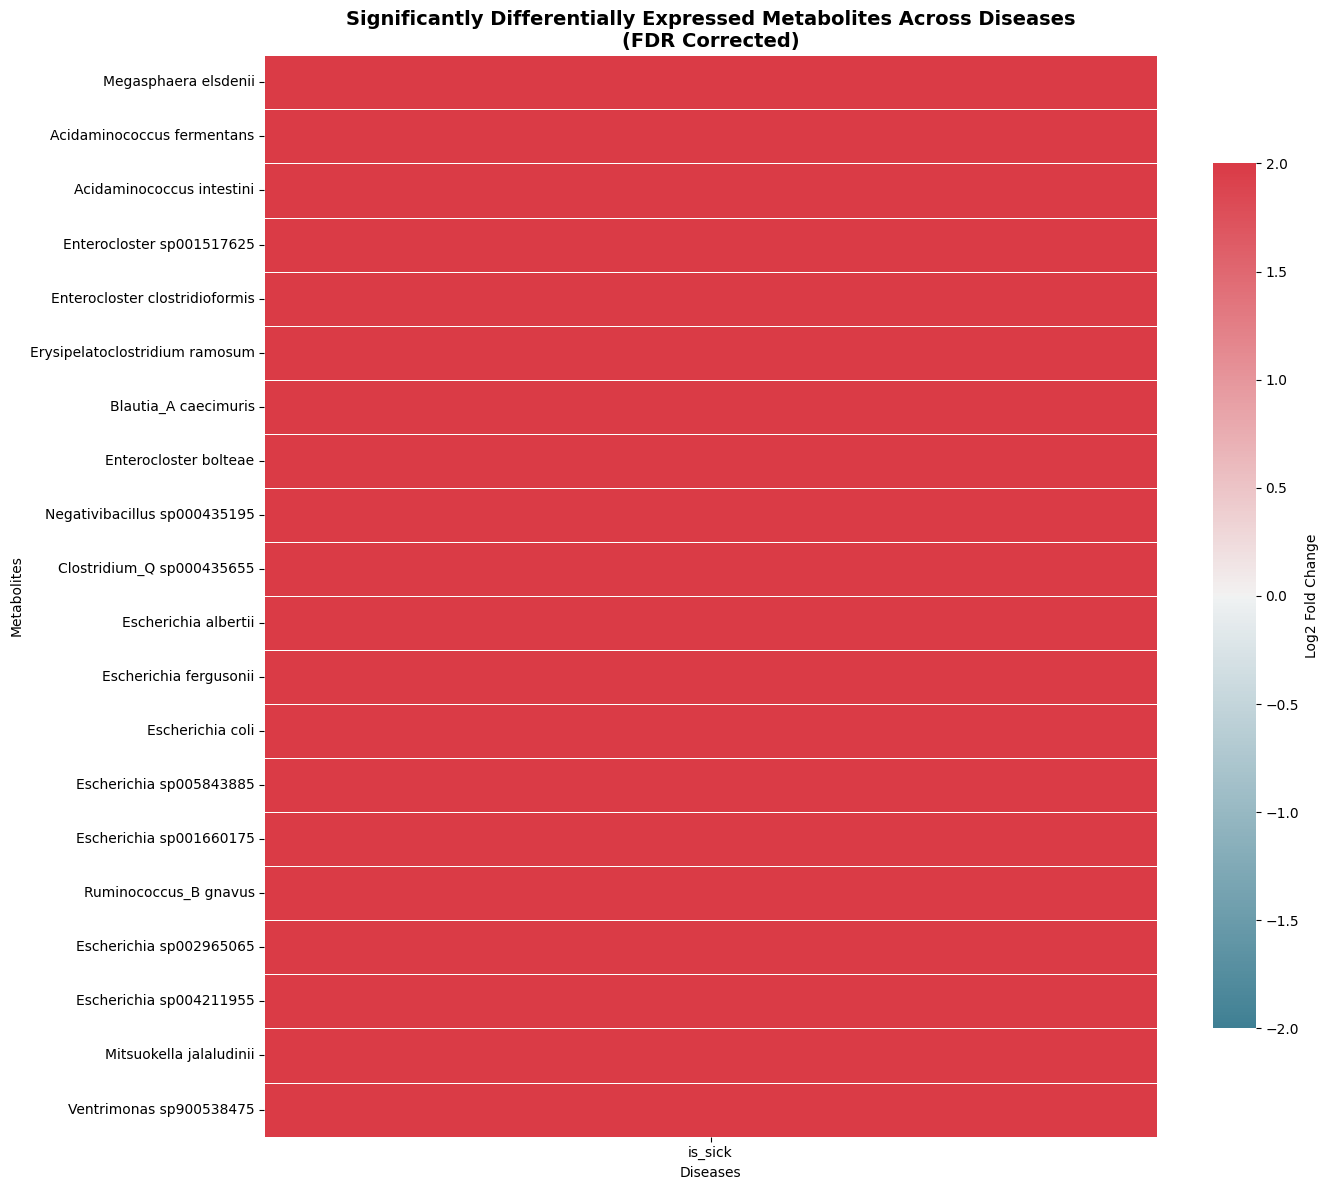

In [ ]:
m = pd.merge(metadata, microbiome, how = 'inner',on='SampleID')
print("Duplicate columns:", m.columns[m.columns.duplicated()].tolist())
disease_cols = ['is_sick']
micro_cols = microbiome.columns[1:]
def analyze_disease_metabolites(df, disease_col, metabolite_cols, control_col='disease_8'):
    disease_patients = df[df[disease_col] == 1]
    control_patients = df[df[control_col] == 1]

    results = []

    for metabolite in metabolite_cols:
        if (df[metabolite].isna().sum() / len(df)) > 0.3:  # Skip if >30% missing
            continue

        disease_values = disease_patients[metabolite].dropna()
        control_values = control_patients[metabolite].dropna()

        if len(disease_values) < 5 or len(control_values) < 5:
            continue

        disease_mean = disease_values.mean()
        control_mean = control_values.mean()

        fold_change = disease_mean / control_mean if control_mean != 0 else np.nan

        t_stat, p_value = stats.ttest_ind(
            disease_values,
            control_values,
            equal_var=False  # Use Welch's t-test which doesn't assume equal variance
        )

        results.append({
            'Metabolite': metabolite,
            'Disease_Mean': disease_mean,
            'Control_Mean': control_mean,
            'Fold_Change': fold_change,
            'Direction': 'Elevated' if fold_change > 1 else 'Reduced',
            'P_value': p_value,
            'T_stat': t_stat,
            'Disease_N': len(disease_values),
            'Control_N': len(control_values)
        })

    results_df = pd.DataFrame(results)

    if len(results_df) > 0:
        p_values = results_df['P_value'].values

        rejected, p_adjusted, alpha_sidak, alpha_bonf = multipletests(
            p_values,
            alpha=0.05,
            method='bonferroni'  # Benjamini-Hochberg FDR correction
        )

        results_df['P_adjusted'] = p_adjusted
        results_df['Significant_raw'] = results_df['P_value'] < 0.05
        results_df['Significant_corrected'] = rejected

        results_df = results_df.sort_values(by=['Significant_corrected', 'P_adjusted', 'P_value'],
                                          ascending=[False, True, True])

    return results_df

all_results = {}
total_tests = 0

for disease_col in disease_cols:
    if disease_col != 'is_sick':  # Skip if this is the control group
        continue

    disease_name = disease_col

    print(f"Analyzing {disease_name}...")

    results = analyze_disease_metabolites(m, disease_col, micro_cols)

    if len(results) > 0:
        total_tests += len(results)

        all_results[disease_name] = results

        n_sig_raw = results['Significant_raw'].sum()
        n_sig_corrected = results['Significant_corrected'].sum()

        print(f"  Tests performed: {len(results)}")
        print(f"  Significant (raw p < 0.05): {n_sig_raw}")
        print(f"  Significant (FDR corrected): {n_sig_corrected}")

        elevated = results[(results['Fold_Change'] > 1) & (results['Significant_corrected'])]
        print(f"\nTop elevated metabolites for {disease_name} (FDR corrected):")
        if len(elevated) > 0:
            elevated_sorted = elevated.sort_values(by='Fold_Change', ascending=False).head(5)
            print(elevated_sorted[['Metabolite', 'Fold_Change', 'P_value', 'P_adjusted']])
        else:
            print("No significantly elevated metabolites found after FDR correction.")

        reduced = results[(results['Fold_Change'] < 1) & (results['Significant_corrected'])]
        print(f"\nTop reduced metabolites for {disease_name} (FDR corrected):")
        if len(reduced) > 0:
            reduced_sorted = reduced.sort_values(by='Fold_Change', ascending=True).head(5)
            print(reduced_sorted[['Metabolite', 'Fold_Change', 'P_value', 'P_adjusted']])
        else:
            print("No significantly reduced metabolites found after FDR correction.")

        print("\n" + "-"*70 + "\n")

print(f"TOTAL TESTS PERFORMED ACROSS ALL DISEASES: {total_tests}")

def create_heatmap(all_results, top_n=20, use_corrected=True):
    sig_column = 'Significant_corrected' if use_corrected else 'Significant_raw'
    all_significant = set()

    for disease, results in all_results.items():
        sig_metabolites = results[results[sig_column]]['Metabolite'].tolist()
        all_significant.update(sig_metabolites)

    print(f"Total unique significant metabolites ({sig_column}): {len(all_significant)}")

    if len(all_significant) > top_n:
        all_sig_data = []
        for disease, results in all_results.items():
            sig_results = results[results[sig_column]]
            if len(sig_results) > 0:
                sig_results = sig_results.copy()
                sig_results['extreme_fold_change'] = sig_results['Fold_Change'].apply(
                    lambda x: max(x, 1/x) if x > 0 else 0
                )
                all_sig_data.append(sig_results[['Metabolite', 'extreme_fold_change']])

        if all_sig_data:
            combined = pd.concat(all_sig_data)
            max_fold_changes = combined.groupby('Metabolite')['extreme_fold_change'].max()
            top_metabolites = max_fold_changes.sort_values(ascending=False).head(top_n).index.tolist()
        else:
            return None
    else:
        top_metabolites = list(all_significant)

    if not top_metabolites:
        print("No significant metabolites found for heatmap!")
        return None

    heatmap_data = []
    for metabolite in top_metabolites:
        row = {'Metabolite': metabolite}
        for disease, results in all_results.items():
            match = results[results['Metabolite'] == metabolite]
            if len(match) > 0:
                log2_fc = np.log2(match['Fold_Change'].values[0]) if match['Fold_Change'].values[0] > 0 else 0
                value = log2_fc if match[sig_column].values[0] else 0
                row[disease] = value
            else:
                row[disease] = 0
        heatmap_data.append(row)

    if not heatmap_data:
        return None

    heatmap_df = pd.DataFrame(heatmap_data)
    heatmap_df = heatmap_df.set_index('Metabolite')

    return heatmap_df

heatmap_df = create_heatmap(all_results, use_corrected=True)
if heatmap_df is not None:
    plt.figure(figsize=(14, len(heatmap_df)*0.5+2))
    cmap = sns.diverging_palette(220, 10, as_cmap=True)
    sns.heatmap(heatmap_df, cmap=cmap, center=0,
                vmin=-2, vmax=2,
                linewidths=0.5,
                annot=False,
                cbar_kws={"shrink": 0.8, "label": "Log2 Fold Change"})
    plt.title('Significantly Differentially Expressed Metabolites Across Diseases\n(FDR Corrected)',
              fontsize=14, fontweight='bold')
    plt.ylabel('Metabolites')
    plt.xlabel('Diseases')
    plt.tight_layout()
    plt.savefig('metabolite_heatmap_fdr_corrected.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No significant metabolites found after FDR correction - no heatmap created.")

In [ ]:
top_biggest_micro = microd[microd['Significant_corrected'] == True].nlargest(15, 'Fold_Change')['Metabolite'].tolist()

top_smallest_micro = microd[microd['Significant_corrected'] == True].nsmallest(15, 'Fold_Change')['Metabolite'].tolist()

### Metabolites confounders analysis

Analyzing is_sick...
  Tests performed: 105
  Significant (raw p < 0.05): 95
  Significant (FDR corrected): 83

Top elevated metabolites for is_sick (FDR corrected):
   Metabolite  Fold_Change       P_value    P_adjusted
79       V1TG     2.520084  1.939881e-38  2.036875e-36
78       V1PL     2.214699  3.657875e-34  3.840769e-32
81       V2FC     1.957742  5.335624e-24  5.602405e-22
77       V1FC     1.862298  1.287037e-33  1.351389e-31
76       V1CH     1.799590  1.039331e-30  1.091297e-28

Top reduced metabolites for is_sick (FDR corrected):
   Metabolite  Fold_Change       P_value    P_adjusted
0        H1A1     0.479140  4.020432e-20  4.221454e-18
2        H1CH     0.499519  3.799889e-22  3.989884e-20
4        H1PL     0.533992  1.044938e-20  1.097185e-18
3        H1FC     0.557620  1.899753e-24  1.994740e-22
41       L2CH     0.559800  5.526191e-35  5.802501e-33

----------------------------------------------------------------------

TOTAL TESTS PERFORMED ACROSS ALL DISEASES: 105


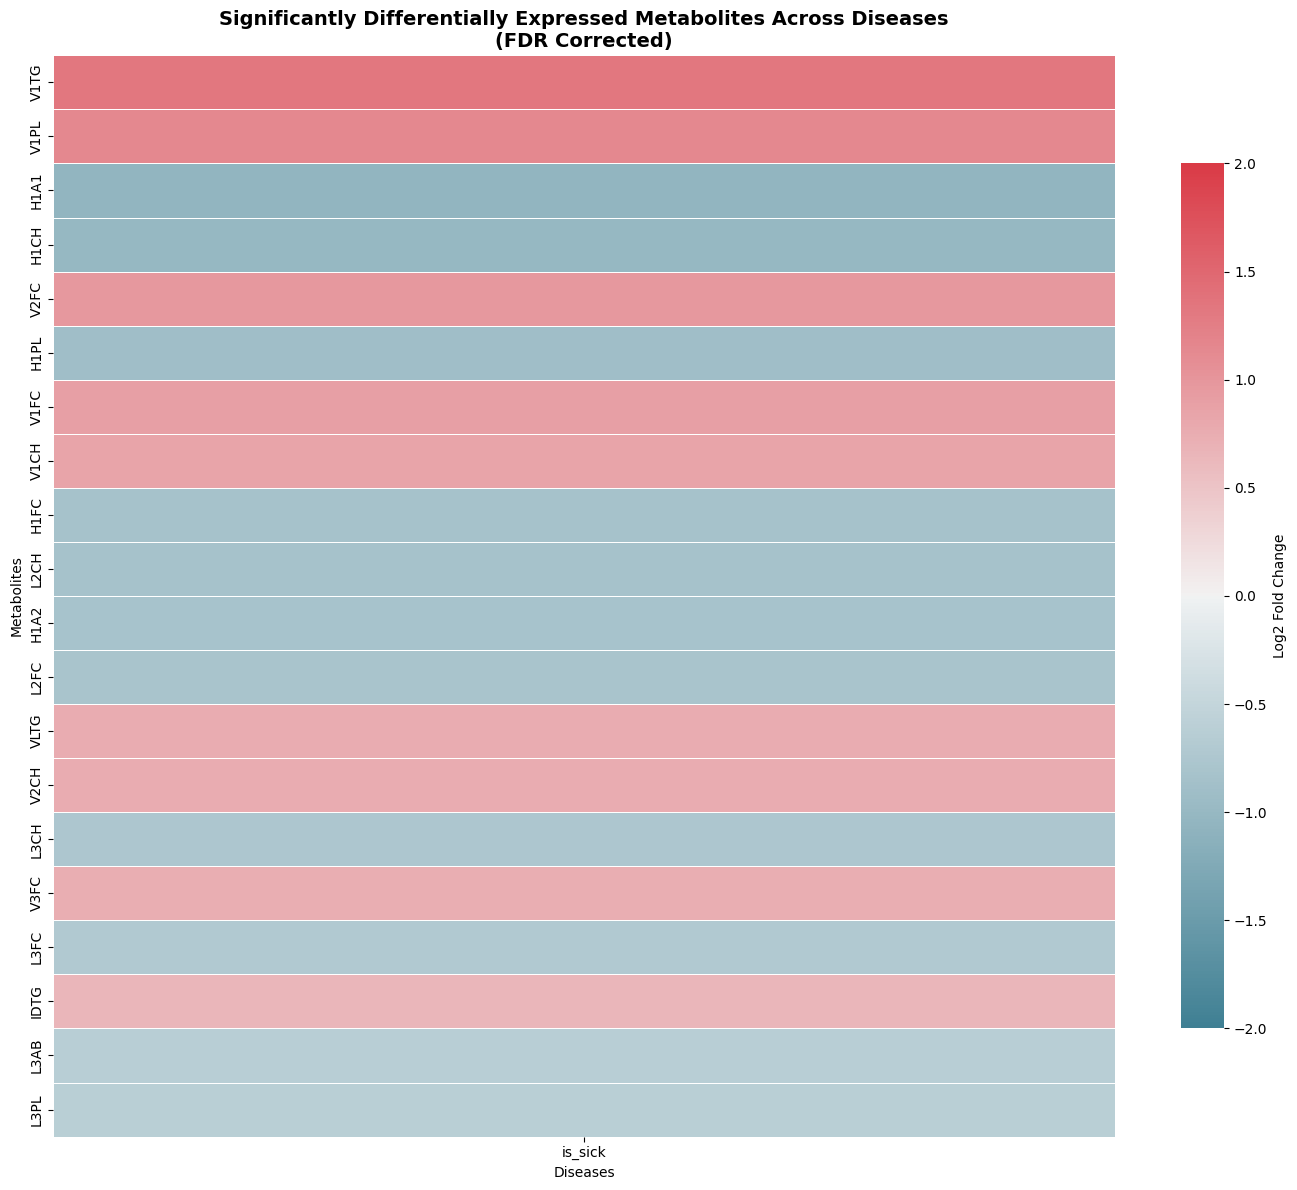

In [ ]:
m = pd.merge(metadata, serum_lipo, how = 'inner',on='SampleID')

disease_cols = ['is_sick']
metabolite_cols = meta_metabo.columns[21:].tolist()  # All columns from H1A1 onward

def analyze_disease_metabolites(df, disease_col, metabolite_cols, control_col='disease_8'):

    disease_patients = df[df[disease_col] == 1]
    control_patients = df[df[control_col] == 1]

    results = []

    for metabolite in metabolite_cols:
        if (df[metabolite].isna().sum() / len(df)) > 0.3:  # Skip if >30% missing
            continue

        disease_values = disease_patients[metabolite].dropna()
        control_values = control_patients[metabolite].dropna()

        if len(disease_values) < 5 or len(control_values) < 5:
            continue

        disease_mean = disease_values.mean()
        control_mean = control_values.mean()

        fold_change = disease_mean / control_mean if control_mean != 0 else np.nan

        t_stat, p_value = stats.ttest_ind(
            disease_values,
            control_values,
            equal_var=False  # Use Welch's t-test which doesn't assume equal variance
        )

        results.append({
            'Metabolite': metabolite,
            'Disease_Mean': disease_mean,
            'Control_Mean': control_mean,
            'Fold_Change': fold_change,
            'Direction': 'Elevated' if fold_change > 1 else 'Reduced',
            'P_value': p_value,
            'T_stat': t_stat,
            'Disease_N': len(disease_values),
            'Control_N': len(control_values)
        })

    results_df = pd.DataFrame(results)

    if len(results_df) > 0:
        p_values = results_df['P_value'].values

        rejected, p_adjusted, alpha_sidak, alpha_bonf = multipletests(
            p_values,
            alpha=0.05,
            method='bonferroni'  # Benjamini-Hochberg FDR correction
        )

        results_df['P_adjusted'] = p_adjusted
        results_df['Significant_raw'] = results_df['P_value'] < 0.05
        results_df['Significant_corrected'] = rejected

        results_df = results_df.sort_values(by=['Significant_corrected', 'P_adjusted', 'P_value'],
                                          ascending=[False, True, True])

    return results_df

all_results = {}
total_tests = 0

for disease_col in disease_cols:
    if disease_col != 'is_sick':  # Skip if this is the control group
        continue

    disease_name = disease_col

    print(f"Analyzing {disease_name}...")

    results = analyze_disease_metabolites(m, disease_col, metabolite_cols)

    if len(results) > 0:
        total_tests += len(results)

        all_results[disease_name] = results

        n_sig_raw = results['Significant_raw'].sum()
        n_sig_corrected = results['Significant_corrected'].sum()

        print(f"  Tests performed: {len(results)}")
        print(f"  Significant (raw p < 0.05): {n_sig_raw}")
        print(f"  Significant (FDR corrected): {n_sig_corrected}")

        elevated = results[(results['Fold_Change'] > 1) & (results['Significant_corrected'])]
        print(f"\nTop elevated metabolites for {disease_name} (FDR corrected):")
        if len(elevated) > 0:
            elevated_sorted = elevated.sort_values(by='Fold_Change', ascending=False).head(5)
            print(elevated_sorted[['Metabolite', 'Fold_Change', 'P_value', 'P_adjusted']])
        else:
            print("No significantly elevated metabolites found after FDR correction.")

        reduced = results[(results['Fold_Change'] < 1) & (results['Significant_corrected'])]
        print(f"\nTop reduced metabolites for {disease_name} (FDR corrected):")
        if len(reduced) > 0:
            reduced_sorted = reduced.sort_values(by='Fold_Change', ascending=True).head(5)
            print(reduced_sorted[['Metabolite', 'Fold_Change', 'P_value', 'P_adjusted']])
        else:
            print("No significantly reduced metabolites found after FDR correction.")

        print("\n" + "-"*70 + "\n")

print(f"TOTAL TESTS PERFORMED ACROSS ALL DISEASES: {total_tests}")

def create_heatmap(all_results, top_n=20, use_corrected=True):

    sig_column = 'Significant_corrected' if use_corrected else 'Significant_raw'
    all_significant = set()

    for disease, results in all_results.items():
        sig_metabolites = results[results[sig_column]]['Metabolite'].tolist()
        all_significant.update(sig_metabolites)

    print(f"Total unique significant metabolites ({sig_column}): {len(all_significant)}")

    if len(all_significant) > top_n:
        all_sig_data = []
        for disease, results in all_results.items():
            sig_results = results[results[sig_column]]
            if len(sig_results) > 0:
                sig_results = sig_results.copy()
                sig_results['extreme_fold_change'] = sig_results['Fold_Change'].apply(
                    lambda x: max(x, 1/x) if x > 0 else 0
                )
                all_sig_data.append(sig_results[['Metabolite', 'extreme_fold_change']])

        if all_sig_data:
            combined = pd.concat(all_sig_data)
            max_fold_changes = combined.groupby('Metabolite')['extreme_fold_change'].max()
            top_metabolites = max_fold_changes.sort_values(ascending=False).head(top_n).index.tolist()
        else:
            return None
    else:
        top_metabolites = list(all_significant)

    if not top_metabolites:
        print("No significant metabolites found for heatmap!")
        return None

    heatmap_data = []
    for metabolite in top_metabolites:
        row = {'Metabolite': metabolite}
        for disease, results in all_results.items():
            match = results[results['Metabolite'] == metabolite]
            if len(match) > 0:
                log2_fc = np.log2(match['Fold_Change'].values[0]) if match['Fold_Change'].values[0] > 0 else 0
                value = log2_fc if match[sig_column].values[0] else 0
                row[disease] = value
            else:
                row[disease] = 0
        heatmap_data.append(row)

    if not heatmap_data:
        return None

    heatmap_df = pd.DataFrame(heatmap_data)
    heatmap_df = heatmap_df.set_index('Metabolite')

    return heatmap_df

heatmap_df = create_heatmap(all_results, use_corrected=True)
if heatmap_df is not None:
    plt.figure(figsize=(14, len(heatmap_df)*0.5+2))
    cmap = sns.diverging_palette(220, 10, as_cmap=True)
    sns.heatmap(heatmap_df, cmap=cmap, center=0,
                vmin=-2, vmax=2,
                linewidths=0.5,
                annot=False,
                cbar_kws={"shrink": 0.8, "label": "Log2 Fold Change"})
    plt.title('Significantly Differentially Expressed Metabolites Across Diseases\n(FDR Corrected)',
              fontsize=14, fontweight='bold')
    plt.ylabel('Metabolites')
    plt.xlabel('Diseases')
    plt.tight_layout()
    plt.savefig('metabolite_heatmap_fdr_corrected.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No significant metabolites found after FDR correction - no heatmap created.")

In [ ]:
d=all_results['is_sick']
d

,Metabolite,Disease_Mean,Control_Mean,Fold_Change,Direction,P_value,T_stat,Disease_N,Control_N,P_adjusted,Significant_raw,Significant_corrected
79,V1TG,35.319210,14.015094,2.520084,Elevated,1.939881e-38,14.783153,1213,170,2.036875e-36,True,True
46,L3CH,13.206835,22.304378,0.592119,Reduced,1.473104e-37,-15.733824,1213,170,1.546760e-35,True,True
45,L3AB,6.212105,9.592452,0.647604,Reduced,2.050157e-36,-15.307214,1213,170,2.152665e-34,True,True
48,L3PL,8.060297,12.417942,0.649085,Reduced,6.014855e-36,-15.207267,1213,170,6.315598e-34,True,True
47,L3FC,3.597972,5.903548,0.609459,Reduced,1.469312e-35,-14.952903,1213,170,1.542777e-33,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
60,L6AB,15.839722,16.390692,0.966385,Reduced,2.644100e-01,-1.118950,1213,170,1.000000e+00,False,False
64,L6TG,5.106158,4.995532,1.022145,Elevated,3.751795e-01,0.888641,1213,170,1.000000e+00,False,False
19,H4A2,22.458968,22.736314,0.987802,Reduced,5.114584e-01,-0.657721,1213,170,1.000000e+00,False,False
99,V6TG,2.074658,2.033312,1.020335,Elevated,6.279389e-01,0.485363,1213,170,1.000000e+00,False,False


In [ ]:
top_biggest = d[d['Significant_corrected'] == True].nlargest(15, 'Fold_Change')['Metabolite'].tolist()

top_smallest = d[d['Significant_corrected'] == True].nsmallest(15, 'Fold_Change')['Metabolite'].tolist()

### confounder coefficient test

In [ ]:
def analyze_confounding_factors_single_model(df, metabolite, confounders, disease_col='is_sick'):

    analysis_df = df.dropna(subset=[metabolite, disease_col] + confounders).copy()

    if len(analysis_df) < 10:
        return None

    results = {}

    full_formula = f"{disease_col} ~ {metabolite} + {' + '.join(confounders)}"

    try:
        full_model = smf.logit(formula=full_formula, data=analysis_df).fit(disp=0)

        results['metabolite_effect'] = {
            'coefficient': full_model.params[metabolite],
            'p_value': full_model.pvalues[metabolite],
            'odds_ratio': np.exp(full_model.params[metabolite]),
            'significant': full_model.pvalues[metabolite] < 0.05,
            'confidence_interval': np.exp(full_model.conf_int().loc[metabolite])
        }

        significant_confounders = []
        confounder_effects = {}

        for confounder in confounders:
            if confounder in full_model.params:
                p_val = full_model.pvalues[confounder]
                is_significant = p_val < 0.05

                confounder_effects[confounder] = {
                    'coefficient': full_model.params[confounder],
                    'p_value': p_val,
                    'odds_ratio': np.exp(full_model.params[confounder]),
                    'significant': is_significant,
                    'confidence_interval': np.exp(full_model.conf_int().loc[confounder])
                }

                if is_significant:
                    significant_confounders.append(confounder)

        results['confounder_effects'] = confounder_effects
        results['significant_confounders'] = significant_confounders
        results['n_significant_confounders'] = len(significant_confounders)

        results['pseudo_r2'] = full_model.prsquared
        results['aic'] = full_model.aic
        results['bic'] = full_model.bic
        results['sample_size'] = len(analysis_df)

        return results

    except Exception as e:
        print(f"Error in model for {metabolite}: {e}")
        return None

m = pd.merge(metadata, microbiome, how = 'inner',on='SampleID')
confounders = ['AGE', 'GENDER', 'SMOKE', 'pa_work_2cl', 'DDS', 'CENTER_C']

def clean_column_names(df, columns_to_clean):
    df_cleaned = df.copy()
    name_mapping = {}
    for col in columns_to_clean:
        if col in df.columns:
            new_name = col.replace(' ', '_').replace('.', '_').replace('-', '_')
            new_name = ''.join(c for c in new_name if c.isalnum() or c == '_')
            name_mapping[col] = new_name

    df_cleaned = df_cleaned.rename(columns=name_mapping)

    return df_cleaned, name_mapping

m_cleaned, name_mapping = clean_column_names(m, top_smallest_micro)

micro_cols_cleaned = [name_mapping.get(col, col) for col in micro_cols if col in name_mapping]

metabolite_results = {}
for metabolite in micro_cols_cleaned:
    results = analyze_confounding_factors_single_model(m_cleaned, metabolite, confounders)
    if results:
        metabolite_results[metabolite] = results


summary_data = []
for metabolite, results in metabolite_results.items():
    if results:
        row = {
            'Metabolite': metabolite,
            'Pseudo_R2': results['pseudo_r2'],
            'AIC': results['aic'],
            'Metbolie_coefficient': results['metabolite_effect']['coefficient'],
            'Metabolite_OR': results['metabolite_effect']['odds_ratio'],
            'Metabolite_P_value': results['metabolite_effect']['p_value'],
            'Metabolite_Significant': results['metabolite_effect']['significant'],
            'Significant_Confounders': ', '.join(results['significant_confounders'])
        }

        for confounder in confounders:
            if confounder in results['confounder_effects'] and results['confounder_effects'][confounder]['significant']:
                row[f'{confounder}_Coefficient'] = results['confounder_effects'][confounder]['coefficient']
                row[f'{confounder}_Significant'] = results['confounder_effects'][confounder]['significant']
                row[f'{confounder}_P_value'] = results['confounder_effects'][confounder]['p_value']

        summary_data.append(row)

confounding_summary = pd.DataFrame(summary_data)
confounding_summary

<ipython-input-119-cc7e257fbe1d>:22: RuntimeWarning: overflow encountered in exp
  'odds_ratio': np.exp(full_model.params[metabolite]),
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
<ipython-input-119-cc7e257fbe1d>:22: RuntimeWarning: overflow encountered in exp
  'odds_ratio': np.exp(full_model.params[metabolite]),
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
<ipython-input-119-cc7e257fbe1d>:22: RuntimeWarning: overflo

,Metabolite,Pseudo_R2,AIC,Metbolie_coefficient,Metabolite_OR,Metabolite_P_value,Metabolite_Significant,Significant_Confounders,AGE_Coefficient,AGE_Significant,AGE_P_value,DDS_Coefficient,DDS_Significant,DDS_P_value
0,Negativibacillus_sp000435195,0.106158,526.119567,1612.366635,inf,0.001488,True,"AGE, DDS",0.226906,True,0.038679,-0.457288,True,0.000816
1,Blautia_A_caecimuris,0.096950,531.374546,3782.440470,inf,0.008985,True,"AGE, DDS",0.298783,True,0.006416,-0.504802,True,0.000217
2,Enterocloster_bolteae,0.100995,529.066089,508.583183,7.496695e+220,0.004670,True,"AGE, DDS",0.260110,True,0.019532,-0.495721,True,0.000298
3,Enterocloster_clostridioformis,0.076770,542.891520,369.458708,2.843662e+160,0.069649,False,"AGE, DDS",0.255567,True,0.019487,-0.517486,True,0.000151
4,Enterocloster_sp001517625,0.098633,530.413973,383.049085,2.270409e+166,0.007859,True,"AGE, DDS",0.308598,True,0.004920,-0.495554,True,0.000274
5,Clostridium_Q_sp000435655,0.075718,543.491911,1133.613592,inf,0.109785,False,"AGE, DDS",0.301919,True,0.005941,-0.505954,True,0.000165
6,Escherichia_coli,0.074852,543.986031,50.729792,1.075644e+22,0.058113,False,"AGE, DDS",0.219100,True,0.048727,-0.518830,True,0.000121
7,Escherichia_fergusonii,0.069518,547.029984,298.480059,4.248566e+129,0.109787,False,"AGE, DDS",0.233376,True,0.035332,-0.521170,True,0.000114
8,Escherichia_sp005843885,0.068350,547.696705,366.058940,9.492433e+158,0.141932,False,"AGE, DDS",0.237800,True,0.031878,-0.521339,True,0.000114
9,Escherichia_sp001660175,0.068806,547.436186,839.482221,inf,0.123881,False,"AGE, DDS",0.235697,True,0.033531,-0.521033,True,0.000114


In [ ]:
def analyze_confounding_factors_single_model(df, metabolite, confounders, disease_col='is_sick'):

    analysis_df = df.dropna(subset=[metabolite, disease_col] + confounders).copy()
    if len(analysis_df) < 10:
        return None
    results = {}
    full_formula = f"{disease_col} ~ {metabolite} + {' + '.join(confounders)}"

    try:
        full_model = smf.logit(formula=full_formula, data=analysis_df).fit(disp=0)

        results['metabolite_effect'] = {
            'coefficient': full_model.params[metabolite],
            'p_value': full_model.pvalues[metabolite],
            'odds_ratio': np.exp(full_model.params[metabolite]),
            'significant': full_model.pvalues[metabolite] < 0.05,
            'confidence_interval': np.exp(full_model.conf_int().loc[metabolite])
        }

        significant_confounders = []
        confounder_effects = {}

        for confounder in confounders:
            if confounder in full_model.params:
                p_val = full_model.pvalues[confounder]
                is_significant = p_val < 0.05

                confounder_effects[confounder] = {
                    'coefficient': full_model.params[confounder],
                    'p_value': p_val,
                    'odds_ratio': np.exp(full_model.params[confounder]),
                    'significant': is_significant,
                    'confidence_interval': np.exp(full_model.conf_int().loc[confounder])
                }

                if is_significant:
                    significant_confounders.append(confounder)

        results['confounder_effects'] = confounder_effects
        results['significant_confounders'] = significant_confounders
        results['n_significant_confounders'] = len(significant_confounders)

        results['pseudo_r2'] = full_model.prsquared
        results['aic'] = full_model.aic
        results['bic'] = full_model.bic
        results['sample_size'] = len(analysis_df)

        return results

    except Exception as e:
        print(f"Error in model for {metabolite}: {e}")
        return None

m = pd.merge(metadata, microbiome, how = 'inner',on='SampleID')
confounders = ['AGE', 'GENDER', 'SMOKE', 'pa_work_2cl', 'DDS', 'CENTER_C']

def clean_column_names(df, columns_to_clean):
    df_cleaned = df.copy()

    name_mapping = {}
    for col in columns_to_clean:
        if col in df.columns:
            new_name = col.replace(' ', '_').replace('.', '_').replace('-', '_')
            new_name = ''.join(c for c in new_name if c.isalnum() or c == '_')
            name_mapping[col] = new_name

    df_cleaned = df_cleaned.rename(columns=name_mapping)

    return df_cleaned, name_mapping

m_cleaned, name_mapping = clean_column_names(m, top_smallest_micro)

micro_cols_cleaned = [name_mapping.get(col, col) for col in micro_cols if col in name_mapping]

metabolite_results = {}
for metabolite in micro_cols_cleaned:
    results = analyze_confounding_factors_single_model(m_cleaned, metabolite, confounders)
    if results:
        metabolite_results[metabolite] = results


summary_data = []
for metabolite, results in metabolite_results.items():
    if results:
        row = {
            'Metabolite': metabolite,
            'Pseudo_R2': results['pseudo_r2'],
            'AIC': results['aic'],
            'Metbolie_coefficient': results['metabolite_effect']['coefficient'],
            'Metabolite_OR': results['metabolite_effect']['odds_ratio'],
            'Metabolite_P_value': results['metabolite_effect']['p_value'],
            'Metabolite_Significant': results['metabolite_effect']['significant'],
            'Significant_Confounders': ', '.join(results['significant_confounders'])
        }

        for confounder in confounders:
            if confounder in results['confounder_effects'] and results['confounder_effects'][confounder]['significant']:
                row[f'{confounder}_Coefficient'] = results['confounder_effects'][confounder]['coefficient']
                row[f'{confounder}_Significant'] = results['confounder_effects'][confounder]['significant']
                row[f'{confounder}_P_value'] = results['confounder_effects'][confounder]['p_value']

        summary_data.append(row)

confounding_summary = pd.DataFrame(summary_data)
confounding_summary

,Metabolite,Pseudo_R2,AIC,Metbolie_coefficient,Metabolite_OR,Metabolite_P_value,Metabolite_Significant,Significant_Confounders,AGE_Coefficient,AGE_Significant,AGE_P_value,DDS_Coefficient,DDS_Significant,DDS_P_value
0,Faecousia_sp000434635,0.076804,542.871761,-76.870407,4.126732e-34,1.263685e-03,True,"AGE, DDS",0.305441,True,0.005441,-0.530372,True,0.000093
1,F23_B02_sp001916715,0.087750,536.624912,-90.502500,4.957508e-40,5.598644e-05,True,"AGE, DDS",0.305262,True,0.006000,-0.500539,True,0.000299
2,Faecalibacterium_prausnitzii_E,0.093736,533.208674,-210.667157,3.224156e-92,4.685789e-05,True,"AGE, DDS",0.298585,True,0.007157,-0.485957,True,0.000379
3,UMGS1696_sp900753285,0.123304,516.333947,-1438.950445,0.000000e+00,3.201795e-09,True,"AGE, DDS",0.366944,True,0.001286,-0.515323,True,0.000267
4,UBA11512_sp003522145,0.111320,523.173650,-905.370816,0.000000e+00,1.600576e-07,True,"AGE, DDS",0.349275,True,0.002037,-0.482825,True,0.000538
5,UMGS1312_sp900550625,0.089902,535.396898,-992.386136,0.000000e+00,1.475718e-04,True,"AGE, DDS",0.319168,True,0.003892,-0.506251,True,0.000228
6,Blautia_A_sp000436615,0.092127,534.127106,-647.667608,5.266618e-282,1.915641e-05,True,"AGE, DDS",0.343825,True,0.001990,-0.489265,True,0.000374
7,Eubacterium_F_sp900539115,0.102190,528.383808,-556.192306,2.810287e-242,2.053740e-05,True,"AGE, DDS",0.299839,True,0.007675,-0.538351,True,0.000115
8,Eubacterium_F_sp000434115,0.097069,531.306520,-1467.571079,0.000000e+00,2.246664e-05,True,"AGE, DDS",0.297311,True,0.007991,-0.541671,True,0.000105
9,Lachnospira_sp003451515,0.082096,539.851686,-123.736137,1.828431e-54,5.124036e-04,True,"AGE, DDS",0.314803,True,0.004145,-0.490686,True,0.000337


In [ ]:
def analyze_confounding_factors_single_model(df, metabolite, confounders, disease_col='is_sick'):
    analysis_df = df.dropna(subset=[metabolite, disease_col] + confounders).copy()
    if len(analysis_df) < 10:
        return None
    results = {}
    full_formula = f"{disease_col} ~ {metabolite} + {' + '.join(confounders)}"

    try:
        full_model = smf.logit(formula=full_formula, data=analysis_df).fit(disp=0)
        results['metabolite_effect'] = {
            'coefficient': full_model.params[metabolite],
            'p_value': full_model.pvalues[metabolite],
            'odds_ratio': np.exp(full_model.params[metabolite]),
            'significant': full_model.pvalues[metabolite] < 0.05,
            'confidence_interval': np.exp(full_model.conf_int().loc[metabolite])
        }

        significant_confounders = []
        confounder_effects = {}

        for confounder in confounders:
            if confounder in full_model.params:
                p_val = full_model.pvalues[confounder]
                is_significant = p_val < 0.05

                confounder_effects[confounder] = {
                    'coefficient': full_model.params[confounder],
                    'p_value': p_val,
                    'odds_ratio': np.exp(full_model.params[confounder]),
                    'significant': is_significant,
                    'confidence_interval': np.exp(full_model.conf_int().loc[confounder])
                }

                if is_significant:
                    significant_confounders.append(confounder)

        results['confounder_effects'] = confounder_effects
        results['significant_confounders'] = significant_confounders
        results['n_significant_confounders'] = len(significant_confounders)

        results['pseudo_r2'] = full_model.prsquared
        results['aic'] = full_model.aic
        results['bic'] = full_model.bic
        results['sample_size'] = len(analysis_df)

        return results

    except Exception as e:
        print(f"Error in model for {metabolite}: {e}")
        return None

m = pd.merge(metadata, serum_lipo, how = 'inner',on='SampleID')
confounders = ['AGE', 'GENDER', 'SMOKE', 'pa_work_2cl', 'DDS', 'CENTER_C']

metabolite_results = {}
for metabolite in top_smallest:
    results = analyze_confounding_factors_single_model(m, metabolite, confounders)
    if results:
        metabolite_results[metabolite] = results


summary_data = []
for metabolite, results in metabolite_results.items():
    if results:
        row = {
            'Metabolite': metabolite,
            'Pseudo_R2': results['pseudo_r2'],
            'AIC': results['aic'],
            'Metbolie_coefficient': results['metabolite_effect']['coefficient'],
            'Metabolite_OR': results['metabolite_effect']['odds_ratio'],
            'Metabolite_P_value': results['metabolite_effect']['p_value'],
            'Metabolite_Significant': results['metabolite_effect']['significant'],
            'Significant_Confounders': ', '.join(results['significant_confounders'])
        }

        for confounder in confounders:
            if confounder in results['confounder_effects'] and results['confounder_effects'][confounder]['significant']:
                row[f'{confounder}_Coefficient'] = results['confounder_effects'][confounder]['coefficient']
                row[f'{confounder}_Significant'] = results['confounder_effects'][confounder]['significant']
                row[f'{confounder}_P_value'] = results['confounder_effects'][confounder]['p_value']

        summary_data.append(row)

confounding_summary = pd.DataFrame(summary_data)
confounding_summary

,Metabolite,Pseudo_R2,AIC,Metbolie_coefficient,Metabolite_OR,Metabolite_P_value,Metabolite_Significant,Significant_Confounders,AGE_Coefficient,AGE_Significant,AGE_P_value,DDS_Coefficient,DDS_Significant,DDS_P_value,GENDER_Coefficient,GENDER_Significant,GENDER_P_value
0,H1A1,0.178514,484.825400,-0.058258,0.943407,1.171180e-14,True,"AGE, DDS",0.303172,True,0.009361,-0.518465,True,0.000352,NaN,NaN,NaN
1,H1CH,0.197427,474.031716,-0.114155,0.892120,5.289903e-16,True,"AGE, DDS",0.337075,True,0.004190,-0.514791,True,0.000483,NaN,NaN,NaN
2,H1PL,0.179066,484.510641,-0.084562,0.918915,8.856387e-15,True,"AGE, DDS",0.319231,True,0.006222,-0.516556,True,0.000389,NaN,NaN,NaN
3,H1FC,0.214135,464.496363,-0.466072,0.627462,2.588407e-17,True,"AGE, DDS",0.329442,True,0.005450,-0.516512,True,0.000497,NaN,NaN,NaN
4,L2CH,0.244519,447.156113,-0.192665,0.824758,1.940262e-18,True,"AGE, DDS",0.392984,True,0.001306,-0.569262,True,0.000167,NaN,NaN,NaN
5,H1A2,0.135135,509.582472,-0.429868,0.650595,1.357995e-10,True,"AGE, DDS",0.297282,True,0.008950,-0.524760,True,0.000201,NaN,NaN,NaN
6,L2FC,0.242730,448.177334,-0.650114,0.521986,1.793952e-18,True,"AGE, DDS",0.394846,True,0.001215,-0.569402,True,0.000168,NaN,NaN,NaN
7,L3CH,0.216409,463.198808,-0.178113,0.836848,9.734805e-17,True,"AGE, DDS",0.448346,True,0.000225,-0.588406,True,0.000087,NaN,NaN,NaN
8,L3FC,0.187113,479.917945,-0.559573,0.571453,1.910509e-14,True,"AGE, DDS",0.429478,True,0.000281,-0.608892,True,0.000042,NaN,NaN,NaN
9,L3AB,0.204681,469.891892,-0.442861,0.642196,6.544245e-16,True,"AGE, GENDER, DDS",0.474577,True,0.000102,-0.592047,True,0.000070,-0.535437,True,0.049356


#Training

## pre-processing for training

In [ ]:
def cv_split(r):
    metadata  = pd.read_csv('/content/metadata.csv')
    microbiome = pd.read_csv('/content/microbiome.csv')
    serum_lipo = pd.read_csv('/content/serum_lipo.csv')

    metadata['is_sick'] = (metadata['PATGROUPFINAL_C'] != '8').astype(int)
    metadata = metadata.drop(columns=['PATGROUPFINAL_C'])
    taxa_columns = microbiome.drop(columns=['SampleID']).columns
    metabolite_columns = serum_lipo.drop(columns=['SampleID']).columns

    merged = pd.merge(metadata, microbiome, how='inner', on='SampleID')
    merged = pd.merge(merged, serum_lipo, how='inner', on='SampleID')
    merged = merged.drop(columns=['SampleID'])
    X = merged.drop(columns=['is_sick'])
    y = merged['is_sick']
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y, random_state=r)

    standard_cols = list(metabolite_columns)
    abundance_cols = list(taxa_columns)

    def relative_abundance(X):
        return X.div(X.sum(axis=1), axis=0)

    def std_nan(X):
        return (X - np.nanmean(X)) / np.nanstd(X)

    preprocessor = ColumnTransformer([
    ('standard', FunctionTransformer(std_nan), standard_cols),
    ('abundance', FunctionTransformer(relative_abundance), abundance_cols)
    ], remainder='passthrough', verbose_feature_names_out=False)
    preprocessor.set_output(transform="pandas")

    m_age = np.nanmean(X_train['AGE'])
    s_age = np.nanstd(X_train['AGE'])
    X_train['AGE'] = (X_train['AGE'] - m_age) / s_age
    X_test['AGE'] = (X_test['AGE'] - m_age) / s_age

    m_DDS = np.nanmean(X_train['DDS'])
    s_DDS = np.nanstd(X_train['DDS'])
    X_train['DDS'] = (X_train['DDS'] - m_DDS) / s_DDS
    X_test['DDS'] = (X_test['DDS'] - m_DDS) / s_DDS

    X_train_transformed = preprocessor.fit_transform(X_train)
    X_test_transformed = preprocessor.transform(X_test)
    le = LabelEncoder()
    X_train_transformed['CENTER_C'] = le.fit_transform(X_train_transformed['CENTER_C'])
    X_test_transformed['CENTER_C'] = le.fit_transform(X_test_transformed['CENTER_C'])

    return X_train_transformed, X_test_transformed, y_train, y_test

In [ ]:
splits = []
seeds = [469939795, 2095204188, 481973464, 827255573, 1581235550]
for seed in seeds:
    X_train, X_test, y_train, y_test = cv_split(seed)
    splits.append((X_train, X_test, y_train, y_test, seed))

## setting loss functions

In [ ]:
from scipy import optimize
from scipy import special

class FocalLoss:

    def __init__(self, gamma, alpha=None):
        self.alpha = alpha
        self.gamma = gamma

    def at(self, y):
        if self.alpha is None:
            return np.ones_like(y)
        return np.where(y, self.alpha, 1 - self.alpha)

    def pt(self, y, p):
        p = np.clip(p, 1e-15, 1 - 1e-15)
        return np.where(y, p, 1 - p)

    def __call__(self, y_true, y_pred):
        at = self.at(y_true)
        pt = self.pt(y_true, y_pred)
        return -at * (1 - pt) ** self.gamma * np.log(pt)

    def grad(self, y_true, y_pred):
        y = 2 * y_true - 1  # {0, 1} -> {-1, 1}
        at = self.at(y_true)
        pt = self.pt(y_true, y_pred)
        g = self.gamma
        return at * y * (1 - pt) ** g * (g * pt * np.log(pt) + pt - 1)

    def hess(self, y_true, y_pred):
        y = 2 * y_true - 1  # {0, 1} -> {-1, 1}
        at = self.at(y_true)
        pt = self.pt(y_true, y_pred)
        g = self.gamma

        u = at * y * (1 - pt) ** g
        du = -at * y * g * (1 - pt) ** (g - 1)
        v = g * pt * np.log(pt) + pt - 1
        dv = g * np.log(pt) + g + 1

        return (du * v + u * dv) * y * (pt * (1 - pt))

    def sk_obj(self, dtrain, preds):
        y = dtrain
        p = special.expit(preds)
        return self.grad(y, p), self.hess(y, p)



In [ ]:
class CBLoss:

    def __init__(self, en_pos, en_neg):
        self.en_pos = en_pos
        self.en_neg = en_neg

    def pt(self, y, p):
        p = np.clip(p, 1e-15, 1 - 1e-15)
        return np.where(y, p, 1 - p)

    def __call__(self, y_true, y_pred):
        pt = self.pt(y_true, y_pred)
        en = np.where(y_true, self.en_pos, self.en_neg)
        return (-1) *  np.log(pt) * en

    def grad(self, y_true, y_pred):
        p = np.clip(y_pred, 1e-15, 1 - 1e-15)  # Assumes y_pred is already probability; adjust if logits
        en = np.where(y_true, self.en_pos, self.en_neg)
        return en * (p - y_true)

    def hess(self, y_true, y_pred):
        p = np.clip(y_pred, 1e-15, 1 - 1e-15)
        en = np.where(y_true, self.en_pos, self.en_neg)
        return en * p * (1 - p)

    def cb_obj(self, dtrain, preds):
        y = dtrain
        p = special.expit(preds)
        return self.grad(y, p), self.hess(y, p)

## compare hyperparameters


### log loss

#### single parameter modifications

##### random splits

In [ ]:

def initTest():
    metadata  = pd.read_csv('/content/metadata.csv')
    microbiome = pd.read_csv('/content/microbiome.csv')
    serum_lipo = pd.read_csv('/content/serum_lipo.csv')

    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    from sklearn.compose import ColumnTransformer
    from sklearn.preprocessing import FunctionTransformer


    metadata['is_sick'] = (metadata['PATGROUPFINAL_C'] != '8').astype(int)
    metadata = metadata.drop(columns=['PATGROUPFINAL_C'])

    taxa_columns = microbiome.drop(columns=['SampleID']).columns

    metabolite_columns = serum_lipo.drop(columns=['SampleID']).columns

    merged = pd.merge(metadata, microbiome, how='inner', on='SampleID')
    merged = pd.merge(merged, serum_lipo, how='inner', on='SampleID')
    merged = merged.drop(columns=['SampleID'])

    X = merged.drop(columns=['is_sick'])
    y = merged['is_sick']
    r = random.randint(3, 2**31-1)
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y, random_state=r)

    standard_cols = list(metabolite_columns)
    abundance_cols = list(taxa_columns)

    def relative_abundance(X):
        return X.div(X.sum(axis=1), axis=0)

    def std_nan(X):
        return (X - np.nanmean(X)) / np.nanstd(X)

    preprocessor = ColumnTransformer([
    ('standard', FunctionTransformer(std_nan), standard_cols),
    ('abundance', FunctionTransformer(relative_abundance), abundance_cols)
    ], remainder='passthrough', verbose_feature_names_out=False)
    preprocessor.set_output(transform="pandas")

    m_age = np.nanmean(X_train['AGE'])
    s_age = np.nanstd(X_train['AGE'])
    X_train['AGE'] = (X_train['AGE'] - m_age) / s_age
    X_test['AGE'] = (X_test['AGE'] - m_age) / s_age

    m_DDS = np.nanmean(X_train['DDS'])
    s_DDS = np.nanstd(X_train['DDS'])
    X_train['DDS'] = (X_train['DDS'] - m_DDS) / s_DDS
    X_test['DDS'] = (X_test['DDS'] - m_DDS) / s_DDS

    X_train_transformed = preprocessor.fit_transform(X_train)
    X_test_transformed = preprocessor.transform(X_test)
    le = LabelEncoder()
    X_train_transformed['CENTER_C'] = le.fit_transform(X_train_transformed['CENTER_C'])
    X_test_transformed['CENTER_C'] = le.fit_transform(X_test_transformed['CENTER_C'])

    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        enable_categorical=True
    )

    xgb_model.fit(X_train_transformed, y_train)

    y_pred = xgb_model.predict(X_test_transformed)
    y_pred_proba = xgb_model.predict_proba(X_test_transformed)[:, 1]  # Probabilities for positive class

    # Calculate metrics
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    f1 = f1_score(y_test, y_pred)
    class_report = classification_report(y_test, y_pred, output_dict=True)

    return (r, class_report['0']['f1-score'], class_report['1']['f1-score'], auc_roc, f1)

res = {}
for i in range(18):
    res[i] = initTest()

rand_df = pd.DataFrame(res)
pd.set_option('display.max_columns', None)
rand_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,5.957499e+07,1.152913e+09,6.568002e+08,1.539874e+09,1.299021e+09,1.101760e+08,1.732196e+09,2.070009e+09,6.773221e+08,7.099202e+08,1.417831e+09,1.049252e+09,1.452577e+09,2.097298e+09,1.001963e+09,8.808049e+08,5.425568e+08,1.737021e+09
1,4.528302e-01,4.897959e-01,4.583333e-01,5.818182e-01,5.714286e-01,4.230769e-01,6.785714e-01,4.897959e-01,5.769231e-01,5.600000e-01,5.454545e-01,5.490196e-01,6.031746e-01,5.090909e-01,6.181818e-01,5.306122e-01,3.921569e-01,5.185185e-01
2,9.421158e-01,9.504950e-01,9.486166e-01,9.539078e-01,9.518072e-01,9.402390e-01,9.638554e-01,9.504950e-01,9.561753e-01,9.563492e-01,9.498998e-01,9.542744e-01,9.490835e-01,9.458918e-01,9.579158e-01,9.544554e-01,9.383698e-01,9.480000e-01
3,9.005689e-01,9.304043e-01,9.260470e-01,9.397240e-01,8.934883e-01,8.909465e-01,9.377269e-01,9.047446e-01,9.058945e-01,9.279835e-01,9.193900e-01,9.248366e-01,8.880416e-01,9.117647e-01,9.245945e-01,8.909465e-01,9.013556e-01,9.299201e-01
4,9.421158e-01,9.504950e-01,9.486166e-01,9.539078e-01,9.518072e-01,9.402390e-01,9.638554e-01,9.504950e-01,9.561753e-01,9.563492e-01,9.498998e-01,9.542744e-01,9.490835e-01,9.458918e-01,9.579158e-01,9.544554e-01,9.383698e-01,9.480000e-01


##### setting baseline values

In [ ]:
# baseline values for all

def baseline( X_train, X_test, y_train, y_test):
    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        enable_categorical=True
    )

    xgb_model.fit(X_train, y_train)

    y_pred = xgb_model.predict(X_test)
    y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]  # Probabilities for positive class

    # Calculate metrics
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    #f1 = f1_score(y_test, y_pred)
    class_report = classification_report(y_test, y_pred, output_dict=True)

    #return (class_report['0']['f1-score'], class_report['1']['f1-score'], auc_roc, f1)
    return (class_report['0']['f1-score'], auc_roc)

baseline_res = []
for j, split in enumerate(splits):
    print(j)
    X_train, X_test, y_train, y_test,_ = split
    f1, auc_roc = baseline(X_train, X_test, y_train, y_test)
    baseline_res.append({
        'split': j,
        'f1': f1,
        'auc_roc': auc_roc
    })

baseline_res = pd.DataFrame(baseline_res)


0
1
2
3
4


In [ ]:
baseline_res

,split,f1,auc_roc
0,0,0.596491,0.884713
1,1,0.566038,0.928589
2,2,0.538462,0.930404
3,3,0.518519,0.896877
4,4,0.470588,0.871702


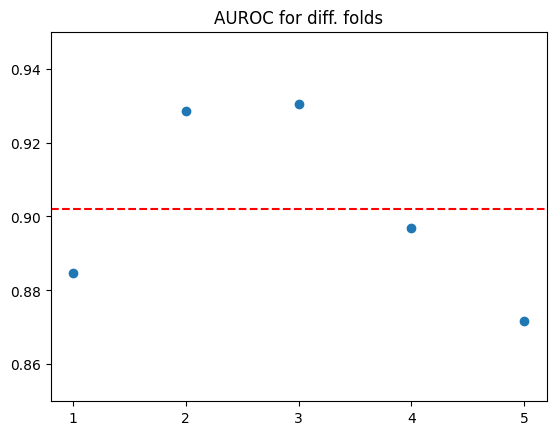

In [ ]:
plt.figure()
plt.scatter([i for i in range(1,6)], baseline_res['auc_roc'])
plt.xticks([i for i in range(1,6)])
plt.ylim(0.85, 0.95)
plt.axhline(y=0.902, color='red', linestyle='--', label='baseline')

plt.title('AUROC for diff. folds')
plt.show()

##### learning curves

proccessing 0
proccessing 1
proccessing 2
proccessing 3
proccessing 4
proccessing 5
proccessing 6
proccessing 7
proccessing 8
proccessing 9


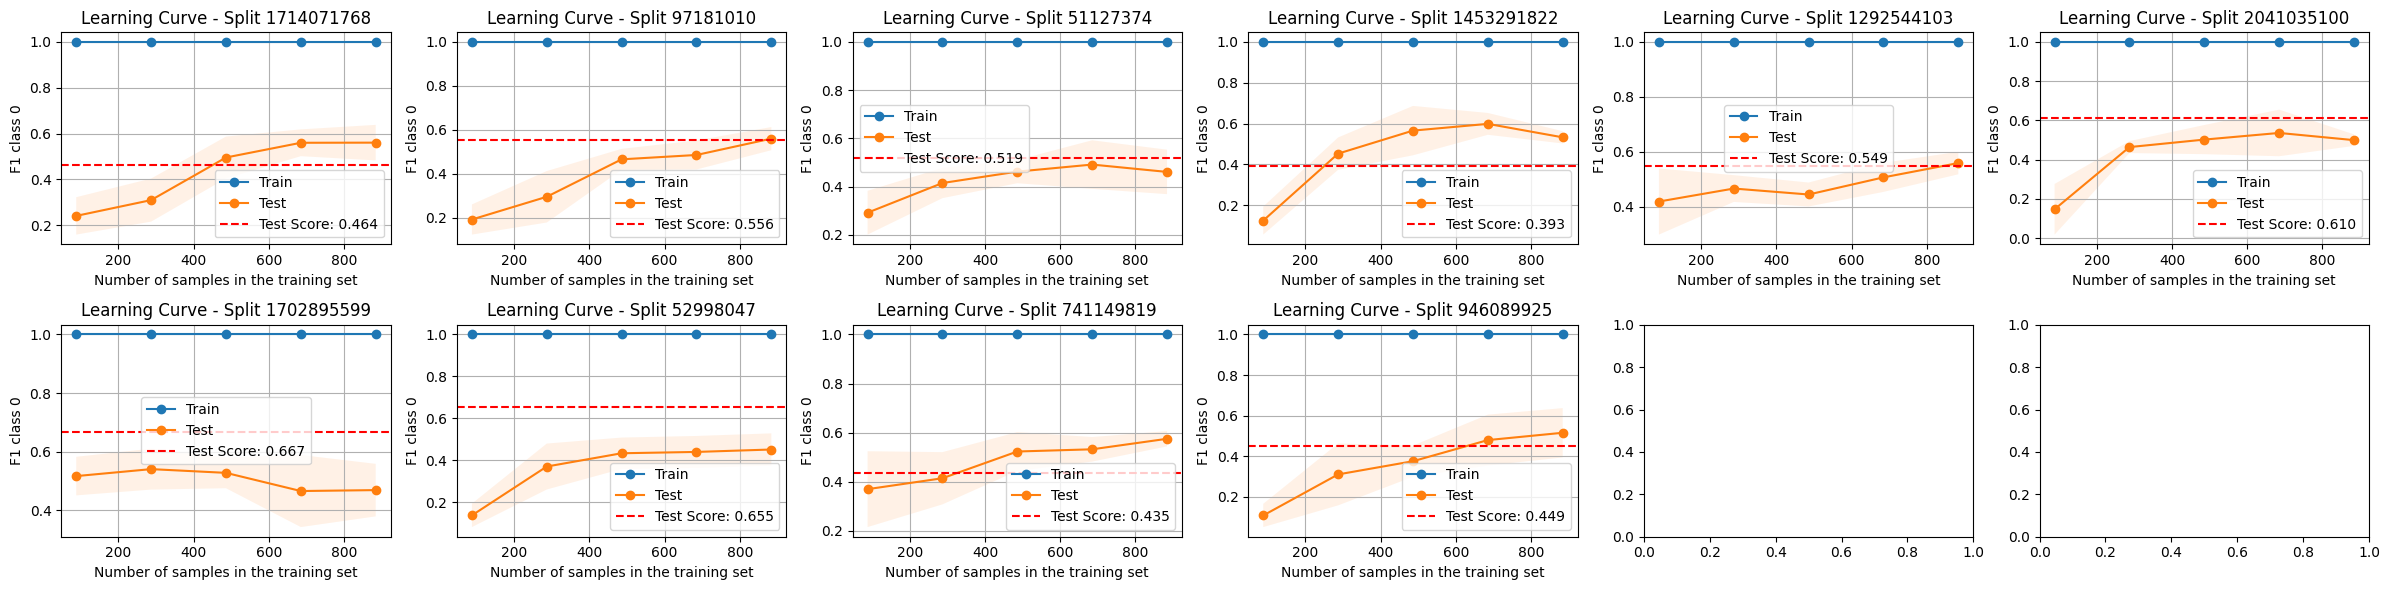

In [ ]:
def preProc(r):
    metadata  = pd.read_csv('/content/metadata.csv')
    microbiome = pd.read_csv('/content/microbiome.csv')
    serum_lipo = pd.read_csv('/content/serum_lipo.csv')

    metadata['is_sick'] = (metadata['PATGROUPFINAL_C'] != '8').astype(int)
    metadata = metadata.drop(columns=['PATGROUPFINAL_C'])

    taxa_columns = microbiome.drop(columns=['SampleID']).columns

    metabolite_columns = serum_lipo.drop(columns=['SampleID']).columns

    merged = pd.merge(metadata, microbiome, how='inner', on='SampleID')
    merged = pd.merge(merged, serum_lipo, how='inner', on='SampleID')
    merged = merged.drop(columns=['SampleID'])

    X = merged.drop(columns=['is_sick'])
    y = merged['is_sick']
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y, random_state=r)

    standard_cols = list(metabolite_columns)
    abundance_cols = list(taxa_columns)

    def relative_abundance(X):
        return X.div(X.sum(axis=1), axis=0)

    def std_nan(X):
        return (X - np.nanmean(X)) / np.nanstd(X)

    preprocessor = ColumnTransformer([
    ('standard', FunctionTransformer(std_nan), standard_cols),
    ('abundance', FunctionTransformer(relative_abundance), abundance_cols)
    ], remainder='passthrough', verbose_feature_names_out=False)
    preprocessor.set_output(transform="pandas")

    m_age = np.nanmean(X_train['AGE'])
    s_age = np.nanstd(X_train['AGE'])
    X_train['AGE'] = (X_train['AGE'] - m_age) / s_age
    X_test['AGE'] = (X_test['AGE'] - m_age) / s_age

    m_DDS = np.nanmean(X_train['DDS'])
    s_DDS = np.nanstd(X_train['DDS'])
    X_train['DDS'] = (X_train['DDS'] - m_DDS) / s_DDS
    X_test['DDS'] = (X_test['DDS'] - m_DDS) / s_DDS

    X_train_transformed = preprocessor.fit_transform(X_train)
    X_test_transformed = preprocessor.transform(X_test)
    le = LabelEncoder()
    X_train_transformed['CENTER_C'] = le.fit_transform(X_train_transformed['CENTER_C'])
    X_test_transformed['CENTER_C'] = le.fit_transform(X_test_transformed['CENTER_C'])

    return (X_test_transformed, X_train_transformed, y_train, y_test)


def f1_class_0(y_true, y_pred):
    return f1_score(y_true, y_pred, pos_label=0)

f1_class_0_scorer = make_scorer(f1_class_0)
f1_class_0_scorer.__name__ = 'f1_class_0'

def compare_learning_curves_across_splits(n_splits=30):

    ncols = min(n_splits, 6)  # Max 6 columns to keep plots readable
    nrows = math.ceil(n_splits / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))

    if n_splits == 1:
        axes = [axes]
    elif nrows == 1:
        axes = axes if ncols > 1 else [axes]
    else:
        axes = axes.ravel()
    seeds = []
    for i in range(n_splits):
        seeds.append(random.randint(3, 2**31-1))

    for i, seed in enumerate(seeds):
        print(f"proccessing {i}")
        X_test, X_train, y_train, y_test = preProc(seed)

        model = XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss'
            )

        LearningCurveDisplay.from_estimator(
            model, X_train, y_train,
            cv=None,
            n_jobs=-1,
            scoring=f1_class_0_scorer,
            ax=axes[i],
            line_kw={"marker": "o"},
            fill_between_kw={"alpha": 0.1}
        )

        axes[i].set_title(f'Learning Curve - Split {seed}')
        axes[i].grid(True)

        # Also show the final test performance on this split
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        test_score = f1_score(y_test, y_pred, pos_label=0)
        axes[i].axhline(y=test_score, color='red', linestyle='--',
                       label=f'Test Score: {test_score:.3f}')
        axes[i].legend()

    plt.tight_layout()
    plt.show()

compare_learning_curves_across_splits(n_splits = 10)

In [ ]:
def f1_class_0_callback(y_true, y_pred):
    if y_pred.min() < 0 or y_pred.max() > 1:
        y_pred = 1 / (1 + np.exp(-y_pred))  # sigmoid transformation
    y_pred_binary = (y_pred > 0.5).astype(int)
    return f1_score(y_true, y_pred_binary, pos_label=0)


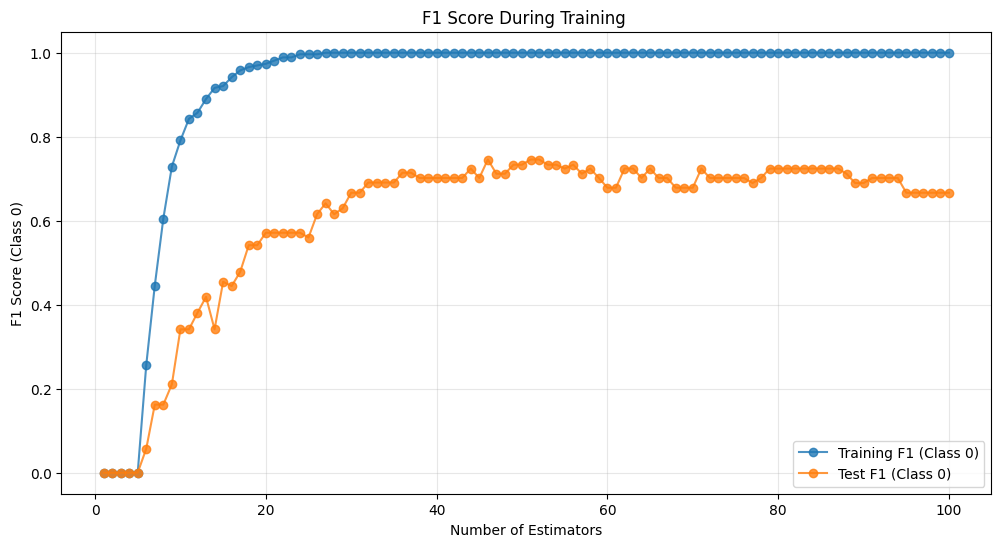

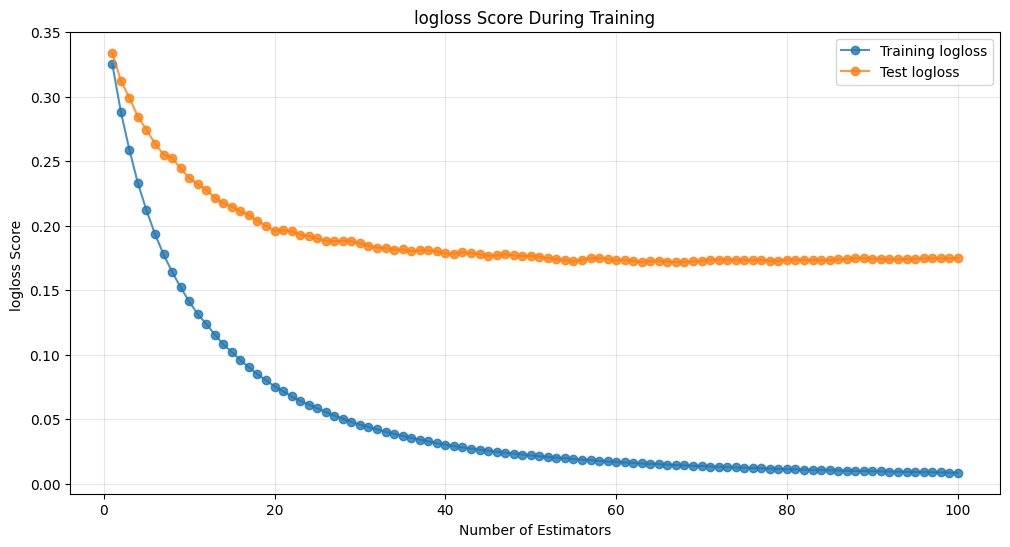

In [ ]:
    model = XGBClassifier(
        n_estimators=100,
        learning_rate = 0.1,
        objective='binary:logistic',
        eval_metric=f1_class_0_callback,  # Custom F1 for class 0
        )

    model.fit(
        X_train_transformed, y_train,
        eval_set=[(X_train_transformed, y_train), (X_test_transformed, y_test)],
        verbose=False
    )

    results = model.evals_result()

    estimators = range(1, len(results['validation_0']['f1_class_0_callback']) + 1)
    train_f1 = results['validation_0']['f1_class_0_callback']
    test_f1 = results['validation_1']['f1_class_0_callback']

    best_idx = np.argmax(test_f1)
    best_n_estimators = estimators[best_idx]
    best_score = test_f1[best_idx]
    print(f"Best number of estimators: {best_n_estimators}")
    print(f"Best F1 score: {best_score}")

    # Plot f1
    plt.figure(figsize=(12, 6))
    plt.plot(estimators, train_f1, 'o-', label='Training F1 (Class 0)', alpha=0.8)
    plt.plot(estimators, test_f1, 'o-', label='Test F1 (Class 0)', alpha=0.8)

    plt.xlabel('Number of Estimators')
    plt.ylabel('F1 Score (Class 0)')
    plt.title('F1 Score During Training ')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    estimators = range(1, len(results['validation_0']['logloss']) + 1)
    train_logloss = results['validation_0']['logloss']
    test_logloss = results['validation_1']['logloss']

    plt.figure(figsize=(12, 6))
    plt.plot(estimators, train_logloss, 'o-', label='Training logloss', alpha=0.8)
    plt.plot(estimators, test_logloss, 'o-', label='Test logloss', alpha=0.8)

    plt.xlabel('Number of Estimators')
    plt.ylabel('logloss Score ')
    plt.title('logloss Score During Training')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

##### limiting depth

In [ ]:
# all

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    enable_categorical=True
)

xgb_model.fit(X_train_transformed, y_train)

y_pred = xgb_model.predict(X_test_transformed)
y_pred_proba = xgb_model.predict_proba(X_test_transformed)[:, 1]  # Probabilities for positive class

# Calculate metrics
auc_roc = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)

print(f"AUC-ROC: {auc_roc:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

AUC-ROC: 0.9194
F1 Score: 0.9499

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.44      0.55        34
           1       0.93      0.98      0.95       243

    accuracy                           0.91       277
   macro avg       0.82      0.71      0.75       277
weighted avg       0.90      0.91      0.90       277



In [ ]:
# all with max depth

def test_max_depth(i, X_train, X_test, y_train, y_test):
    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',
        max_depth = i,
        eval_metric='logloss',
        enable_categorical=True
    )

    xgb_model.fit(X_train, y_train)

    y_pred = xgb_model.predict(X_test)
    y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]  # Probabilities for positive class

    # Calculate metrics
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    #f1 = f1_score(y_test, y_pred)
    class_report = classification_report(y_test, y_pred, output_dict=True)

    #return (class_report['0']['f1-score'], class_report['1']['f1-score'], auc_roc, f1)
    return (class_report['0']['f1-score'], auc_roc)

depth_res = []
for j, split in enumerate(splits):
    X_train, X_test, y_train, y_test,_ = split
    for i in range(1,21):
        f1, auc_roc = test_max_depth(i, X_train, X_test, y_train, y_test)
        depth_res.append({
            'split': j,
            'depth': i,
            'f1': f1,
            'auc_roc': auc_roc
        })

depth_res = pd.DataFrame(depth_res)


5
5
5
5
5


In [ ]:
baseline_res

,split,depth,f1,auc_roc
0,0,19,0.596491,0.884713
1,1,19,0.566038,0.928589
2,2,19,0.538462,0.930404
3,3,19,0.518519,0.896877
4,4,19,0.470588,0.871702


In [ ]:
depth_res_merged = depth_res.merge(baseline_res, on=['split'], how='left', suffixes=('', '_baseline'))

In [ ]:
#depth_res_merged.drop(columns=['depth_baseline'], inplace=True)
depth_res_merged['f1_diff'] = depth_res_merged['f1'] - depth_res_merged['f1_baseline']
depth_res_merged['auc_roc_diff'] = depth_res_merged['auc_roc'] - depth_res_merged['auc_roc_baseline']
depth_res_merged

,split,depth,f1,auc_roc,f1_baseline,auc_roc_baseline,f1_diff,auc_roc_diff
0,0,0,0.490566,0.868797,0.596491,0.884713,-0.105925,-0.015916
1,0,1,0.551724,0.856572,0.596491,0.884713,-0.044767,-0.028141
2,0,2,0.555556,0.889615,0.596491,0.884713,-0.040936,0.004902
3,0,3,0.610169,0.882353,0.596491,0.884713,0.013678,-0.002360
4,0,4,0.555556,0.893367,0.596491,0.884713,-0.040936,0.008654
...,...,...,...,...,...,...,...,...
95,4,15,0.431373,0.858872,0.470588,0.871702,-0.039216,-0.012830
96,4,16,0.431373,0.858872,0.470588,0.871702,-0.039216,-0.012830
97,4,17,0.431373,0.858872,0.470588,0.871702,-0.039216,-0.012830
98,4,18,0.431373,0.858872,0.470588,0.871702,-0.039216,-0.012830


In [ ]:
depth_res_grouped = depth_res_merged.groupby('depth').mean()
depth_res_grouped

,split,f1,auc_roc,f1_baseline,auc_roc_baseline,f1_diff,auc_roc_diff
depth,,,,,,,
0,2.0,0.488016,0.889325,0.538019,0.902457,-0.050003,-0.013132
1,2.0,0.556405,0.886734,0.538019,0.902457,0.018386,-0.015723
2,2.0,0.566517,0.908376,0.538019,0.902457,0.028498,0.005919
3,2.0,0.571519,0.898039,0.538019,0.902457,0.033499,-0.004418
4,2.0,0.551664,0.903244,0.538019,0.902457,0.013645,0.000787
5,2.0,0.531831,0.906354,0.538019,0.902457,-0.006189,0.003897
6,2.0,0.538019,0.902457,0.538019,0.902457,0.000000,0.000000
7,2.0,0.521250,0.896163,0.538019,0.902457,-0.016769,-0.006294
8,2.0,0.538438,0.901888,0.538019,0.902457,0.000418,-0.000569


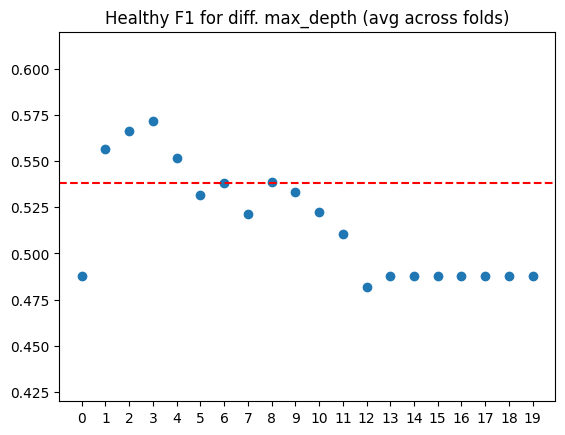

In [ ]:
plt.figure()
plt.scatter([i for i in range(20)], depth_res_grouped['f1'])
plt.xticks([i for i in range(20)])
plt.ylim(0.42, 0.62)
plt.axhline(y=0.538, color='red', linestyle='--', label='baseline')


plt.title('Healthy F1 for diff. max_depth (avg across folds)')
plt.show()

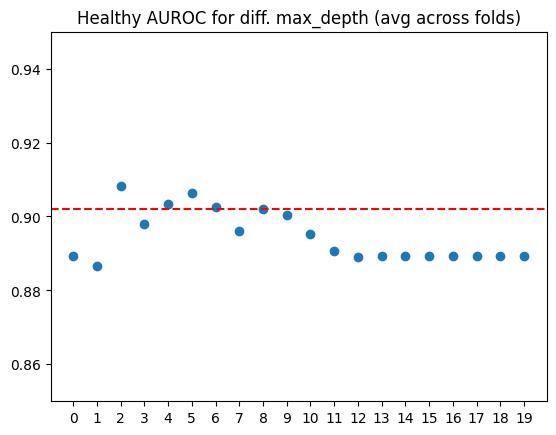

In [ ]:
plt.figure()
plt.scatter([i for i in range(20)], depth_res_grouped['auc_roc'])
plt.xticks([i for i in range(20)])
plt.ylim(0.85, 0.95)
plt.axhline(y=0.902, color='red', linestyle='--', label='baseline')


plt.title('Healthy AUROC for diff. max_depth (avg across folds)')
plt.show()

##### min child weight

In [ ]:
# all with max depth

def test_min_child(i, X_train, X_test, y_train, y_test):
    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',
        min_child_weight = i,
        eval_metric='logloss',
        enable_categorical=True
    )

    xgb_model.fit(X_train, y_train)

    y_pred = xgb_model.predict(X_test)
    y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]  # Probabilities for positive class

    # Calculate metrics
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    #f1 = f1_score(y_test, y_pred)
    class_report = classification_report(y_test, y_pred, output_dict=True)

    #return (class_report['0']['f1-score'], class_report['1']['f1-score'], auc_roc, f1)
    return (class_report['0']['f1-score'], auc_roc)

min_child_res = []
for j, split in enumerate(splits):
    print(j)
    X_train, X_test, y_train, y_test,_ = split
    for i in range(1,21):
        f1, auc_roc = test_min_child(i, X_train, X_test, y_train, y_test)
        min_child_res.append({
            'split': j,
            'min_child_weight': i,
            'f1': f1,
            'auc_roc': auc_roc
        })

min_child_res = pd.DataFrame(min_child_res)


0
1
2
3
4


In [ ]:
min_child_res_merged = min_child_res.merge(baseline_res, on=['split'], how='left', suffixes=('', '_baseline'))
min_child_res_merged.drop(columns=['depth'], inplace=True)
min_child_res_merged['f1_diff'] = min_child_res_merged['f1'] - min_child_res_merged['f1_baseline']
min_child_res_merged['auc_roc_diff'] = min_child_res_merged['auc_roc'] - min_child_res_merged['auc_roc_baseline']
min_child_res_grouped = min_child_res_merged.groupby('min_child_weight').mean()
min_child_res_grouped

,split,f1,auc_roc,f1_baseline,auc_roc_baseline,f1_diff,auc_roc_diff
min_child_weight,,,,,,,
1,2.0,0.538019,0.902457,0.538019,0.902457,0.000000,0.000000
2,2.0,0.580496,0.902808,0.538019,0.902457,0.042476,0.000351
3,2.0,0.558472,0.907988,0.538019,0.902457,0.020452,0.005531
4,2.0,0.587315,0.896345,0.538019,0.902457,0.049295,-0.006112
5,2.0,0.561998,0.898063,0.538019,0.902457,0.023979,-0.004394
6,2.0,0.594152,0.901307,0.538019,0.902457,0.056132,-0.001150
7,2.0,0.548971,0.896611,0.538019,0.902457,0.010951,-0.005846
8,2.0,0.574872,0.902251,0.538019,0.902457,0.036853,-0.000206
9,2.0,0.587532,0.899201,0.538019,0.902457,0.049513,-0.003256


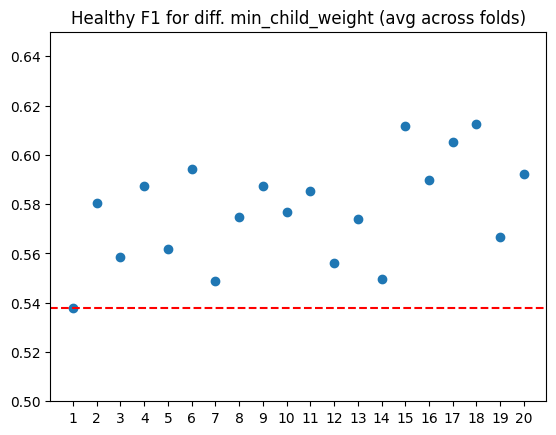

In [ ]:
plt.figure()
plt.scatter([i for i in range(1,21)], min_child_res_grouped['f1'])
plt.xticks([i for i in range(1,21)])
plt.ylim(0.5, 0.65)
plt.axhline(y=0.538, color='red', linestyle='--', label='baseline')

plt.title('Healthy F1 for diff. min_child_weight (avg across folds)')
plt.show()

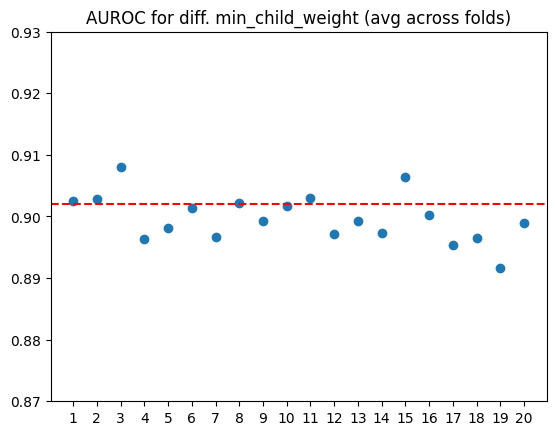

In [ ]:
plt.figure()
plt.scatter([i for i in range(1,21)], min_child_res_grouped['auc_roc'])
plt.xticks([i for i in range(1,21)])
plt.ylim(0.87,0.93)
plt.axhline(y=0.902, color='red', linestyle='--', label='baseline')

plt.title('AUROC for diff. min_child_weight (avg across folds)')
plt.show()

##### Learninig rate

In [ ]:
def test_lr(i, X_train, X_test, y_train, y_test):
    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',
        learning_rate = i,
        eval_metric='logloss',
        enable_categorical=True
    )

    xgb_model.fit(X_train, y_train)

    y_pred = xgb_model.predict(X_test)
    y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]  # Probabilities for positive class

    # Calculate metrics
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    #f1 = f1_score(y_test, y_pred)
    class_report = classification_report(y_test, y_pred, output_dict=True)

    #return (class_report['0']['f1-score'], class_report['1']['f1-score'], auc_roc, f1)
    return (class_report['0']['f1-score'], auc_roc)

lr_res = []
for j, split in enumerate(splits):
    print(j)
    X_train, X_test, y_train, y_test,_ = split
    for i in [0.02, 0.05, 0.075, 0.09, 0.1, 0.12, 0.15, 0.175, 0.2, 0.25, 0.3, 0.35, 0.4]:
        f1, auc_roc = test_lr(i, X_train, X_test, y_train, y_test)
        lr_res.append({
            'split': j,
            'lr': i,
            'f1': f1,
            'auc_roc': auc_roc
        })

lr_res = pd.DataFrame(lr_res)


0
1
2
3
4


In [ ]:
lr_res_merged = lr_res.merge(baseline_res, on=['split'], how='left', suffixes=('', '_baseline'))
lr_res_merged.drop(columns=['depth'], inplace=True)
lr_res_merged['f1_diff'] = lr_res_merged['f1'] -lr_res_merged['f1_baseline']
lr_res_merged['auc_roc_diff'] = lr_res_merged['auc_roc'] - lr_res_merged['auc_roc_baseline']
lr_res_grouped = lr_res_merged.groupby('lr').mean()
lr_res_grouped

,split,f1,auc_roc,f1_baseline,auc_roc_baseline,f1_diff,auc_roc_diff
lr,,,,,,,
0.020,2.0,0.455342,0.878262,0.538019,0.902457,-0.082678,-0.024195
0.050,2.0,0.484600,0.900266,0.538019,0.902457,-0.053419,-0.002191
0.075,2.0,0.518456,0.904091,0.538019,0.902457,-0.019564,0.001634
0.090,2.0,0.538199,0.905640,0.538019,0.902457,0.000180,0.003183
0.100,2.0,0.541409,0.900460,0.538019,0.902457,0.003389,-0.001997
0.120,2.0,0.549936,0.907480,0.538019,0.902457,0.011916,0.005023
0.150,2.0,0.544966,0.911353,0.538019,0.902457,0.006947,0.008896
0.175,2.0,0.536369,0.907819,0.538019,0.902457,-0.001650,0.005362
0.200,2.0,0.519883,0.906754,0.538019,0.902457,-0.018137,0.004297


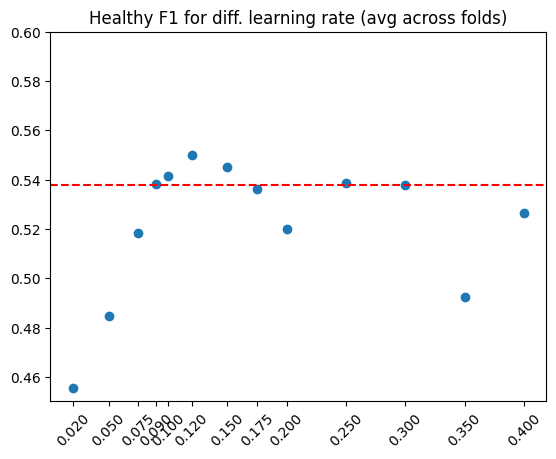

In [ ]:
plt.figure()
plt.scatter([0.02, 0.05, 0.075, 0.09, 0.1, 0.12, 0.15, 0.175, 0.2, 0.25, 0.3, 0.35, 0.4], lr_res_grouped['f1'])
plt.xticks([0.02, 0.05, 0.075, 0.09, 0.1, 0.12, 0.15, 0.175, 0.2, 0.25, 0.3, 0.35, 0.4])
plt.xticks(rotation=45)
plt.ylim(0.45, 0.6)
plt.axhline(y=0.538, color='red', linestyle='--', label='baseline')

plt.title('Healthy F1 for diff. learning rate (avg across folds)')
plt.show()

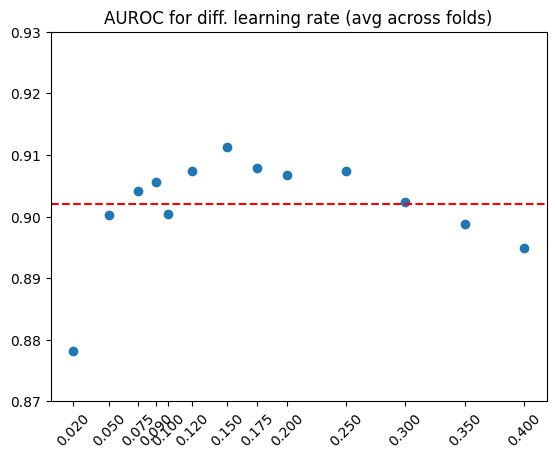

In [ ]:
plt.figure()
plt.scatter([0.02, 0.05, 0.075, 0.09, 0.1, 0.12, 0.15, 0.175, 0.2, 0.25, 0.3, 0.35, 0.4], lr_res_grouped['auc_roc'])
plt.xticks([0.02, 0.05, 0.075, 0.09, 0.1, 0.12, 0.15, 0.175, 0.2, 0.25, 0.3, 0.35, 0.4])
plt.xticks(rotation=45)
plt.ylim(0.87, 0.93)
plt.axhline(y=0.902, color='red', linestyle='--', label='baseline')

plt.title('AUROC for diff. learning rate (avg across folds)')
plt.show()

##### choosing best n_estimators

In [ ]:
def test_est(X_train, X_test, y_train, y_test):

    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',
        n_estimators = 200,
        eval_metric=f1_class_0_callback,
        enable_categorical=True
        )
    xgb_model.fit(X_train, y_train,  eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

    results = xgb_model.evals_result()


    estimators = range(1, len(results['validation_0']['f1_class_0_callback']) + 1)
    train_f1 = results['validation_0']['f1_class_0_callback']
    test_f1 = results['validation_1']['f1_class_0_callback']

    best_idx = np.argmax(test_f1)
    best_n_estimators = estimators[best_idx]
    best_score = test_f1[best_idx]

    estimators = range(1, len(results['validation_0']['logloss']) + 1)
    train_logloss = results['validation_0']['logloss']
    test_logloss = results['validation_1']['logloss']

    xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators = best_n_estimators,
    eval_metric=f1_class_0_callback,
    enable_categorical=True
    )
    xgb_model.fit(X_train, y_train)

    y_pred = xgb_model.predict(X_test)
    y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]  # Probabilities for positive class
    # Calculate metrics
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    #f1 = f1_score(y_test, y_pred)
    class_report = classification_report(y_test, y_pred, output_dict=True)

    #return (class_report['0']['f1-score'], class_report['1']['f1-score'], auc_roc, f1)
    return (class_report['0']['f1-score'], auc_roc, best_n_estimators, best_score)

est_res = []
for j, split in enumerate(splits):
    print(j)
    X_train, X_test, y_train, y_test,_ = split
    f1, auc_roc , best_n_estimators, best_score = test_est( X_train, X_test, y_train, y_test)
    est_res.append({
        'split': j,
        'f1': f1,
        'auc_roc': auc_roc,
        'best_n_estimators': best_n_estimators,
        'best_score': best_score
    })

est_res = pd.DataFrame(est_res)

0
1
2
3
4


In [ ]:
est_res_merged = est_res.merge(baseline_res, on=['split'], how='left', suffixes=('', '_baseline'))
est_res_mQerged['f1_diff'] = est_res_merged['f1'] - est_res_merged['f1_baseline']
est_res_merged['auc_roc_diff'] = est_res_merged['auc_roc'] - est_res_merged['auc_roc_baseline']


In [ ]:
est_res_merged

,split,f1,auc_roc,best_n_estimators,best_score,f1_baseline,auc_roc_baseline,f1_diff,auc_roc_diff
0,0,0.596491,0.884047,78,0.596491,0.596491,0.884713,0.000000,-0.000666
1,1,0.588235,0.928952,119,0.588235,0.566038,0.928589,0.022198,0.000363


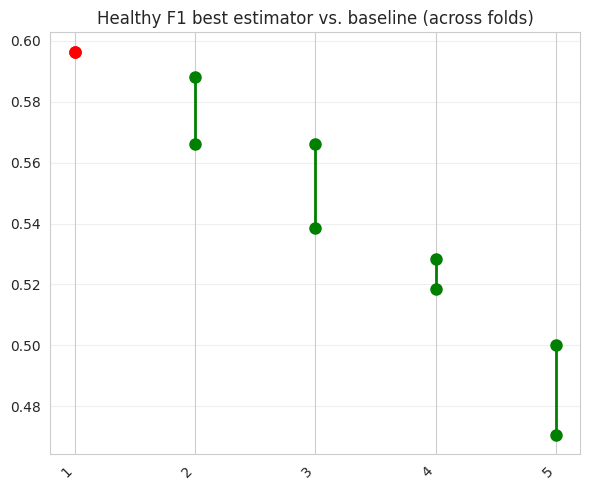

In [ ]:
# Set seaborn style
sns.set_style("whitegrid")

# Sample data
samples = ['1', '2', '3', '4', '5']
value1 = est_res_merged['f1_baseline']
value2 = est_res_merged['f1']

fig, ax = plt.subplots(figsize=(6, 5))

x_pos = range(len(samples))

# Draw connecting lines vertically
for i, sample in enumerate(samples):
    color = 'green' if value2[i] > value1[i] else 'red'
    ax.plot([i, i], [value1[i], value2[i]], 'o-',
            color=color, linewidth=2, markersize=8)

# Customize
ax.set_xticks(x_pos)
ax.set_xticklabels(samples, rotation=45, ha='right')
ax.set_title('Healthy F1 best estimator vs. baseline (across folds)')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

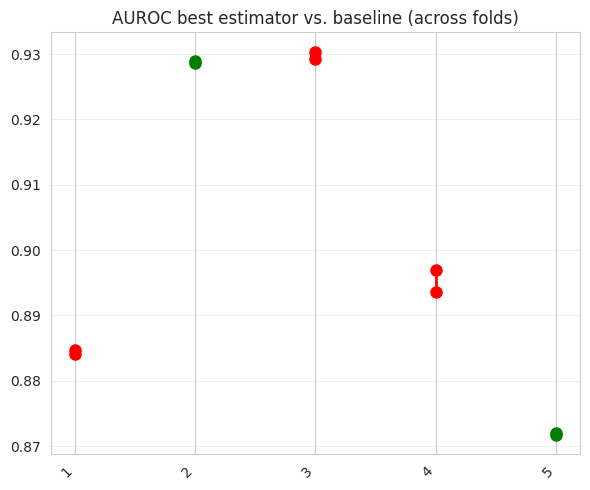

In [ ]:
# Set seaborn style
sns.set_style("whitegrid")

# Sample data
samples = ['1', '2', '3', '4', '5']
value1 = est_res_merged['auc_roc_baseline']
value2 = est_res_merged['auc_roc']

fig, ax = plt.subplots(figsize=(6, 5))

x_pos = range(len(samples))

# Draw connecting lines vertically
for i, sample in enumerate(samples):
    color = 'green' if value2[i] > value1[i] else 'red'
    ax.plot([i, i], [value1[i], value2[i]], 'o-',
            color=color, linewidth=2, markersize=8)

# Customize
ax.set_xticks(x_pos)
ax.set_xticklabels(samples, rotation=45, ha='right')
ax.set_title('AUROC best estimator vs. baseline (across folds)')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
est_res_merged['f1'].mean()

np.float64(0.5558132289658664)

#### grid cv

In [ ]:
def f1_class_0_callback(y_true, y_pred):
    if y_pred.min() < 0 or y_pred.max() > 1:
        y_pred = 1 / (1 + np.exp(-y_pred))  # sigmoid transformation
    y_pred_binary = (y_pred > 0.5).astype(int)
    return f1_score(y_true, y_pred_binary, pos_label=0)

def aupr_eval_metric(y_true, y_pred):
    if y_pred.min() < 0 or y_pred.max() > 1:
        y_pred = 1 / (1 + np.exp(-y_pred))  # sigmoid transformation
    return average_precision_score(y_true, y_pred)


In [ ]:

def grid(X_train, X_test, y_train, y_test, depth, min_ch_weight, lr, loss, gamma, alpha, en_neg, en_pos, with_svmsmote):

    if loss == 'focal':
        focal_loss = FocalLoss(gamma=gamma, alpha=alpha)
        obj = focal_loss.sk_obj
    elif loss == 'cb':
        cb = CBLoss(en_pos, en_neg)
        obj = cb.cb_obj
    else:
        obj = loss

    if with_svmsmote:
        y_copy=y_train.copy()
        X_copy = X_train.copy()
        X_copy['label'] = y_copy
        X_copy =X_copy.dropna()
        y_copy = X_copy['label']
        X_copy.drop(columns=['label'], inplace=True)
        n = len(X_copy)

        sm = SVMSMOTE(sampling_strategy=0.35)
        X_resampled, y_resampled = sm.fit_resample(X_copy, y_copy)

        X_add = X_resampled.iloc[n+1:]
        y_add = pd.Series(np.zeros(len(X_add), dtype=np.int64))

        X_train = pd.concat([X_train, X_add], ignore_index=True)
        y_train = pd.concat([y_train, y_add], ignore_index=True)

    xgb_model = xgb.XGBClassifier(
        tree_method='hist',
        device='cuda',
        objective=obj,
        max_depth = depth,
        min_child_weight = min_ch_weight,
        learning_rate = lr,
        n_estimators = 200,
        eval_metric=aupr_eval_metric,
        enable_categorical=True
    )
    xgb_model.fit(X_train, y_train,  eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)
    results = xgb_model.evals_result()

    estimators = range(1, len(results['validation_0']['aupr_eval_metric']) + 1)
    train_aupr = results['validation_0']['aupr_eval_metric']
    test_aupr = results['validation_1']['aupr_eval_metric']

    best_idx = np.argmax(test_aupr)
    best_n_estimators = estimators[best_idx]
    best_score = test_aupr[best_idx]

    xgb_model = xgb.XGBClassifier(
        tree_method='hist',
        device='cuda',
        objective=obj,
        max_depth = depth,
        min_child_weight = min_ch_weight,
        learning_rate = lr,
        n_estimators = best_n_estimators,
        eval_metric=aupr_eval_metric,
        enable_categorical=True
    )
    xgb_model.fit(X_train, y_train)

    y_pred = xgb_model.predict(X_test)
    y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]  # Probabilities for positive class

    # Calculate metrics
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    #f1 = f1_score(y_test, y_pred)
    class_report = classification_report(y_test, y_pred, output_dict=True)
    sklearn_ap = average_precision_score(y_test, y_pred_proba)


    #return (class_report['0']['f1-score'], class_report['1']['f1-score'], auc_roc, f1)
    return (class_report['0']['f1-score'], auc_roc, sklearn_ap, best_n_estimators, y_pred_proba)

splits_resampled = []
np.random.seed(1)
for j, split in enumerate(splits):
    X_train, X_test, y_train, y_test, seed = split

    healthy_idx = y_test[y_test == 0].index
    sick_idx = y_test[y_test == 1].index
    n_sick = len(sick_idx)
    n_healthy_current = len(healthy_idx)
    n_healthy_needed = int(n_sick * (0.9 / 0.1))
    n_to_add = n_healthy_needed - n_healthy_current
    additional_healthy_idx = np.random.choice(healthy_idx, size=n_to_add, replace=True)
    all_idx = list(X_test.index) + list(additional_healthy_idx)
    X_test = X_test.loc[all_idx].reset_index(drop=True)
    y_test = y_test.loc[all_idx].reset_index(drop=True)
    splits_resampled.append([X_train, X_test, y_train, y_test, seed])

with open('/content/drive/MyDrive/splits_resampled.pickle', 'wb') as file:
    pickle.dump(splits_resampled, file)

res = []
permutations = 5 * 4 * 5 * 1 * 1 * 1  # splits * depth * min_ch * lr * svmsmote * loss
iteration = 0
start_time = time.time()

for j, split in enumerate(splits_resampled):
    X_train, X_test, y_train, y_test,_ = split
    for depth in [1, 2, 3, 4]:
        for min_ch_weight in [3, 6, 9, 12, 15]:
            for lr in [0.12]:
                for with_svmsmote in [False]:
                    for loss in ['binary:logistic']:
                        beta = (len(X_train) -1 ) / len(X_train)
                        en_neg =  (1-beta) / (1-beta**len(y_train[y_train==0]))
                        en_pos =  (1-beta) / (1-beta**len(y_train[y_train==1]))
                        gamma_values = [1.8, 2, 2.2, 2.5] if loss == 'focal' else [-1]
                        alpha_values = [0.11, 0.13, 0.15] if loss == 'focal' else [-1]
                        for gamma in gamma_values:
                            for alpha in alpha_values:
                                iteration += 1
                                if iteration == 25:
                                    elapsed = time.time() - start_time
                                    print(f"\n25 iterations took {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")
                                    print(f"Estimated total time: {elapsed * permutations / 25 / 3600:.2f} hours")
                                print(f'testing iteration: {iteration/permutations}')
                                f1, auc_roc, sklearn_ap, best_n_estimators, y_pred_proba = grid(
                                    X_train = X_train,
                                    X_test = X_test,
                                    y_train = y_train,
                                    y_test = y_test,
                                    depth = depth,
                                    min_ch_weight = min_ch_weight,
                                    lr = lr,
                                    loss = loss,
                                    gamma = gamma,
                                    alpha = alpha,
                                    en_neg = en_neg,
                                    en_pos = en_pos,
                                    with_svmsmote = with_svmsmote)

                                res.append({
                                    'split': j,
                                    'depth': depth,
                                    'min_ch_weight': min_ch_weight,
                                    'lr': lr,
                                    'loss': loss,
                                    'gamma':  gamma,
                                    'alpha': alpha,
                                    'en_neg': en_neg,
                                    'en_pos': en_pos,
                                    'with_svmsmote': with_svmsmote,
                                    'f1': f1,
                                    'auc_roc': auc_roc,
                                    'sklearn_ap': sklearn_ap,
                                    'best_n_estimators': best_n_estimators,
                                    'y_pred_proba': y_pred_proba
                                })

                                backup_path = f'/content/drive/MyDrive/grid_res_logloss_0410_{j}.pickle'
                                with open(backup_path, 'wb') as file:
                                    pickle.dump(res, file)

df_res = pd.DataFrame(res)





testing iteration: 0.0125


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:729: UserWarning: [13:30:55] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


testing iteration: 0.025
testing iteration: 0.0375
testing iteration: 0.05
testing iteration: 0.0625
testing iteration: 0.075
testing iteration: 0.0875
testing iteration: 0.1
testing iteration: 0.1125
testing iteration: 0.125
testing iteration: 0.1375
testing iteration: 0.15
testing iteration: 0.1625


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


testing iteration: 0.175
testing iteration: 0.1875
testing iteration: 0.2
testing iteration: 0.2125
testing iteration: 0.225


...

testing iteration: 1.0625


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


testing iteration: 1.075
testing iteration: 1.0875
testing iteration: 1.1
testing iteration: 1.1125
testing iteration: 1.125
testing iteration: 1.1375
testing iteration: 1.15
testing iteration: 1.1625


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


testing iteration: 1.175
testing iteration: 1.1875
testing iteration: 1.2
testing iteration: 1.2125
testing iteration: 1.225
testing iteration: 1.2375
testing iteration: 1.25


In [ ]:
splits_resampled = []
np.random.seed(1)
for j, split in enumerate(splits):
    X_train, X_test, y_train, y_test, seed = split

    healthy_idx = y_test[y_test == 0].index
    sick_idx = y_test[y_test == 1].index
    n_sick = len(sick_idx)
    n_healthy_current = len(healthy_idx)
    n_healthy_needed = int(n_sick * (0.9 / 0.1))
    n_to_add = n_healthy_needed - n_healthy_current
    additional_healthy_idx = np.random.choice(healthy_idx, size=n_to_add, replace=True)
    all_idx = list(X_test.index) + list(additional_healthy_idx)
    X_test = X_test.loc[all_idx].reset_index(drop=True)
    y_test = y_test.loc[all_idx].reset_index(drop=True)
    splits_resampled.append([X_train, X_test, y_train, y_test, seed])

In [ ]:
with open('/content/drive/MyDrive/grid_res_logloss_0410_4.pickle', 'rb') as file:
    res_logloss = pickle.load(file)

df_res_logloss = pd.DataFrame(res_logloss)

In [ ]:
def get_min_max_info(group):
    min_idx = group['sklearn_ap'].idxmin()
    max_idx = group['sklearn_ap'].idxmax()

    return pd.Series({
        'min_ap': group.loc[min_idx, 'sklearn_ap'],
        'min_depth': group.loc[min_idx, 'depth'],
        'min_ch_weight': group.loc[min_idx, 'min_ch_weight'],
        'max_ap': group.loc[max_idx, 'sklearn_ap'],
        'max_depth': group.loc[max_idx, 'depth'],
        'max_ch_weight': group.loc[max_idx, 'min_ch_weight'],
        'range': group['sklearn_ap'].max() - group['sklearn_ap'].min()
    })

split_stats = df_res_logloss.groupby('split').apply(get_min_max_info)
split_stats

/tmp/ipython-input-1199347523.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  split_stats = df_res_logloss.groupby('split').apply(get_min_max_info)


,min_ap,min_depth,min_ch_weight,max_ap,max_depth,max_ch_weight,range
split,,,,,,,
0,0.475069,1.0,3.0,0.615019,3.0,12.0,0.139949
1,0.638574,2.0,15.0,0.782811,2.0,6.0,0.144237
2,0.657202,1.0,3.0,0.782830,4.0,9.0,0.125629
3,0.658026,1.0,6.0,0.747041,3.0,3.0,0.089015
4,0.536541,1.0,3.0,0.697618,4.0,9.0,0.161077


In [ ]:
param_performance = df_res_logloss.groupby(['depth', 'min_ch_weight'])['sklearn_ap'].mean()
top_5 = param_performance.nlargest(10)
top_5

depth  min_ch_weight
3      12               0.691944
4      9                0.689372
3      3                0.682707
2      9                0.679713
3      9                0.674665
2      6                0.672072
4      12               0.671029
       6                0.667102
2      12               0.664041
3      6                0.656064
Name: sklearn_ap, dtype: float64

In [ ]:
param_performance = df_res_logloss.groupby(['depth', 'min_ch_weight'])['sklearn_ap'].median()
top_5 = param_performance.nlargest(10)
top_5

depth  min_ch_weight
3      3                0.739688
       9                0.713841
4      6                0.708680
       12               0.706536
       9                0.704149
3      12               0.699758
2      12               0.694243
3      6                0.692148
2      9                0.687950
4      3                0.685291
Name: sklearn_ap, dtype: float64

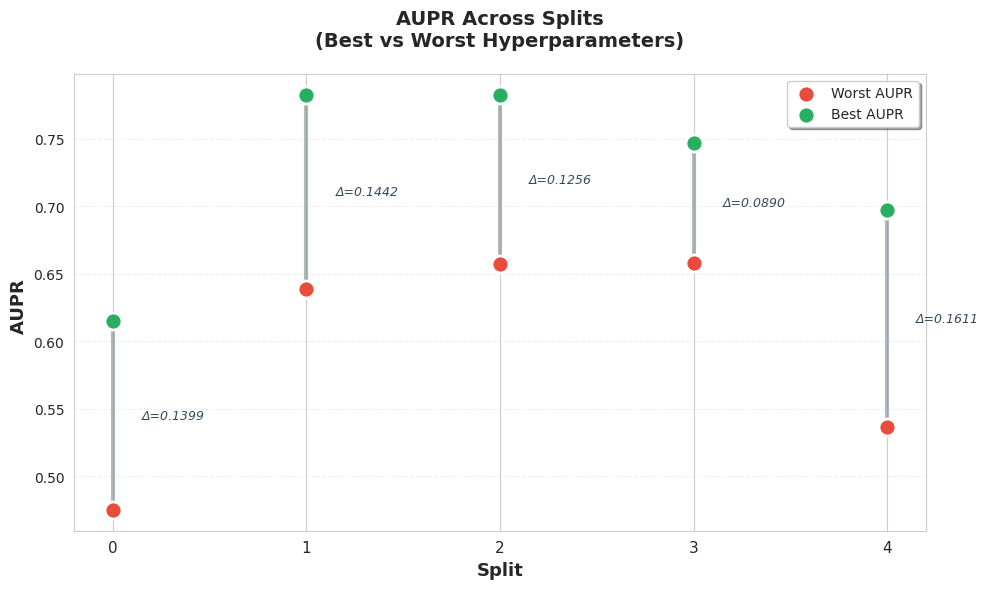


Summary Statistics:
Average range across splits: 0.1320
Largest range: 0.1611 (Split 4)
Smallest range: 0.0890 (Split 3)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

splits = split_stats.index.tolist()

fig, ax = plt.subplots(figsize=(10, 6))

# Color scheme
line_color = '#7f8c8d'
min_color = '#e74c3c'
max_color = '#27ae60'

x_pos = range(len(splits))

for i, split in enumerate(splits):
    min_val = split_stats.loc[split, 'min_ap']
    max_val = split_stats.loc[split, 'max_ap']
    range_val = split_stats.loc[split, 'range']

    ax.plot([i, i], [min_val, max_val],
            color=line_color, linewidth=3, alpha=0.6, zorder=1)

    ax.scatter(i, min_val,
              color=min_color,
              s=150, zorder=2,
              label='Worst AUPR' if i == 0 else "",
              edgecolors='white', linewidths=2)

    ax.scatter(i, max_val,
              color=max_color,
              s=150, zorder=2,
              label='Best AUPR' if i == 0 else "",
              edgecolors='white', linewidths=2)

    ax.text(i + 0.15, (min_val + max_val) / 2,
            f'Δ={range_val:.4f}',
            fontsize=9, va='center', style='italic', color='#34495e')

ax.set_xticks(x_pos)
ax.set_xticklabels(splits, rotation=0, fontsize=11)
ax.set_xlabel('Split', fontsize=13, fontweight='bold')
ax.set_ylabel('AUPR ', fontsize=13, fontweight='bold')
ax.set_title('AUPR Across Splits\n(Best vs Worst Hyperparameters)',
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')
ax.legend(loc='best', frameon=True, shadow=True, fontsize=10)

mean_performance = split_stats[['min_ap', 'max_ap']].values.flatten().mean()

plt.tight_layout()
plt.show()

print("\nSummary Statistics:")
print(f"Average range across splits: {split_stats['range'].mean():.4f}")
print(f"Largest range: {split_stats['range'].max():.4f} (Split {split_stats['range'].idxmax()})")
print(f"Smallest range: {split_stats['range'].min():.4f} (Split {split_stats['range'].idxmin()})")

In [ ]:
split_opt_params = {0: [3, 12], 1: [2,6], 2:[4,9], 3:[3,3], 4:[4,9]}
overall_opt_params = [3,12]

In [ ]:

def grid(X_train, X_test, y_train, y_test, depth, min_ch_weight, lr, loss, gamma, alpha, en_neg, en_pos, reg_alpha, reg_lambda):

    if loss == 'focal':
        focal_loss = FocalLoss(gamma=gamma, alpha=alpha)
        obj = focal_loss.sk_obj
    elif loss == 'cb':
        cb = CBLoss(100*en_pos, 100*en_neg)
        obj = cb.cb_obj
    else:
        obj = loss


    xgb_model = xgb.XGBClassifier(
        tree_method='hist',
        device='cuda',
        objective=obj,
        max_depth = depth,
        min_child_weight = min_ch_weight,
        learning_rate = lr,
        reg_alpha = reg_alpha,
        reg_lambda = reg_lambda,
        n_estimators = 200,
        eval_metric=aupr_eval_metric,
        enable_categorical=True
    )
    xgb_model.fit(X_train, y_train,  eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)
    results = xgb_model.evals_result()

    estimators = range(1, len(results['validation_0']['aupr_eval_metric']) + 1)
    train_aupr = results['validation_0']['aupr_eval_metric']
    test_aupr = results['validation_1']['aupr_eval_metric']

    best_idx = np.argmax(test_aupr)
    best_n_estimators = estimators[best_idx]
    best_score = test_aupr[best_idx]

    xgb_model = xgb.XGBClassifier(
        tree_method='hist',
        device='cuda',
        objective=obj,
        max_depth = depth,
        min_child_weight = min_ch_weight,
        learning_rate = lr,
        reg_alpha = reg_alpha,
        reg_lambda = reg_lambda,
        n_estimators = best_n_estimators,
        eval_metric=aupr_eval_metric,
        enable_categorical=True
    )
    xgb_model.fit(X_train, y_train)

    y_pred = xgb_model.predict(X_test)
    y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]  # Probabilities for positive class

    auc_roc = roc_auc_score(y_test, y_pred_proba)
    class_report = classification_report(y_test, y_pred, output_dict=True)
    sklearn_ap = average_precision_score(y_test, y_pred_proba)


    return (class_report['0']['f1-score'], auc_roc, sklearn_ap, best_n_estimators, y_pred_proba)

np.random.seed(1)
svm_smote_splits = []
for j, split in enumerate(splits_resampled):
    X_train, X_test, y_train, y_test, seed = split
    y_copy=y_train.copy()
    X_copy = X_train.copy()
    X_copy['label'] = y_copy
    X_copy =X_copy.dropna()
    y_copy = X_copy['label']
    X_copy.drop(columns=['label'], inplace=True)
    n = len(X_copy)

    sm = SVMSMOTE(sampling_strategy=0.35)
    X_resampled, y_resampled = sm.fit_resample(X_copy, y_copy)

    X_add = X_resampled.iloc[n+1:]
    y_add = pd.Series(np.zeros(len(X_add), dtype=np.int64))

    X_train_svmsmote = pd.concat([X_train, X_add], ignore_index=True)
    y_train_svmsmote = pd.concat([y_train, y_add], ignore_index=True)
    svm_smote_splits.append( [X_train_svmsmote, X_test, y_train_svmsmote, y_test, seed])


res = []
permutations = 5 * 2 *2 * 4 * 3 * 3 * (2 + 3)  # splits * * svmsmote * depth,min_ch * lr  * l1 * l2 * loss
iteration = 0
start_time = time.time()

for j, split in enumerate(splits_resampled):
    if j<=2:
        continue
    print(f'testing split {j}')

    for with_svmsmote in [False, True]:
        X_train, X_test, y_train, y_test,_ = split
        if with_svmsmote:
            X_train = svm_smote_splits[j][0]
            y_train = svm_smote_splits[j][2]

        for depth, min_ch_weight in [split_opt_params[j], overall_opt_params]:
            for lr in [0.09, 0.12, 0.15, 0.25]:
                for reg_alpha in [0, 0.02, 0.06]:
                    for reg_lambda in [0.5, 1, 2]:
                        for loss in ['binary:logistic', 'focal', 'cb']:
                            beta = (len(X_train) -1 ) / len(X_train)
                            en_neg =  (1-beta) / (1-beta**len(y_train[y_train==0]))
                            en_pos =  (1-beta) / (1-beta**len(y_train[y_train==1]))
                            gamma_values = [2, 2.2, 2.5] if loss == 'focal' else [-1]
                            alpha_values = [0.13] if loss == 'focal' else [-1]
                            for gamma in gamma_values:
                                for alpha in alpha_values:
                                    iteration += 1
                                    if iteration == 25:
                                        elapsed = time.time() - start_time
                                        print(f"\n25 iterations took {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")
                                        print(f"Estimated total time: {elapsed * permutations / 25 / 3600:.2f} hours")
                                    print(f'testing iteration: {iteration/permutations}')
                                    f1, auc_roc, sklearn_ap, best_n_estimators, y_pred_proba = grid(
                                        X_train = X_train,
                                        X_test = X_test,
                                        y_train = y_train,
                                        y_test = y_test,
                                        depth = depth,
                                        min_ch_weight = min_ch_weight,
                                        lr = lr,
                                        loss = loss,
                                        gamma = gamma,
                                        alpha = alpha,
                                        en_neg = en_neg,
                                        en_pos = en_pos,
                                        reg_alpha = reg_alpha,
                                        reg_lambda = reg_lambda)

                                    res.append({
                                        'split': j,
                                        'depth': depth,
                                        'min_ch_weight': min_ch_weight,
                                        'lr': lr,
                                        'loss': loss,
                                        'gamma':  gamma,
                                        'alpha': alpha,
                                        'en_neg': en_neg,
                                        'en_pos': en_pos,
                                        'with_svmsmote': with_svmsmote,
                                        'reg_alpha': reg_alpha,
                                        'reg_lambda': reg_lambda,
                                        'f1': f1,
                                        'auc_roc': auc_roc,
                                        'sklearn_ap': sklearn_ap,
                                        'best_n_estimators': best_n_estimators,
                                        'y_pred_proba': y_pred_proba
                                    })

                                    backup_path = f'/content/drive/MyDrive/grid_res_2nd_wave_0510_{j}.pickle'
                                    with open(backup_path, 'wb') as file:
                                        pickle.dump(res, file)
                                    print(f'saved at {backup_path}')

df_res = pd.DataFrame(res)





testing split 3
testing iteration: 0.0002777777777777778


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:729: UserWarning: [12:18:53] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


saved at /content/drive/MyDrive/grid_res_2nd_wave_0510_3.pickle
testing iteration: 0.0005555555555555556
saved at /content/drive/MyDrive/grid_res_2nd_wave_0510_3.pickle
testing iteration: 0.0008333333333333334
saved at /content/drive/MyDrive/grid_res_2nd_wave_0510_3.pickle
testing iteration: 0.0011111111111111111
saved at /content/drive/MyDrive/grid_res_2nd_wave_0510_3.pickle
testing iteration: 0.001388888888888889


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


saved at /content/drive/MyDrive/grid_res_2nd_wave_0510_3.pickle
testing iteration: 0.0016666666666666668
saved at /content/drive/MyDrive/grid_res_2nd_wave_0510_3.pickle
testing iteration: 0.0019444444444444444
saved at /content/drive/MyDrive/grid_res_2nd_wave_0510_3.pickle
testing iteration: 0.0022222222222222222
saved at /content/drive/MyDrive/grid_res_2nd_wave_0510_3.pickle
testing iteration: 0.0025
saved at /content/drive/MyDrive/grid_res_2nd_wave_0510_3.pickle
testing iteration: 0.002777777777777778


...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


saved at /content/drive/MyDrive/grid_res_2nd_wave_0510_4.pickle
testing iteration: 0.33916666666666667
saved at /content/drive/MyDrive/grid_res_2nd_wave_0510_4.pickle
testing iteration: 0.33944444444444444
saved at /content/drive/MyDrive/grid_res_2nd_wave_0510_4.pickle
testing iteration: 0.3397222222222222
saved at /content/drive/MyDrive/grid_res_2nd_wave_0510_4.pickle
testing iteration: 0.34
saved at /content/drive/MyDrive/grid_res_2nd_wave_0510_4.pickle
testing iteration: 0.3402777777777778


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


saved at /content/drive/MyDrive/grid_res_2nd_wave_0510_4.pickle
testing iteration: 0.34055555555555556
saved at /content/drive/MyDrive/grid_res_2nd_wave_0510_4.pickle
testing iteration: 0.3408333333333333


KeyboardInterrupt: 

In [ ]:
with open('/content/drive/MyDrive/grid_res_2nd_wave_0410_2.pickle', 'rb') as file:
    res_2 = pickle.load(file)
df_res_2 = pd.DataFrame(res_2)

with open('/content/drive/MyDrive/grid_res_2nd_wave_0510_3.pickle', 'rb') as file:
    res_3 = pickle.load(file)
df_res_3 = pd.DataFrame(res_3)

with open('/content/grid_res_2nd_wave_0510_4.pickle', 'rb') as file:
    repr_4 = pickle.load(file)
df_res_4 = pd.DataFrame(repr_4)



In [ ]:
df_res = pd.concat([df_res_2, df_res_3, df_res_4], axis=0, ignore_index=True)
df_res

,split,depth,min_ch_weight,lr,loss,gamma,alpha,en_neg,en_pos,with_svmsmote,reg_alpha,reg_lambda,f1,auc_roc,sklearn_ap,best_n_estimators,y_pred_proba
0,0,3,12,0.09,binary:logistic,-1.0,-1.00,0.007811,0.001548,False,0.00,0.5,0.620082,0.888635,0.567849,91,"[0.13345428, 0.84056765, 0.99330324, 0.1822596..."
1,0,3,12,0.09,focal,2.0,0.13,0.007811,0.001548,False,0.00,0.5,0.830378,0.874500,0.564479,55,"[0.29260632, 0.6130844, 0.7429097, 0.23772821,..."
2,0,3,12,0.09,focal,2.2,0.13,0.007811,0.001548,False,0.00,0.5,0.829500,0.876967,0.556919,54,"[0.30986506, 0.58853227, 0.7449342, 0.2569091,..."
3,0,3,12,0.09,focal,2.5,0.13,0.007811,0.001548,False,0.00,0.5,0.830378,0.878050,0.547877,68,"[0.27718654, 0.5992475, 0.722813, 0.26669922, ..."
4,0,3,12,0.09,cb,-1.0,-1.00,0.007811,0.001548,False,0.00,0.5,0.947368,0.500000,0.100000,1,"[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3595,4,3,12,0.25,binary:logistic,-1.0,-1.00,0.004281,0.001490,True,0.06,2.0,0.427700,0.843300,0.607487,5,"[0.9181076, 0.86441827, 0.9288932, 0.9155799, ..."
3596,4,3,12,0.25,focal,2.0,0.13,0.004281,0.001490,True,0.06,2.0,0.820567,0.879142,0.599414,28,"[0.7640406, 0.4957552, 0.7171441, 0.7588836, 0..."
3597,4,3,12,0.25,focal,2.2,0.13,0.004281,0.001490,True,0.06,2.0,0.810072,0.869178,0.536111,35,"[0.7468305, 0.429506, 0.7679415, 0.72988856, 0..."
3598,4,3,12,0.25,focal,2.5,0.13,0.004281,0.001490,True,0.06,2.0,0.822252,0.868537,0.557927,32,"[0.7540757, 0.4376874, 0.68771714, 0.7146127, ..."


In [ ]:
with open('/content/grid_res_2nd_wave_0510_0_cb (1).pickle', 'rb') as file:
    cb_res_0 = pickle.load(file)

df_cb_res_0 = pd.DataFrame(cb_res_0)

with open('/content/grid_res_2nd_wave_0510_4_cb.pickle', 'rb') as file:
    cb_res_4 = pickle.load(file)

df_cb_res_4 = pd.DataFrame(cb_res_4)

df_cb_res = pd.concat([df_cb_res_0, df_cb_res_4], axis=0, ignore_index=True)



In [ ]:
df_res.loc[df_res['loss'] == 'cb'] = df_cb_res.values


In [ ]:
def get_min_max_info(group):
    min_idx = group['sklearn_ap'].idxmin()
    max_idx = group['sklearn_ap'].idxmax()

    return pd.Series({
        'min_ap': group.loc[min_idx, 'sklearn_ap'],
        'min_lr': group.loc[min_idx, 'lr'],
        'min_loss': group.loc[min_idx, 'loss'],
        'min_with_svmsmote': group.loc[min_idx, 'with_svmsmote'],
        'max_ap': group.loc[max_idx, 'sklearn_ap'],
        'max_lr': group.loc[max_idx, 'lr'],
        'max_loss': group.loc[max_idx, 'loss'],
        'max_with_svmsmote': group.loc[max_idx, 'with_svmsmote'],
        'range': group['sklearn_ap'].max() - group['sklearn_ap'].min()
    })

split_stats = df_res.groupby('split').apply(get_min_max_info)
split_stats

/tmp/ipython-input-3602086724.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  split_stats = df_res.groupby('split').apply(get_min_max_info)


,min_ap,min_lr,min_loss,min_with_svmsmote,max_ap,max_lr,max_loss,max_with_svmsmote,range
split,,,,,,,,,
0,0.453910,0.25,binary:logistic,False,0.735994,0.25,binary:logistic,True,0.282084
1,0.603359,0.12,focal,False,0.838028,0.25,binary:logistic,False,0.234669
2,0.623541,0.09,cb,True,0.797622,0.12,binary:logistic,False,0.174081
3,0.562319,0.25,binary:logistic,True,0.787435,0.12,binary:logistic,False,0.225116
4,0.465520,0.09,cb,True,0.734093,0.25,binary:logistic,False,0.268573


In [ ]:
def compare_loss_to_logloss(df_res, df_res_logloss, loss_name):

    results = []

    for split in df_res['split'].unique():
        loss_data = df_res[(df_res['split'] == split) & (df_res['loss'] == loss_name)]

        if len(loss_data) == 0:
            continue

        best_loss_ap = loss_data['sklearn_ap'].max()

        logloss_data = df_res_logloss[df_res_logloss['split'] == split]

        worse_than_loss = (logloss_data['sklearn_ap'] < best_loss_ap).sum()
        total_logloss = len(logloss_data)

        results.append({
            'split': split,
            'best_loss_ap': best_loss_ap,
            'worse_logloss_count': worse_than_loss,
            'total_logloss': total_logloss
        })

    results_df = pd.DataFrame(results)

    # Calculate overall statistics
    total_worse = results_df['worse_logloss_count'].sum()
    total_logloss_rows = results_df['total_logloss'].sum()
    percentage = (total_worse / total_logloss_rows * 100) if total_logloss_rows > 0 else 0

    return results_df, total_worse, total_logloss_rows, percentage


focal_results, focal_worse, focal_total, focal_pct = compare_loss_to_logloss(
    df_res, df_res_logloss, 'focal'
)

cb_results, cb_worse, cb_total, cb_pct = compare_loss_to_logloss(
    df_res, df_res_logloss, 'cb'
)

print("=" * 70)
print("COMPARISON: Custom Losses vs Binary Logistic Loss")
print("=" * 70)
print(f"\nfocal is better than {focal_worse} logloss rows out of {focal_total} ({focal_pct:.1f}%)")
print(f"cb is better than {cb_worse} logloss rows out of {cb_total} ({cb_pct:.1f}%)")
print("\n" + "=" * 70)

# Detailed breakdown by split
print("\nDetailed Breakdown by Split:")
print("-" * 70)

print("\n📊 FOCAL LOSS vs LOGLOSS:")
print(focal_results.to_string(index=False))
print(f"\nAverage: {focal_results['worse_logloss_count'].mean():.1f} / {focal_results['total_logloss'].mean():.1f} logloss rows beaten per split")

print("\n📊 CB LOSS vs LOGLOSS:")
print(cb_results.to_string(index=False))
print(f"\nAverage: {cb_results['worse_logloss_count'].mean():.1f} / {cb_results['total_logloss'].mean():.1f} logloss rows beaten per split")

COMPARISON: Custom Losses vs Binary Logistic Loss

focal is better than 93 logloss rows out of 100 (93.0%)
cb is better than 94 logloss rows out of 100 (94.0%)


Detailed Breakdown by Split:
----------------------------------------------------------------------

📊 FOCAL LOSS vs LOGLOSS:
 split  best_loss_ap  worse_logloss_count  total_logloss
     0      0.687415                   20             20
     1      0.759246                   15             20
     2      0.771434                   19             20
     3      0.784335                   20             20
     4      0.675937                   19             20

Average: 18.6 / 20.0 logloss rows beaten per split

📊 CB LOSS vs LOGLOSS:
 split  best_loss_ap  worse_logloss_count  total_logloss
     0      0.660879                   20             20
     1      0.785684                   20             20
     2      0.745065                   16             20
     3      0.748831                   20             20
     4    

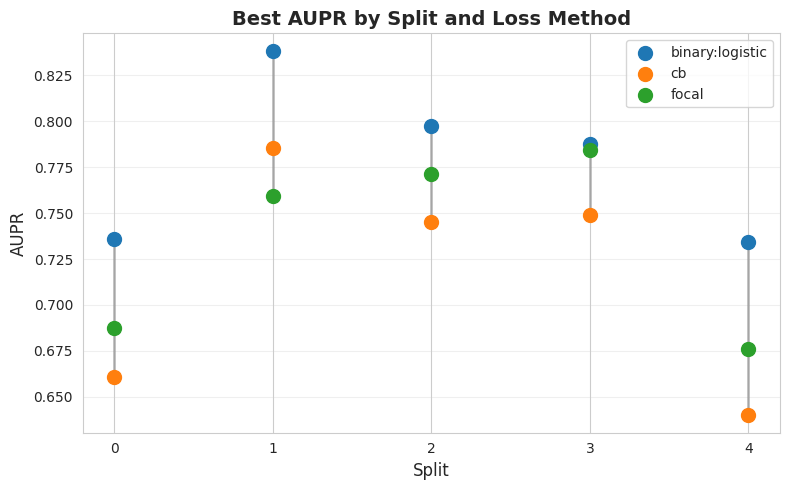

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

pivot_data = best_per_split_loss_summary.pivot(
    index='split',
    columns='loss',
    values='sklearn_ap'
)

loss_methods = pivot_data.columns.tolist()
splits = pivot_data.index.tolist()

fig, ax = plt.subplots(figsize=(8, 5))

colors = {
    'binary:logistic': '#1f77b4',
    'cb': '#ff7f0e',
    'focal': '#2ca02c'
}

x_pos = range(len(splits))

for i, split in enumerate(splits):
    values = pivot_data.loc[split]

    min_val = values.min()
    max_val = values.max()

    ax.plot([i, i], [min_val, max_val],
            color='gray', linewidth=2, alpha=0.5, zorder=1)

    for loss_method in loss_methods:
        ax.scatter(i, values[loss_method],
                  color=colors.get(loss_method, 'black'),
                  s=100, zorder=2, label=loss_method if i == 0 else "")

ax.set_xticks(x_pos)
ax.set_xticklabels(splits, rotation=0)
ax.set_xlabel('Split', fontsize=12)
ax.set_ylabel('AUPR', fontsize=12)
ax.set_title('Best AUPR by Split and Loss Method', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.legend(loc='best')

plt.tight_layout()
plt.show()

In [ ]:
param_performance = df_res.groupby(['loss', 'gamma', 'alpha','with_svmsmote', 'reg_alpha', 'reg_lambda','depth', 'min_ch_weight' ])['sklearn_ap'].mean()
top_10_df = param_performance.sort_values(ascending=False).head(20).reset_index()
top_10_df.columns = ['loss', 'gamma', 'alpha', 'with_svmsmote', 'reg_alpha', 'reg_lambda', 'depth', 'min_ch_weight','mean_sklearn_ap']
top_10_df

,loss,gamma,alpha,with_svmsmote,reg_alpha,reg_lambda,depth,min_ch_weight,mean_sklearn_ap
0,binary:logistic,-1.0,-1.00,False,0.02,1.0,2,6,0.785441
1,binary:logistic,-1.0,-1.00,False,0.06,1.0,2,6,0.784875
2,binary:logistic,-1.0,-1.00,False,0.00,1.0,2,6,0.784033
3,binary:logistic,-1.0,-1.00,False,0.06,0.5,2,6,0.772330
4,binary:logistic,-1.0,-1.00,False,0.02,0.5,2,6,0.766904
5,binary:logistic,-1.0,-1.00,False,0.06,2.0,2,6,0.764527
6,binary:logistic,-1.0,-1.00,False,0.02,2.0,2,6,0.763962
7,binary:logistic,-1.0,-1.00,False,0.00,2.0,2,6,0.759970
8,binary:logistic,-1.0,-1.00,True,0.02,2.0,2,6,0.756849
9,binary:logistic,-1.0,-1.00,True,0.00,2.0,2,6,0.756472


In [ ]:
param_performance = df_res[df_res['loss'] == 'binary:logistic'].groupby(['reg_alpha', 'reg_lambda','with_svmsmote'])['sklearn_ap'].mean()
top_10_df = param_performance.sort_values(ascending=False).head(20).reset_index()
top_10_df.columns = ['reg_alpha', 'reg_lambda','with_svmsmote','mean_sklearn_ap']
top_10_df

,reg_alpha,reg_lambda,with_svmsmote,mean_sklearn_ap
0,0.02,1.0,False,0.697917
1,0.06,0.5,True,0.696024
2,0.00,2.0,True,0.695686
3,0.00,1.0,False,0.695284
4,0.06,1.0,True,0.694682
5,0.02,2.0,True,0.694381
6,0.06,1.0,False,0.692504
7,0.00,0.5,True,0.692119
8,0.02,0.5,True,0.691956
9,0.02,1.0,True,0.691771


In [ ]:
param_performance = df_res[df_res['loss'] == 'binary:logistic'].groupby(['reg_alpha', 'reg_lambda','with_svmsmote'])['sklearn_ap'].median()
top_10_df = param_performance.sort_values(ascending=False).head(20).reset_index()
top_10_df.columns = ['reg_alpha', 'reg_lambda','with_svmsmote','mean_sklearn_ap']
top_10_df

,reg_alpha,reg_lambda,with_svmsmote,mean_sklearn_ap
0,0.06,0.5,True,0.718659
1,0.00,2.0,False,0.715695
2,0.02,0.5,False,0.714570
3,0.02,2.0,False,0.712128
4,0.02,1.0,False,0.709505
5,0.06,2.0,False,0.708936
6,0.06,1.0,False,0.708668
7,0.00,1.0,True,0.707260
8,0.00,0.5,False,0.706691
9,0.02,0.5,True,0.705837


In [ ]:
param_performance = df_res[df_res['loss'] == 'binary:logistic'].groupby(['with_svmsmote' ])['sklearn_ap'].mean()
top_10_df = param_performance.sort_values(ascending=False).head(20).reset_index()
top_10_df.columns = ['with_svmsmote','mean_sklearn_ap']
top_10_df

,with_svmsmote,mean_sklearn_ap
0,True,0.692935
1,False,0.688978


In [ ]:
param_performance = df_res[df_res['loss'] == 'binary:logistic'].groupby(['with_svmsmote' ])['sklearn_ap'].median()
top_10_df = param_performance.sort_values(ascending=False).head(20).reset_index()
top_10_df.columns = ['with_svmsmote','mean_sklearn_ap']
top_10_df

,with_svmsmote,mean_sklearn_ap
0,False,0.708668
1,True,0.701086


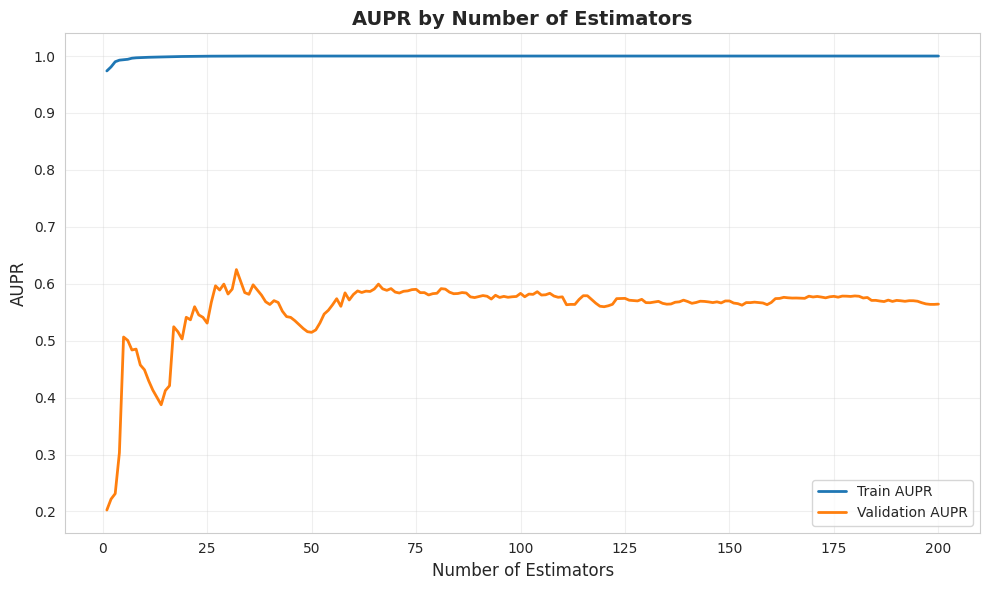

Best AUPR: 0.6249 at iteration 32


In [ ]:
X_train, X_test, y_train, y_test,_ = splits_resampled[4]

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    max_depth = 3,
    min_child_weight = 3,
    learning_rate = 0.12,
    n_estimators = 200,
    eval_metric=aupr_eval_metric,
    enable_categorical=True
)
xgb_model.fit(X_train, y_train,  eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)
results = xgb_model.evals_result()


estimators = range(1, len(results['validation_0']['aupr_eval_metric']) + 1)
train_aupr = results['validation_0']['aupr_eval_metric']
test_aupr = results['validation_1']['aupr_eval_metric']
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(estimators, train_aupr, label='Train AUPR', linewidth=2)
ax.plot(estimators, test_aupr, label='Validation AUPR', linewidth=2)
ax.set_xlabel('Number of Estimators', fontsize=12)
ax.set_ylabel('AUPR', fontsize=12)
ax.set_title('AUPR by Number of Estimators', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_iteration = test_aupr.index(max(test_aupr)) + 1
print(f"Best AUPR: {max(test_aupr):.4f} at iteration {best_iteration}")


#### final

In [ ]:
def split_final():
    metadata  = pd.read_csv('/content/metadata.csv')
    microbiome = pd.read_csv('/content/microbiome.csv')
    serum_lipo = pd.read_csv('/content/serum_lipo.csv')

    metadata['is_sick'] = (metadata['PATGROUPFINAL_C'] != '8').astype(int)
    metadata = metadata.drop(columns=['PATGROUPFINAL_C'])

    taxa_columns = microbiome.drop(columns=['SampleID']).columns
    metabolite_columns = serum_lipo.drop(columns=['SampleID']).columns

    merged = pd.merge(metadata, microbiome, how='inner', on='SampleID')
    merged = pd.merge(merged, serum_lipo, how='inner', on='SampleID')
    merged = merged.drop(columns=['SampleID'])

    X = merged.drop(columns=['is_sick'])
    y = merged['is_sick']

    standard_cols = list(metabolite_columns)
    abundance_cols = list(taxa_columns)

    def relative_abundance(X):
        return X.div(X.sum(axis=1), axis=0)

    def std_nan(X):
        return (X - np.nanmean(X)) / np.nanstd(X)

    preprocessor = ColumnTransformer([
        ('standard', FunctionTransformer(std_nan), standard_cols),
        ('abundance', FunctionTransformer(relative_abundance), abundance_cols)
    ], remainder='passthrough', verbose_feature_names_out=False)
    preprocessor.set_output(transform="pandas")

    # Store training statistics
    m_age = np.nanmean(X['AGE'])
    s_age = np.nanstd(X['AGE'])
    X['AGE'] = (X['AGE'] - m_age) / s_age

    m_DDS = np.nanmean(X['DDS'])
    s_DDS = np.nanstd(X['DDS'])
    X['DDS'] = (X['DDS'] - m_DDS) / s_DDS

    X_transformed = preprocessor.fit_transform(X)

    le = LabelEncoder()
    X_transformed['CENTER_C'] = le.fit_transform(X_transformed['CENTER_C'])

    # Return fitted objects for test data processing
    return X_transformed, y, preprocessor, le, m_age, s_age, m_DDS, s_DDS

In [ ]:
def prepare_test_data(preprocessor, le, m_age, s_age, m_DDS, s_DDS):
    metadata = pd.read_csv('/content/metadata_test.csv')
    microbiome = pd.read_csv('/content/microbiome_test.csv')
    serum_lipo = pd.read_csv('/content/serum_lipo_test.csv')

    # Merge datasets
    merged = pd.merge(metadata, microbiome, how='inner', on='SampleID')
    merged = pd.merge(merged, serum_lipo, how='inner', on='SampleID')

    # Preserve SampleID
    sample_ids = merged['SampleID'].copy()

    # Drop SampleID for processing
    X = merged.drop(columns=['SampleID'])

    # Standardize AGE and DDS using training statistics
    X['AGE'] = (X['AGE'] - m_age) / s_age
    X['DDS'] = (X['DDS'] - m_DDS) / s_DDS

    # Transform using fitted preprocessor
    X_transformed = preprocessor.transform(X)

    # Encode CENTER_C using fitted encoder
    X_transformed['CENTER_C'] = le.transform(X_transformed['CENTER_C'])

    return X_transformed, sample_ids

In [ ]:
X, y, preprocessor, le, m_age, s_age, m_DDS, s_DDS = split_final()
X_test, sample_ids = prepare_test_data(preprocessor, le, m_age, s_age, m_DDS, s_DDS)

np.random.seed(10)
y_copy = y.copy()
X_copy = X.copy()
X_copy['label'] = y_copy
X_copy = X_copy.dropna()
y_copy = X_copy['label']
X_copy.drop(columns=['label'], inplace=True)
n = len(X_copy)

sm = SVMSMOTE(sampling_strategy=0.47)
X_resampled, y_resampled = sm.fit_resample(X_copy, y_copy)

X_add = X_resampled.iloc[n+1:]
y_add = pd.Series(np.zeros(len(X_add), dtype=np.int64))

X_train_svmsmote = pd.concat([X, X_add], ignore_index=True)
y_train_svmsmote = pd.concat([y, y_add], ignore_index=True)

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    max_depth = 3,
    min_child_weight = 3,
    learning_rate = 0.25,
    reg_alpha = 0,
    reg_lambda = 2,
    n_estimators = 38,
    enable_categorical=True
)
xgb_model.fit(X_train_svmsmote, y_train_svmsmote)

probabilities = xgb_model.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    'ID': sample_ids,
    'Probability': probabilities
})

results.to_csv('output.csv')

### focal loss

In [ ]:
def test_focal(X_train, X_test, y_train, y_test, gamma, alpha):
    focal_loss = FocalLoss(gamma=gamma, alpha=alpha)

    xgb_model = xgb.XGBClassifier(
        objective=focal_loss.sk_obj,
        n_estimators = 200,
        eval_metric=f1_class_0_callback,
        enable_categorical=True
    )

    xgb_model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

    results = xgb_model.evals_result()


    estimators = range(1, len(results['validation_0']['f1_class_0_callback']) + 1)
    train_f1 = results['validation_0']['f1_class_0_callback']
    test_f1 = results['validation_1']['f1_class_0_callback']

    best_idx = np.argmax(test_f1)
    best_n_estimators = estimators[best_idx]
    best_score = test_f1[best_idx]

    estimators = range(1, len(results['validation_0']['logloss']) + 1)
    train_logloss = results['validation_0']['logloss']
    test_logloss = results['validation_1']['logloss']

    xgb_model = xgb.XGBClassifier(
    objective=focal_loss.sk_obj,
    n_estimators = best_n_estimators,
    eval_metric=f1_class_0_callback,
    enable_categorical=True
    )

    xgb_model.fit(X_train, y_train)

    y_pred = xgb_model.predict(X_test)
    y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]  # Probabilities for positive class
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    class_report = classification_report(y_test, y_pred, output_dict=True)

    return (class_report['0']['f1-score'], auc_roc, best_n_estimators, best_score)

focal_res = []
for j, split in enumerate(splits):
    print(j)
    X_train, X_test, y_train, y_test,_ = split
    f1, auc_roc, best_n_estimators, best_score = test_focal( X_train, X_test, y_train, y_test, 2, 0.13)
    focal_res.append({
        'split': j,
        'f1': f1,
        'auc_roc': auc_roc,
        'best_n_estimators': best_n_estimators,
        'best_score': best_score
    })

focal_res = pd.DataFrame(focal_res)

0
1
2
3
4


In [ ]:
focal_res_merged = focal_res.merge(est_res, on=['split'], how='left', suffixes=('', '_baseline'))
focal_res_merged['f1_diff'] = focal_res_merged['f1'] - focal_res_merged['f1_baseline']
focal_res_merged['auc_roc_diff'] = focal_res_merged['auc_roc'] - focal_res_merged['auc_roc_baseline']

In [ ]:
focal_res_merged

,split,f1,auc_roc,best_n_estimators,best_score,f1_baseline,auc_roc_baseline,best_n_estimators_baseline,best_score_baseline,f1_diff,auc_roc_diff
0,0,0.677419,0.897361,39,0.677419,0.596491,0.884047,78,0.596491,0.080928,0.013314
1,1,0.655738,0.925079,98,0.655738,0.588235,0.928952,119,0.588235,0.067502,-0.003873
2,2,0.730159,0.946018,158,0.730159,0.566038,0.929194,179,0.566038,0.164121,0.016824
3,3,0.646154,0.888042,31,0.646154,0.528302,0.893609,24,0.528302,0.117852,-0.005568
4,4,0.583333,0.870310,6,0.583333,0.500000,0.872065,111,0.500000,0.083333,-0.001755


In [ ]:
focal_res_merged['auc_roc'].mean()

np.float64(0.905361897845558)

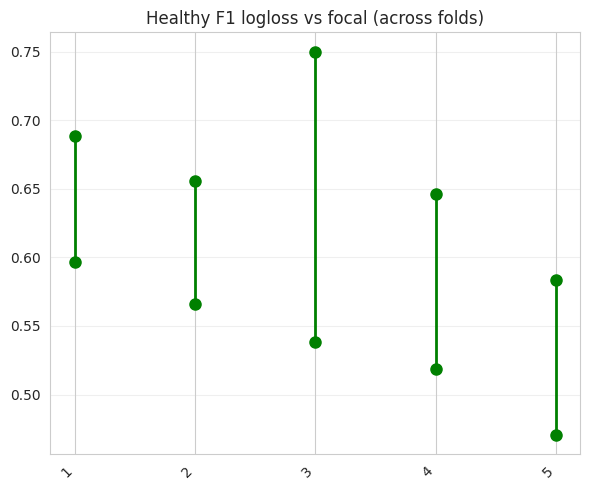

In [ ]:
# Set seaborn style
sns.set_style("whitegrid")

# Sample data
samples = ['1', '2', '3', '4', '5']
value1 = focal_res_merged['f1_baseline']
value2 = focal_res_merged['f1']

fig, ax = plt.subplots(figsize=(6, 5))

x_pos = range(len(samples))

# Draw connecting lines vertically
for i, sample in enumerate(samples):
    color = 'green' if value2[i] > value1[i] else 'red'
    ax.plot([i, i], [value1[i], value2[i]], 'o-',
            color=color, linewidth=2, markersize=8)

# Customize
ax.set_xticks(x_pos)
ax.set_xticklabels(samples, rotation=45, ha='right')
ax.set_title('Healthy F1 logloss vs focal (across folds)')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

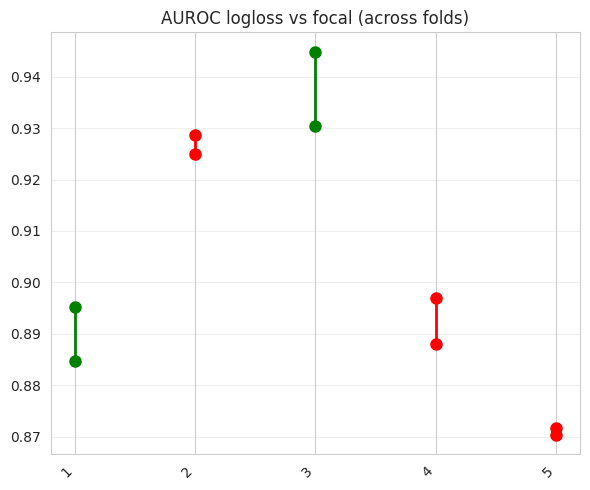

In [ ]:
# Set seaborn style
sns.set_style("whitegrid")

# Sample data
samples = ['1', '2', '3', '4', '5']
value1 = focal_res_merged['auc_roc_baseline']
value2 = focal_res_merged['auc_roc']

fig, ax = plt.subplots(figsize=(6, 5))

x_pos = range(len(samples))

# Draw connecting lines vertically
for i, sample in enumerate(samples):
    color = 'green' if value2[i] > value1[i] else 'red'
    ax.plot([i, i], [value1[i], value2[i]], 'o-',
            color=color, linewidth=2, markersize=8)

# Customize
ax.set_xticks(x_pos)
ax.set_xticklabels(samples, rotation=45, ha='right')
ax.set_title('AUROC logloss vs focal (across folds)')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:


def test_focal(X_train, X_test, y_train, y_test, gamma, alpha):
    focal_loss = FocalLoss(gamma=gamma, alpha=alpha)

    xgb_model = xgb.XGBClassifier(
        objective=focal_loss.sk_obj,
        eval_metric='logloss',
        enable_categorical=True
    )

    xgb_model.fit(X_train, y_train)

    y_pred = xgb_model.predict(X_test)
    y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]  # Probabilities for positive class

    # Calculate metrics
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    #f1 = f1_score(y_test, y_pred)
    class_report = classification_report(y_test, y_pred, output_dict=True)

    #return (class_report['0']['f1-score'], class_report['1']['f1-score'], auc_roc, f1)
    return (class_report['0']['f1-score'], auc_roc)

focal_res = []
for j, split in enumerate(splits):
    print(j)
    X_train, X_test, y_train, y_test,_ = split
    for gamma in [1, 1.5, 2, 2.5, 3, 3.5]:
        f1, auc_roc = test_focal( X_train, X_test, y_train, y_test, gamma=gamma, alpha=0.13)
        focal_res.append({
            'split': j,
            'gamma': gamma,
            'f1': f1,
            'auc_roc': auc_roc
        })

focal_res = pd.DataFrame(focal_res)

0
1
2
3
4


In [ ]:
focal_res_merged = focal_res.merge(baseline_res, on=['split'], how='left', suffixes=('', '_baseline'))
focal_res_merged.drop(columns=['depth'], inplace=True)
focal_res_merged['f1_diff'] = focal_res_merged['f1'] - focal_res_merged['f1_baseline']
focal_res_merged['auc_roc_diff'] = focal_res_merged['auc_roc'] - focal_res_merged['auc_roc_baseline']
focal_res_grouped = focal_res_merged.groupby('gamma').mean()
focal_res_grouped

,split,f1,auc_roc,f1_baseline,auc_roc_baseline,f1_diff,auc_roc_diff
gamma,,,,,,,
1.0,2.0,0.605561,0.910579,0.538019,0.902457,0.067542,0.008122
1.5,2.0,0.623028,0.906076,0.538019,0.902457,0.085009,0.003619
2.0,2.0,0.641296,0.907141,0.538019,0.902457,0.103276,0.004684
2.5,2.0,0.593170,0.904890,0.538019,0.902457,0.055150,0.002433
3.0,2.0,0.601118,0.906052,0.538019,0.902457,0.063098,0.003595
3.5,2.0,0.630940,0.902469,0.538019,0.902457,0.092920,0.000012


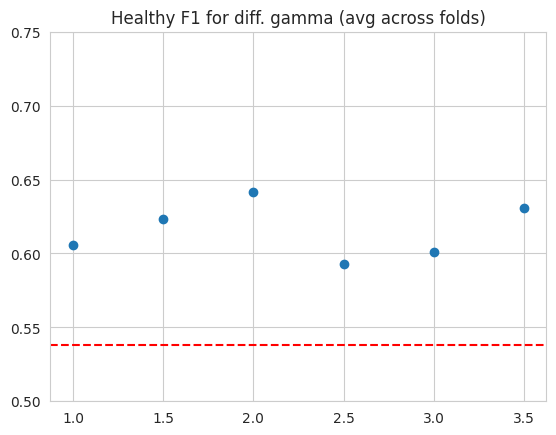

In [ ]:
plt.figure()
plt.scatter([1, 1.5, 2, 2.5, 3, 3.5], focal_res_grouped['f1'])
plt.xticks([1, 1.5, 2, 2.5, 3, 3.5])
plt.ylim(0.5, 0.75)
plt.axhline(y=0.538, color='red', linestyle='--', label='baseline')

plt.title('Healthy F1 for diff. gamma (avg across folds)')
plt.show()

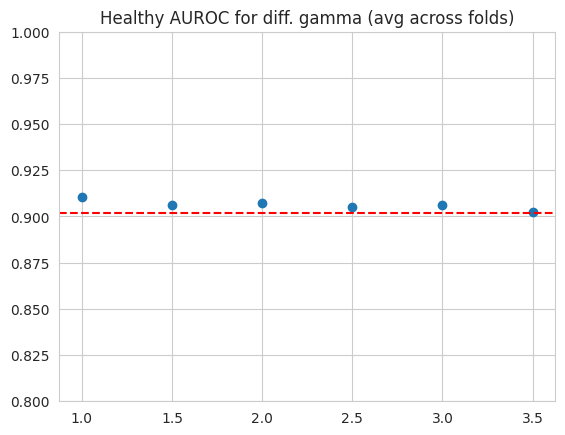

In [ ]:
plt.figure()
plt.scatter([1, 1.5, 2, 2.5, 3, 3.5], focal_res_grouped['auc_roc'])
plt.xticks([1, 1.5, 2, 2.5, 3, 3.5])
plt.ylim(0.8, 1)
plt.axhline(y=0.902, color='red', linestyle='--', label='baseline')

plt.title('Healthy AUROC for diff. gamma (avg across folds)')
plt.show()

### CB

In [ ]:
beta = (len(X_train) -1 ) / len(X_train)

en_neg =  (1-beta) / (1-beta**len(y_train[y_train==0]))
en_pos =  (1-beta) / (1-beta**len(y_train[y_train==1]))

In [ ]:
inst = CBLoss(en_pos*100, en_neg*100)


def test_CB(X_train, X_test, y_train, y_test,):

    xgb_model = xgb.XGBClassifier(
        objective=inst.cb_obj,
        n_estimators = 200,
        eval_metric=f1_class_0_callback,
        enable_categorical=True
        )
    xgb_model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

    results = xgb_model.evals_result()


    estimators = range(1, len(results['validation_0']['f1_class_0_callback']) + 1)
    train_f1 = results['validation_0']['f1_class_0_callback']
    test_f1 = results['validation_1']['f1_class_0_callback']

    best_idx = np.argmax(test_f1)
    best_n_estimators = estimators[best_idx]
    best_score = test_f1[best_idx]

    estimators = range(1, len(results['validation_0']['logloss']) + 1)
    train_logloss = results['validation_0']['logloss']
    test_logloss = results['validation_1']['logloss']

    xgb_model = xgb.XGBClassifier(
    objective=inst.cb_obj,
    n_estimators = best_n_estimators,
    eval_metric=f1_class_0_callback,
    enable_categorical=True
    )
    xgb_model.fit(X_train, y_train)

    y_pred = xgb_model.predict(X_test)
    y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]  # Probabilities for positive class
    # Calculate metrics
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    #f1 = f1_score(y_test, y_pred)
    class_report = classification_report(y_test, y_pred, output_dict=True)

    #return (class_report['0']['f1-score'], class_report['1']['f1-score'], auc_roc, f1)
    return (class_report['0']['f1-score'], auc_roc, best_n_estimators, best_score)

cb_res = []
for j, split in enumerate(splits):
    print(j)
    X_train, X_test, y_train, y_test,_ = split
    f1, auc_roc , best_n_estimators, best_score = test_CB( X_train, X_test, y_train, y_test)
    cb_res.append({
        'split': j,
        'f1': f1,
        'auc_roc': auc_roc,
        'best_n_estimators': best_n_estimators,
        'best_score': best_score
    })

cb_res = pd.DataFrame(cb_res)

0
1
2
3
4


In [ ]:
cb_res

,split,f1,auc_roc,best_n_estimators,best_score
0,0,0.656250,0.877754,29,0.656250
1,1,0.711864,0.923626,238,0.711864
2,2,0.716418,0.935488,278,0.716418
3,3,0.645161,0.884774,123,0.645161
4,4,0.586667,0.869886,5,0.586667


In [ ]:
cbl_res_merged = cb_res.merge(est_res, on=['split'], how='left', suffixes=('', '_baseline'))
cbl_res_merged['f1_diff'] = cbl_res_merged['f1'] - cbl_res_merged['f1_baseline']
cbl_res_merged['auc_roc_diff'] = cbl_res_merged['auc_roc'] - cbl_res_merged['auc_roc_baseline']


In [ ]:
cbl_res_merged

,split,f1,auc_roc,best_n_estimators,best_score,f1_baseline,auc_roc_baseline,best_n_estimators_baseline,best_score_baseline,f1_diff,auc_roc_diff
0,0,0.656250,0.877754,29,0.656250,0.596491,0.884047,78,0.596491,0.059759,-0.006294
1,1,0.677966,0.922053,173,0.677966,0.588235,0.928952,119,0.588235,0.089731,-0.006899
2,2,0.696970,0.932946,72,0.696970,0.566038,0.929194,179,0.566038,0.130932,0.003752
3,3,0.645161,0.884774,123,0.645161,0.528302,0.893609,24,0.528302,0.116859,-0.008836
4,4,0.586667,0.869886,5,0.586667,0.500000,0.872065,111,0.500000,0.086667,-0.002179


In [ ]:
cbl_res_merged['f1'].mean()

np.float64(0.6526027511307719)

In [ ]:
cbl_res_merged = cb_res.merge(baseline_res, on=['split'], how='left', suffixes=('', '_baseline'))
cbl_res_merged['f1_diff'] = cbl_res_merged['f1'] - cbl_res_merged['f1_baseline']
cbl_res_merged['auc_roc_diff'] = cbl_res_merged['auc_roc'] - cbl_res_merged['auc_roc_baseline']


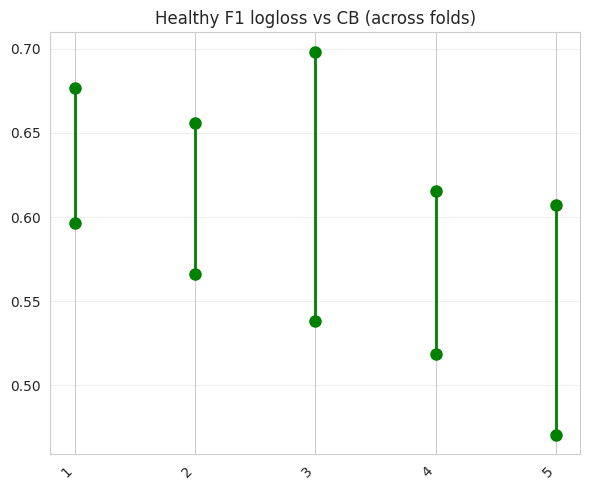

In [ ]:
# Set seaborn style
sns.set_style("whitegrid")

# Sample data
samples = ['1', '2', '3', '4', '5']
value1 = cbl_res_merged['f1_baseline']
value2 = cbl_res_merged['f1']

fig, ax = plt.subplots(figsize=(6, 5))

x_pos = range(len(samples))

# Draw connecting lines vertically
for i, sample in enumerate(samples):
    color = 'green' if value2[i] > value1[i] else 'red'
    ax.plot([i, i], [value1[i], value2[i]], 'o-',
            color=color, linewidth=2, markersize=8)

# Customize
ax.set_xticks(x_pos)
ax.set_xticklabels(samples, rotation=45, ha='right')
ax.set_title('Healthy F1 logloss vs CB (across folds)')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
print(cbl_res_merged['f1'].mean())
print(cbl_res_merged['f1_diff'].mean())

0.6507201905562562
0.11270073931757481


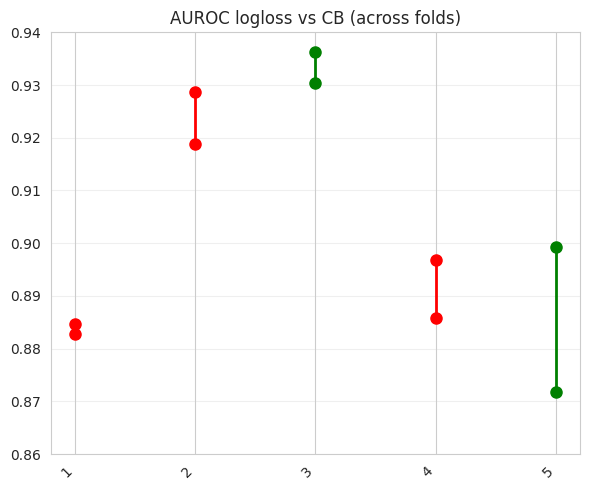

In [ ]:
# Set seaborn style
sns.set_style("whitegrid")

# Sample data
samples = ['1', '2', '3', '4', '5']
value1 = cbl_res_merged['auc_roc_baseline']
value2 = cbl_res_merged['auc_roc']

fig, ax = plt.subplots(figsize=(6, 5))
ax.set_ylim(0.86, 0.94)

x_pos = range(len(samples))

# Draw connecting lines vertically
for i, sample in enumerate(samples):
    color = 'green' if value2[i] > value1[i] else 'red'
    ax.plot([i, i], [value1[i], value2[i]], 'o-',
            color=color, linewidth=2, markersize=8)

# Customize
ax.set_xticks(x_pos)
ax.set_xticklabels(samples, rotation=45, ha='right')
ax.set_title('AUROC logloss vs CB (across folds)')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
print(cbl_res_merged['auc_roc'].mean())
print(cbl_res_merged['auc_roc_diff'].mean())

0.9046235778261922
0.002166545630597905


### regs

In [ ]:
def test_l1(X_train, X_test, y_train, y_test, l1):

    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',
        n_estimators = 200,
        eval_metric=f1_class_0_callback,
        reg_alpha = l1,
        enable_categorical=True
        )
    xgb_model.fit(X_train, y_train,  eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

    results = xgb_model.evals_result()


    estimators = range(1, len(results['validation_0']['f1_class_0_callback']) + 1)
    train_f1 = results['validation_0']['f1_class_0_callback']
    test_f1 = results['validation_1']['f1_class_0_callback']

    best_idx = np.argmax(test_f1)
    best_n_estimators = estimators[best_idx]
    best_score = test_f1[best_idx]

    estimators = range(1, len(results['validation_0']['logloss']) + 1)
    train_logloss = results['validation_0']['logloss']
    test_logloss = results['validation_1']['logloss']

    xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators = best_n_estimators,
    eval_metric=f1_class_0_callback,
    reg_alpha = l1,
    enable_categorical=True
    )
    xgb_model.fit(X_train, y_train)

    y_pred = xgb_model.predict(X_test)
    y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]  # Probabilities for positive class
    # Calculate metrics
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    #f1 = f1_score(y_test, y_pred)
    class_report = classification_report(y_test, y_pred, output_dict=True)

    #return (class_report['0']['f1-score'], class_report['1']['f1-score'], auc_roc, f1)
    return (class_report['0']['f1-score'], auc_roc, best_n_estimators, best_score)

l1_res = []
for j, split in enumerate(splits):
    print(j)
    X_train, X_test, y_train, y_test,_ = split
    for l1 in [0.001, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]:
        f1, auc_roc , best_n_estimators, best_score = test_l1( X_train, X_test, y_train, y_test, l1)
        l1_res.append({
            'split': j,
            'l1': l1,
            'f1': f1,
            'auc_roc': auc_roc,
            'best_n_estimators': best_n_estimators,
            'best_score': best_score
        })

l1_res = pd.DataFrame(l1_res)

0
1
2
3
4


In [ ]:
import pickle
'''
with open('/content/drive/MyDrive/l1_res.pickle', 'wb') as file:
    pickle.dump(l1_res, file)
'''
with open('/content/drive/MyDrive/l1_res.pickle', 'rb') as file:
    l1_res = pickle.load(file)

In [ ]:
l1_res_merged = l1_res.merge(est_res, on=['split'], how='left', suffixes=('', '_baseline'))
l1_res_merged['f1_diff'] = l1_res_merged['f1'] - l1_res_merged['f1_baseline']
l1_res_merged['auc_roc_diff'] = l1_res_merged['auc_roc'] - l1_res_merged['auc_roc_baseline']
l1_res_grouped = l1_res_merged.groupby('l1').mean()
l1_res_grouped

,split,f1,auc_roc,best_n_estimators,best_score,f1_baseline,auc_roc_baseline,best_n_estimators_baseline,best_score_baseline,f1_diff,auc_roc_diff
l1,,,,,,,,,,,
0.001,2.0,0.537762,0.896466,93.0,0.537762,0.555813,0.901573,102.2,0.555813,-0.018051,-0.005108
0.010,2.0,0.553633,0.885960,90.8,0.553633,0.555813,0.901573,102.2,0.555813,-0.002180,-0.015614
0.020,2.0,0.567487,0.895643,79.0,0.567488,0.555813,0.901573,102.2,0.555813,0.011674,-0.005931
0.030,2.0,0.542193,0.894336,53.0,0.542193,0.555813,0.901573,102.2,0.555813,-0.013620,-0.007238
0.040,2.0,0.539307,0.881941,35.6,0.539307,0.555813,0.901573,102.2,0.555813,-0.016506,-0.019632
0.050,2.0,0.575487,0.906730,145.2,0.575487,0.555813,0.901573,102.2,0.555813,0.019673,0.005156
0.060,2.0,0.587581,0.901695,142.6,0.587582,0.555813,0.901573,102.2,0.555813,0.031768,0.000121
0.070,2.0,0.562222,0.900581,84.2,0.562222,0.555813,0.901573,102.2,0.555813,0.006409,-0.000992
0.080,2.0,0.571617,0.903462,76.6,0.571617,0.555813,0.901573,102.2,0.555813,0.015804,0.001888


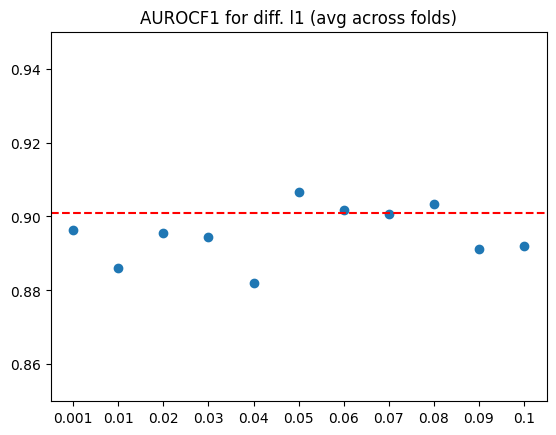

In [ ]:
l1_values =  [0.001, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]
x_positions = range(len(l1_values))


plt.figure()
plt.scatter(x_positions, l1_res_grouped['auc_roc'])
plt.xticks(x_positions, l1_values)
plt.ylim(0.85, 0.95)
plt.axhline(y=0.901, color='red', linestyle='--', label='baseline')

plt.title('AUROCF1 for diff. l1 (avg across folds)')
plt.show()

In [ ]:
def test_l2(X_train, X_test, y_train, y_test, l2):

    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',
        n_estimators = 200,
        eval_metric=f1_class_0_callback,
        reg_lambda = l2,
        enable_categorical=True
        )
    xgb_model.fit(X_train, y_train,  eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

    results = xgb_model.evals_result()


    estimators = range(1, len(results['validation_0']['f1_class_0_callback']) + 1)
    train_f1 = results['validation_0']['f1_class_0_callback']
    test_f1 = results['validation_1']['f1_class_0_callback']

    best_idx = np.argmax(test_f1)
    best_n_estimators = estimators[best_idx]
    best_score = test_f1[best_idx]

    estimators = range(1, len(results['validation_0']['logloss']) + 1)
    train_logloss = results['validation_0']['logloss']
    test_logloss = results['validation_1']['logloss']

    xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators = best_n_estimators,
    eval_metric=f1_class_0_callback,
    reg_lambda = l2,
    enable_categorical=True
    )
    xgb_model.fit(X_train, y_train)

    y_pred = xgb_model.predict(X_test)
    y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]  # Probabilities for positive class
    # Calculate metrics
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    #f1 = f1_score(y_test, y_pred)
    class_report = classification_report(y_test, y_pred, output_dict=True)

    return (class_report['0']['f1-score'], auc_roc, best_n_estimators, best_score)

l2_res = []
for j, split in enumerate(splits):
    print(j)
    X_train, X_test, y_train, y_test,_ = split
    for l2 in [0.1, 0.5, 1, 2, 3, 5, 7.5, 10]:
        f1, auc_roc , best_n_estimators, best_score = test_l2( X_train, X_test, y_train, y_test, l2)
        l2_res.append({
            'split': j,
            'l2': l2,
            'f1': f1,
            'auc_roc': auc_roc,
            'best_n_estimators': best_n_estimators,
            'best_score': best_score
        })

l2_res = pd.DataFrame(l2_res)

0
1
2
3
4


In [ ]:
with open('/content/drive/MyDrive/l2_res.pickle', 'rb') as file:
    l2_res = pickle.load(file)

In [ ]:
l2_res_merged = l2_res.merge(est_res, on=['split'], how='left', suffixes=('', '_baseline'))
l2_res_merged['f1_diff'] = l2_res_merged['f1'] - l2_res_merged['f1_baseline']
l2_res_merged['auc_roc_diff'] = l2_res_merged['auc_roc'] - l2_res_merged['auc_roc_baseline']
l2_res_grouped = l2_res_merged.groupby('l2').mean()
l2_res_grouped

,split,f1,auc_roc,best_n_estimators,best_score,f1_baseline,auc_roc_baseline,best_n_estimators_baseline,best_score_baseline,f1_diff,auc_roc_diff
l2,,,,,,,,,,,
0.1,2.0,0.559817,0.897313,57.6,0.559817,0.555813,0.901573,102.2,0.555813,0.004004,-0.004260
0.5,2.0,0.579596,0.894541,59.0,0.579596,0.555813,0.901573,102.2,0.555813,0.023783,-0.007032
1.0,2.0,0.555813,0.901573,102.2,0.555813,0.555813,0.901573,102.2,0.555813,0.000000,0.000000
2.0,2.0,0.573271,0.910361,102.8,0.573271,0.555813,0.901573,102.2,0.555813,0.017458,0.008787
3.0,2.0,0.562226,0.900436,106.8,0.562226,0.555813,0.901573,102.2,0.555813,0.006412,-0.001138
5.0,2.0,0.555686,0.900605,78.6,0.555686,0.555813,0.901573,102.2,0.555813,-0.000127,-0.000968
7.5,2.0,0.557123,0.900315,65.4,0.557123,0.555813,0.901573,102.2,0.555813,0.001310,-0.001259
10.0,2.0,0.572658,0.907286,98.0,0.572658,0.555813,0.901573,102.2,0.555813,0.016845,0.005713


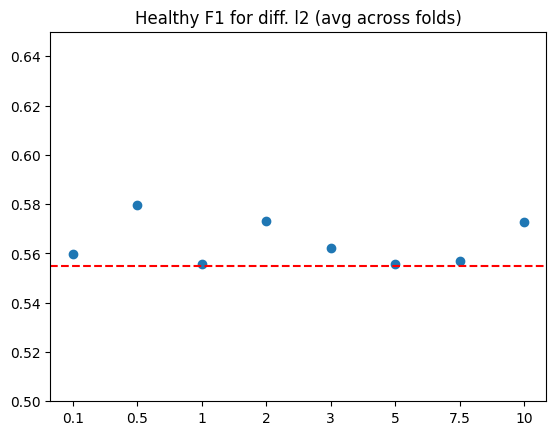

In [ ]:
l2_values = [0.1, 0.5, 1, 2, 3, 5, 7.5, 10]
x_positions = range(len(l2_values))


plt.figure()
plt.scatter(x_positions, l2_res_grouped['f1'])
plt.xticks(x_positions, l2_values)
plt.ylim(0.5, 0.65)
plt.axhline(y=0.555, color='red', linestyle='--', label='baseline')

plt.title('Healthy F1 for diff. l2 (avg across folds)')
plt.show()

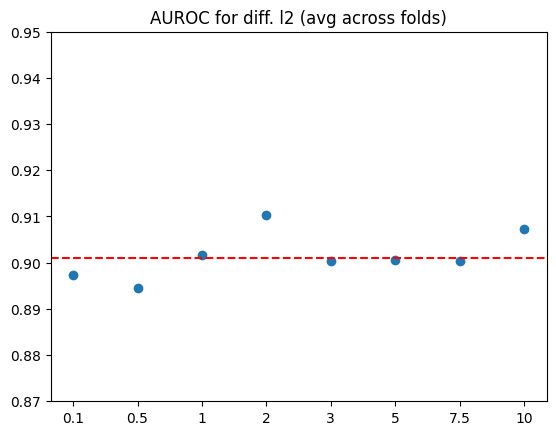

In [ ]:
l2_values = [0.1, 0.5, 1, 2, 3, 5, 7.5, 10]
x_positions = range(len(l2_values))


plt.figure()
plt.scatter(x_positions, l2_res_grouped['auc_roc'])
plt.xticks(x_positions, l2_values)
plt.ylim(0.87, 0.95)
plt.axhline(y=0.901, color='red', linestyle='--', label='baseline')

plt.title('AUROC for diff. l2 (avg across folds)')
plt.show()

### AGP

In [ ]:
bac120_taxonomy_r202 = pd.read_csv('/content/bac120_taxonomy_r202.tsv', sep='\t', header=None, names=['genome_id', 'taxonomy'])
agp_micro = pd.read_csv('/content/feature_table_gtdb_2.tsv', sep='\t')
agp_meta = pd.read_csv('/content/AGP-metadata.tsv', sep='\t', encoding='latin-1')

/tmp/ipython-input-2300834376.py:4: DtypeWarning: Columns (0,10,11,12,13,14,15,16,17,18,19,20,21,24,68,91,98,129,130,131,132,133,134,140,178,179,180,181,182,183) have mixed types. Specify dtype option on import or set low_memory=False.
  agp_meta = pd.read_csv('/content/AGP-metadata.tsv', sep='\t', encoding='latin-1')


In [ ]:
taxonomy_split = bac120_taxonomy_r202['taxonomy'].str.split(';', expand=True)
taxonomy_split.columns = ['domain', 'phylum', 'class', 'order',
                          'family', 'genus', 'species']

for col in taxonomy_split.columns:
    taxonomy_split[col] = taxonomy_split[col].str.replace(r'^[a-z]__', '', regex=True)

taxonomy = pd.concat([bac120_taxonomy_r202['genome_id'], taxonomy_split], axis=1)

In [ ]:
taxonomy

,genome_id,domain,phylum,class,order,family,genus,species
0,RS_GCF_014075335.1,Bacteria,Proteobacteria,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Escherichia,Escherichia flexneri
1,RS_GCF_002310555.1,Bacteria,Proteobacteria,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Escherichia,Escherichia flexneri
2,RS_GCF_900013275.1,Bacteria,Proteobacteria,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Escherichia,Escherichia flexneri
3,RS_GCF_000168095.1,Bacteria,Proteobacteria,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Escherichia,Escherichia flexneri
4,RS_GCF_002459845.1,Bacteria,Proteobacteria,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Escherichia,Escherichia flexneri
...,...,...,...,...,...,...,...,...
254085,RS_GCF_004361695.1,Bacteria,Actinobacteriota,Actinomycetia,Actinomycetales,Microbacteriaceae,Curtobacterium,Curtobacterium flaccumfaciens_B
254086,GB_GCA_002315235.1,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Ruminococcaceae,HUN007,HUN007 sp002315235
254087,GB_GCA_000522425.1,Bacteria,Tectomicrobia,Entotheonellia,Entotheonellales,Entotheonellaceae,Entotheonella,Entotheonella factor
254088,GB_GCA_009780065.1,Bacteria,Firmicutes_A,Clostridia_A,Christensenellales,UBA1242,WRAD01,WRAD01 sp009780065


In [ ]:
import json


m = pd.read_csv('/content/microbiome.csv')
m_cols = m.columns.tolist()

converted = {}
unconverted = []
multiple = {}

for i, col in enumerate(m_cols):
    if i % 100 == 0:
        print(f"{i} out of {len(m_cols)}")

    matches = taxonomy[taxonomy['species'].str.contains(col, case=False, na=False)]
    if len(matches) == 0:
        st = col.split(' ')[0]
        matches = taxonomy[taxonomy['species'].str.contains(st, case=False, na=False)]
        if len(matches) == 0:
            unconverted.append(col)
            continue
    if len(matches) == 1:
        converted[col] = matches['genus'].values[0]
    else:
        s = set()
        for _, row in matches.iterrows():
            s.add(row['genus'])
        if len(s) == 1:
            converted[col] = s.pop()
        else:
            multiple[col] = s

print(f'len converted: {len(converted)}')
print(f'len unconverted: {len(unconverted)}')
print(f'len multiple: {len(multiple)}')


'''
with open('taxon_conversion.json', 'w') as f:
    json.dump(converted, f)
'''

0 out of 665
100 out of 665
200 out of 665
300 out of 665
400 out of 665
500 out of 665
600 out of 665
len converted: 565
len unconverted: 80
len multiple: 20


"\nwith open('taxon_conversion.json', 'w') as f:\n    json.dump(converted, f)\n"

In [ ]:
with open("/content/converted_0310.pkl", 'rb') as file:
    converted = pickle.load(file)

m = pd.read_csv('/content/microbiome.csv')


In [ ]:
m = m.set_index('SampleID').div(m.set_index('SampleID').sum(axis=1), axis=0)

species_in_converted = [col for col in m.columns if col in converted.keys()]

covered_abundance = m[species_in_converted].sum(axis=1)

species_columns = [col for col in m.columns if col != 'SampleID']
total_abundance = m[species_columns].sum(axis=1)

percentage_covered = (covered_abundance / total_abundance) * 100



In [ ]:
print(f"\nRelative abundance coverage:")
print(f"Mean: {percentage_covered.mean():.2f}%")
print(f"Median: {percentage_covered.median():.2f}%")


Relative abundance coverage:
Mean: 92.07%
Median: 92.97%


In [ ]:
micro = m.rename(columns=converted)

In [ ]:
agp_micro = pd.read_csv('/content/feature_table_gtdb_2.tsv', sep='\t')

def extract_genus(taxonomy_string):
    parts = taxonomy_string.split(';')
    for part in parts:
        if part.startswith('g__'):
            return part.replace('g__', '')
    return None

agp_micro.iloc[:, 0] = agp_micro.iloc[:, 0].apply(extract_genus)

agp_genus_list = agp_micro.iloc[:, 0].tolist()

agp_transposed = agp_micro.T

agp_transposed.columns = agp_transposed.iloc[0]
agp_transposed = agp_transposed.drop(agp_transposed.index[0])


agp_transposed.reset_index(inplace=True)
agp_transposed.rename(columns={'index': 'sample_name'}, inplace=True)


In [ ]:
intersection = set(agp_genus_list).intersection(set(converted.values()))
len(intersection)

141

In [ ]:
micro_filtered = micro[['SampleID']+list(intersection)].set_index('SampleID').groupby(level=0, axis=1).mean().reset_index()

/tmp/ipython-input-3913316876.py:1: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  micro_filtered = micro[['SampleID']+list(intersection)].set_index('SampleID').groupby(level=0, axis=1).mean().reset_index()


In [ ]:
agp_filtered = agp_transposed[['sample_name']+list(intersection)]

In [ ]:
meta = pd.read_csv('/content/metadata.csv')
meta['is_sick'] = (meta['PATGROUPFINAL_C'] != '8').astype(int)


In [ ]:
micro_filtered = micro_filtered.merge(meta[['SampleID', 'is_sick']], on='SampleID', how='left')

In [ ]:
agp_meta = pd.read_csv('/content/AGP-metadata.tsv', sep='\t', encoding='latin-1')

healthy_condition = (
    (agp_meta['ibd'] == 'I do not have this condition') &
    (agp_meta['ibs'] == 'I do not have this condition') &
    (agp_meta['diabetes'] == 'I do not have this condition') &
    (agp_meta['cardiovascular_disease'] == 'I do not have this condition') &
    (agp_meta['sibo'] == 'I do not have this condition')
)

agp_meta['is_sick'] = (~healthy_condition).astype(int)

/tmp/ipython-input-3279762054.py:1: DtypeWarning: Columns (0,10,11,12,13,14,15,16,17,18,19,20,21,24,68,91,98,129,130,131,132,133,134,140,178,179,180,181,182,183) have mixed types. Specify dtype option on import or set low_memory=False.
  agp_meta = pd.read_csv('/content/AGP-metadata.tsv', sep='\t', encoding='latin-1')


In [ ]:
agp_filtered = agp_filtered.merge(agp_meta[['sample_name', 'is_sick']], on='sample_name', how='inner')

In [ ]:
from sklearn.metrics import pairwise_distances
from sklearn.manifold import MDS
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform

micro_filtered_labeled = micro_filtered.copy()
micro_filtered_labeled['dataset'] = 'metacardis'

agp_filtered_labeled = agp_filtered.copy()
agp_filtered_labeled['dataset'] = 'agp'

combined_data = pd.concat([micro_filtered_labeled, agp_filtered_labeled], axis=0, ignore_index=True)

combined_data['group'] = combined_data['dataset'] + '_' + combined_data['is_sick'].map({0: 'healthy', 1: 'sick'})
combined_data = combined_data.drop(['SampleID', 'sample_name'], axis=1, errors='ignore')

metadata = combined_data[['dataset', 'is_sick', 'group']]
features = combined_data.drop(['dataset', 'is_sick', 'group'], axis=1)
features = features.fillna(0)

features = features.div(features.sum(axis=1), axis=0)

distances = pdist(features.values, metric='braycurtis')
distance_matrix = squareform(distances)

print("finished computing distances")
with open('distances.pkl', 'wb') as file:
    pickle.dump(distances, file)

pcoa = MDS(n_components=2, dissimilarity='precomputed')
pcoa_coords = pcoa.fit_transform(distance_matrix)

pcoa_df = pd.DataFrame({
    'PCoA1': pcoa_coords[:, 0],
    'PCoA2': pcoa_coords[:, 1],
    'group': metadata['group'].values  # Use 'group' from metadata, not 'Dataset'
})



In [ ]:

with open('distance_matrix.pkl', 'wb') as file:
    pickle.dump(distance_matrix, file)

with open('pcoa.pkl', 'wb') as file:
    pickle.dump(pcoa, file)



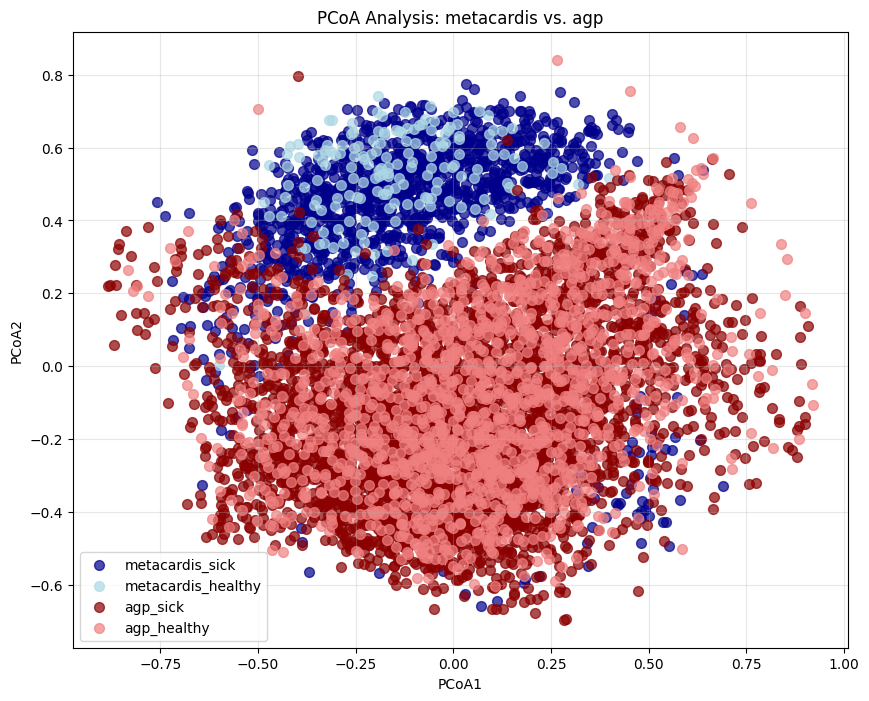

Stress (lower is better): 938121.7958881122


In [ ]:
plt.figure(figsize=(10, 8))
colors = {'metacardis_healthy': 'lightblue',
          'metacardis_sick': 'darkblue',
          'agp_healthy': 'lightcoral',
          'agp_sick': 'darkred'}


for group in pcoa_df['group'].unique():
    subset = pcoa_df[pcoa_df['group'] == group]
    plt.scatter(subset['PCoA1'], subset['PCoA2'],
               c=colors[group], label=group, alpha=0.7, s=50)

plt.xlabel('PCoA1')
plt.ylabel('PCoA2')
plt.title('PCoA Analysis: metacardis vs. agp')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Stress (lower is better): {pcoa.stress_}")

In [ ]:
with open('/content/agp_filtered_0310.pkl', 'rb') as file:
    agp_filtered = pickle.load(file)

with open('/content/micro_filtered_0310.pkl', 'rb') as file:
    micro_filtered = pickle.load(file)

In [ ]:
agp_filtered = agp_filtered.set_index('sample_name').div(agp_filtered.set_index('sample_name').sum(axis=1), axis=0)
species_in_converted = [col for col in agp_filtered.columns if col in converted.values()]

covered_abundance = agp_filtered[species_in_converted].sum(axis=1)

species_columns = [col for col in agp_filtered.columns if col != 'sample_name']
total_abundance = agp_filtered[species_columns].sum(axis=1)

percentage_covered = (covered_abundance / total_abundance) * 100


In [ ]:
print(f"\nRelative abundance coverage:")
print(f"Mean: {percentage_covered.mean():.2f}%")
print(f"Median: {percentage_covered.median():.2f}%")


Relative abundance coverage:
Mean: 99.98%
Median: 99.99%


In [ ]:
import skbio
from skbio import DistanceMatrix
from skbio.stats.distance import permanova
import numpy as np

sample_ids = [f"sample_{i}" for i in range(len(distance_matrix))]
dm = DistanceMatrix(distance_matrix, ids=sample_ids)

groups_array = metadata['group'].values

permanova_results = permanova(dm, groups_array, permutations=9999)

print("PERMANOVA Results (4 groups: metacardis_healthy, metacardis_sick, agp_healthy, agp_sick):")
print("=" * 70)
print(f"Test statistic (pseudo-F): {permanova_results['test statistic']:.6f}")
print(f"p-value: {permanova_results['p-value']:.6f}")
print(f"Number of groups: {permanova_results['number of groups']}")
print(f"Number of permutations: {permanova_results['number of permutations']}")

if permanova_results['p-value'] < 0.05:
    print(f"\nSIGNIFICANT: The groups have significantly different microbiome compositions (p < 0.05)")
else:
    print(f"\nNOT SIGNIFICANT: The groups do not have significantly different microbiome compositions (p ≥ 0.05)")

def calculate_effect_size(distance_matrix, groups):
    n_samples = len(groups)
    total_ss = np.sum(distance_matrix**2) / (2 * n_samples)

    within_ss = 0
    unique_groups = np.unique(groups)

    for group in unique_groups:
        group_indices = np.where(groups == group)[0]
        if len(group_indices) > 1:
            group_distances = distance_matrix[np.ix_(group_indices, group_indices)]
            within_ss += np.sum(group_distances**2) / (2 * len(group_indices))

    between_ss = total_ss - within_ss
    r_squared = between_ss / total_ss

    return r_squared

r_squared = calculate_effect_size(distance_matrix, groups_array)

print(f"\nEffect Size:")
print(f"R-squared: {r_squared:.4f}")
print(f"Percentage of variance explained: {r_squared * 100:.2f}%")

print("\n" + "="*70)
print("PERMANOVA by Dataset Only (metacardis vs agp):")
print("="*70)

dataset_array = metadata['dataset'].values
permanova_dataset = permanova(dm, dataset_array, permutations=9999)

print(f"Test statistic: {permanova_dataset['test statistic']:.6f}")
print(f"p-value: {permanova_dataset['p-value']:.6f}")

r_squared_dataset = calculate_effect_size(distance_matrix, dataset_array)
print(f"R-squared: {r_squared_dataset:.4f} ({r_squared_dataset * 100:.2f}% of variance)")

print("\n" + "="*70)
print("PERMANOVA by Health Status Only (healthy vs sick):")
print("="*70)

health_array = metadata['is_sick'].values
permanova_health = permanova(dm, health_array, permutations=9999)

print(f"Test statistic: {permanova_health['test statistic']:.6f}")
print(f"p-value: {permanova_health['p-value']:.6f}")

r_squared_health = calculate_effect_size(distance_matrix, health_array)
print(f"R-squared: {r_squared_health:.4f} ({r_squared_health * 100:.2f}% of variance)")

PERMANOVA Results (4 groups: metacardis_healthy, metacardis_sick, agp_healthy, agp_sick):
Test statistic (pseudo-F): 312.238281
p-value: 0.000100
Number of groups: 4
Number of permutations: 9999

SIGNIFICANT: The groups have significantly different microbiome compositions (p < 0.05)

Effect Size:
R-squared: 0.1233
Percentage of variance explained: 12.33%

PERMANOVA by Dataset Only (metacardis vs agp):
Test statistic: 891.394579
p-value: 0.000100
R-squared: 0.1180 (11.80% of variance)

PERMANOVA by Health Status Only (healthy vs sick):
Test statistic: 27.525763
p-value: 0.000100
R-squared: 0.0041 (0.41% of variance)


In [ ]:
from scipy.spatial.distance import braycurtis
from scipy import special


def load_data():
    with open('micro_filtered_0310.pkl', 'rb') as file:
        micro_filtered = pickle.load(file)

    with open('agp_filtered_0310.pkl', 'rb') as file:
        agp_filtered = pickle.load(file)

    return micro_filtered, agp_filtered

def calculate_distances_to_healthy_agp(micro_filtered, agp_filtered):
    healthy_agp = agp_filtered[agp_filtered['is_sick'] == 0].copy()
    healthy_agp_features = healthy_agp.drop(columns=['sample_name', 'is_sick'], errors='ignore')
    micro_features = micro_filtered.drop(columns=['SampleID', 'is_sick'], errors='ignore')

    common_cols = list(set(healthy_agp_features.columns) & set(micro_features.columns))
    healthy_agp_features = healthy_agp_features[common_cols]
    micro_features = micro_features[common_cols]

    avg_distances = []
    for idx, m_row in micro_features.iterrows():
        distances = []
        for agp_idx, agp_row in healthy_agp_features.iterrows():
            # Calculate Bray-Curtis distance
            dist = braycurtis(m_row.values, agp_row.values)
            distances.append(dist)
        # Take average distance to all healthy AGP samples
        avg_distances.append(np.mean(distances))

    return np.array(avg_distances)

micro_filtered, agp_filtered = load_data()

print("Calculating distances to healthy AGP samples...")
distances = calculate_distances_to_healthy_agp(micro_filtered, agp_filtered)

micro_filtered['agp_distance'] = distances



Calculating distances to healthy AGP samples...


In [ ]:
micro_filtered_base = micro_filtered.copy()

In [ ]:
with open('micro_filtered_dist.pkl', 'wb') as file:
    pickle.dump(micro_filtered, file)

In [ ]:
def cv_split_with_distance(r):

    metadata = pd.read_csv('/content/metadata.csv')
    serum_lipo = pd.read_csv('/content/serum_lipo.csv')
    micro_filtered = micro_filtered_base.copy()

    if 'is_sick' in micro_filtered.columns:
        micro_filtered = micro_filtered.drop(columns=['is_sick'])

    if 'SampleID' not in micro_filtered.columns:
        micro_filtered = micro_filtered.reset_index()
        if 'index' in micro_filtered.columns:
            micro_filtered = micro_filtered.rename(columns={'index': 'SampleID'})

    dist_column = micro_filtered['agp_distance'].copy() if 'agp_distance' in micro_filtered.columns else None

    taxa_columns = [col for col in micro_filtered.columns
                   if col not in ['SampleID', 'agp_distance', 'dist', 'avg_distance_to_agp']]

    metadata['is_sick'] = (metadata['PATGROUPFINAL_C'] != '8').astype(int)
    metadata = metadata.drop(columns=['PATGROUPFINAL_C'])

    metabolite_columns = serum_lipo.drop(columns=['SampleID']).columns

    merged = pd.merge(metadata, micro_filtered, how='inner', on='SampleID')
    merged = pd.merge(merged, serum_lipo, how='inner', on='SampleID')

    sample_ids = merged['SampleID'].copy()
    merged = merged.drop(columns=['SampleID'])

    X = merged.drop(columns=['is_sick'])
    y = merged['is_sick']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=0.8, stratify=y, random_state=r
    )

    standard_cols = list(metabolite_columns)
    abundance_cols = list(taxa_columns)

    def relative_abundance(X):
        return X.div(X.sum(axis=1), axis=0)

    def std_nan(X):
        return (X - np.nanmean(X)) / np.nanstd(X)

    preprocessor = ColumnTransformer([
        ('standard', FunctionTransformer(std_nan), standard_cols),
        ('abundance', FunctionTransformer(relative_abundance), abundance_cols)
    ], remainder='passthrough', verbose_feature_names_out=False)
    preprocessor.set_output(transform="pandas")

    m_age = np.nanmean(X_train['AGE'])
    s_age = np.nanstd(X_train['AGE'])
    X_train['AGE'] = (X_train['AGE'] - m_age) / s_age
    X_test['AGE'] = (X_test['AGE'] - m_age) / s_age

    m_DDS = np.nanmean(X_train['DDS'])
    s_DDS = np.nanstd(X_train['DDS'])
    X_train['DDS'] = (X_train['DDS'] - m_DDS) / s_DDS
    X_test['DDS'] = (X_test['DDS'] - m_DDS) / s_DDS

    X_train_transformed = preprocessor.fit_transform(X_train)
    X_test_transformed = preprocessor.transform(X_test)

    le = LabelEncoder()
    X_train_transformed['CENTER_C'] = le.fit_transform(X_train_transformed['CENTER_C'])
    X_test_transformed['CENTER_C'] = le.transform(X_test_transformed['CENTER_C'])

    if dist_column is not None:
        train_indices = X_train.index
        test_indices = X_test.index



    return X_train_transformed, X_test_transformed, y_train, y_test

splits = []
seeds = [469939795, 2095204188, 481973464, 827255573, 1581235550]
for seed in seeds:
    X_train, X_test, y_train, y_test = cv_split_with_distance(seed)
    splits.append((X_train, X_test, y_train, y_test, seed))

In [ ]:
splits_resampled = []
np.random.seed(1)
for j, split in enumerate(splits):
    X_train, X_test, y_train, y_test, seed = split

    healthy_idx = y_test[y_test == 0].index
    sick_idx = y_test[y_test == 1].index
    n_sick = len(sick_idx)
    n_healthy_current = len(healthy_idx)
    n_healthy_needed = int(n_sick * (0.9 / 0.1))
    n_to_add = n_healthy_needed - n_healthy_current
    additional_healthy_idx = np.random.choice(healthy_idx, size=n_to_add, replace=True)
    all_idx = list(X_test.index) + list(additional_healthy_idx)
    X_test = X_test.loc[all_idx].reset_index(drop=True)
    y_test = y_test.loc[all_idx].reset_index(drop=True)
    splits_resampled.append([X_train, X_test, y_train, y_test, seed])

In [ ]:
def test_agp(X_train, X_test, y_train, y_test, setting='base'):

    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',
        enable_categorical=True,
        max_depth = 3,
        min_child_weight = 3,
        eval_metric=aupr_eval_metric,
        learning_rate = 0.12,
        n_estimators=100
        )

    sample_weights = X_train['agp_distance']
    if setting == 'base':
        X_train = X_train.drop('agp_distance', axis=1)
        X_test = X_test.drop('agp_distance', axis=1)
        xgb_model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)
    if setting == 'weight':
        X_train = X_train.drop('agp_distance', axis=1)
        X_test = X_test.drop('agp_distance', axis=1)
        xgb_model.fit(X_train, y_train, sample_weight=sample_weights,  eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)
    if setting == 'feature':
        xgb_model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)
    results = xgb_model.evals_result()

    estimators = range(1, len(results['validation_0']['aupr_eval_metric']) + 1)
    train_aupr = results['validation_0']['aupr_eval_metric']
    test_aupr = results['validation_1']['aupr_eval_metric']

    best_idx = np.argmax(test_aupr)
    best_n_estimators = estimators[best_idx]
    best_score = test_aupr[best_idx]
    print(setting)
    print(best_score)
    return best_score


agp_res = []
for j, split in enumerate(splits_resampled):
    print(j)
    for setting in ['base', 'weight', 'feature']:
        X_train, X_test, y_train, y_test,_ = split
        X_train_copy = X_train.copy()
        X_test_copy = X_test.copy()
        y_train_copy = y_train.copy()
        y_test_copy = y_test.copy()
        aupr = test_agp( X_train_copy, X_test_copy, y_train_copy, y_test_copy,setting)
        agp_res.append({
            'split': j,
            'setting': setting,
            'aupr': aupr
        })

agp_res_2 = pd.DataFrame(agp_res)

0
base
0.624764
weight
0.616103
feature
0.624764
1
base
0.809852
weight
0.846845
feature
0.812938
2
base
0.716979
weight
0.722264
feature
0.707624
3
base
0.676199
weight
0.66428
feature
0.676199
4
base
0.651166
weight
0.692706
feature
0.728465


In [ ]:
agp_res_2

,split,setting,aupr
0,0,base,0.624764
1,0,weight,0.616103
2,0,feature,0.624764
3,1,base,0.809852
4,1,weight,0.846845
5,1,feature,0.812938
6,2,base,0.716979
7,2,weight,0.722264
8,2,feature,0.707624
9,3,base,0.676199


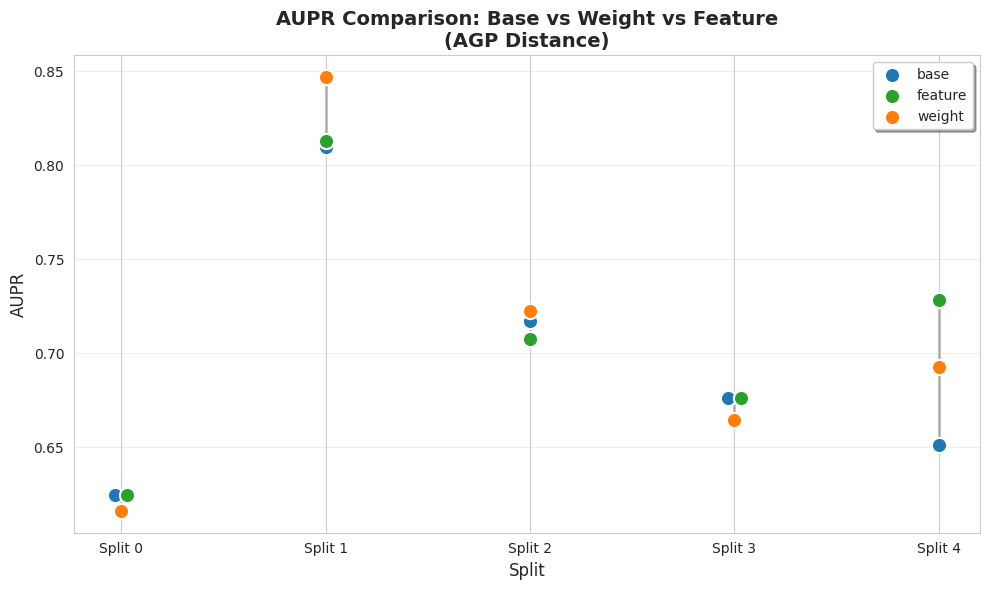


Summary Statistics:
setting      base   feature    weight
count    5.000000  5.000000  5.000000
mean     0.695792  0.709998  0.708440
std      0.072248  0.069553  0.086705
min      0.624764  0.624764  0.616103
25%      0.651166  0.676199  0.664280
50%      0.676199  0.707624  0.692706
75%      0.716979  0.728465  0.722264
max      0.809852  0.812938  0.846845

Mean AUPR by setting:
setting
feature    0.709998
weight     0.708440
base       0.695792
dtype: float64

Range (max - min) by setting:
setting
weight     0.230742
feature    0.188174
base       0.185088
dtype: float64


In [ ]:

sns.set_style("whitegrid")
pivot_data = agp_res_2.pivot(
    index='split',
    columns='setting',
    values='aupr'
)

settings = pivot_data.columns.tolist()  # ['base', 'feature', 'weight']
splits = pivot_data.index.tolist()

fig, ax = plt.subplots(figsize=(10, 6))

colors = {
    'base': '#1f77b4',      # blue
    'weight': '#ff7f0e',    # orange
    'feature': '#2ca02c'    # green
}

x_pos = range(len(splits))

for i, split in enumerate(splits):
    values = pivot_data.loc[split]

    min_val = values.min()
    max_val = values.max()

    ax.plot([i, i], [min_val, max_val],
    color='gray', linewidth=2, alpha=0.5, zorder=1)
    value_counts = values.value_counts()
    duplicate_values = value_counts[value_counts > 1].index

    for j, setting in enumerate(settings):
        y_value = values[setting]

        x_offset = 0
        if y_value in duplicate_values:
            offset_map = {'base': -0.03, 'weight': 0, 'feature': 0.03}
            x_offset = offset_map.get(setting, 0)

        ax.scatter(i + x_offset, y_value,
                  color=colors.get(setting, 'black'),
                  s=120, zorder=2 + j,  # Different z-order for each setting
                  edgecolors='white', linewidths=1.5,
                  label=setting if i == 0 else "")
ax.set_xticks(x_pos)
ax.set_xticklabels([f'Split {s}' for s in splits], rotation=0)
ax.set_xlabel('Split', fontsize=12)
ax.set_ylabel('AUPR', fontsize=12)
ax.set_title('AUPR Comparison: Base vs Weight vs Feature\n(AGP Distance)',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.legend(loc='best', frameon=True, shadow=True)

mean_baseline = pivot_data['base'].mean()

plt.tight_layout()
plt.show()

print("\nSummary Statistics:")
print(pivot_data.describe())
print("\nMean AUPR by setting:")
print(pivot_data.mean().sort_values(ascending=False))
print("\nRange (max - min) by setting:")
print((pivot_data.max() - pivot_data.min()).sort_values(ascending=False))

In [ ]:
from scipy.stats import spearmanr

correlation, p_value = spearmanr(dist, y)
print(f"Spearman correlation: {correlation:.3f}, p-value: {p_value:.3f}")

Spearman correlation: 0.081, p-value: 0.003


### Gan

In [ ]:
def cv_split_syn(r):
    metadata  = pd.read_csv('/content/metadata.csv')
    microbiome = pd.read_csv('/content/microbiome.csv')
    serum_lipo = pd.read_csv('/content/serum_lipo.csv')
    gan_samples = pd.read_csv('/content/mbgan_healthy_010000--0.2817--4.7704.csv')

    metadata['is_sick'] = (metadata['PATGROUPFINAL_C'] != '8').astype(int)
    metadata = metadata.drop(columns=['PATGROUPFINAL_C'])

    taxa_columns = microbiome.drop(columns=['SampleID']).columns

    metabolite_columns = serum_lipo.drop(columns=['SampleID']).columns

    merged = pd.merge(metadata, microbiome, how='inner', on='SampleID')
    merged = pd.merge(merged, serum_lipo, how='inner', on='SampleID')
    merged = merged.drop(columns=['SampleID'])

    X = merged.drop(columns=['is_sick'])
    y = merged['is_sick']


    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y, random_state=r)

    standard_cols = list(metabolite_columns)
    abundance_cols = list(taxa_columns)

    def relative_abundance(X):
        return X.div(X.sum(axis=1), axis=0)

    def std_nan(X):
        return (X - np.nanmean(X)) / np.nanstd(X)

    preprocessor = ColumnTransformer([
    ('standard', FunctionTransformer(std_nan), standard_cols),
    ('abundance', FunctionTransformer(relative_abundance), abundance_cols)
    ], remainder='passthrough', verbose_feature_names_out=False)
    preprocessor.set_output(transform="pandas")

    m_age = np.nanmean(X_train['AGE'])
    s_age = np.nanstd(X_train['AGE'])
    X_train['AGE'] = (X_train['AGE'] - m_age) / s_age
    X_test['AGE'] = (X_test['AGE'] - m_age) / s_age

    m_DDS = np.nanmean(X_train['DDS'])
    s_DDS = np.nanstd(X_train['DDS'])
    X_train['DDS'] = (X_train['DDS'] - m_DDS) / s_DDS
    X_test['DDS'] = (X_test['DDS'] - m_DDS) / s_DDS

    X_train_transformed = preprocessor.fit_transform(X_train)
    X_test_transformed = preprocessor.transform(X_test)

    le = LabelEncoder()
    X_train_transformed['CENTER_C'] = le.fit_transform(X_train_transformed['CENTER_C'])
    X_test_transformed['CENTER_C'] = le.fit_transform(X_test_transformed['CENTER_C'])


    healthy_idx = y_test[y_test == 0].index
    sick_idx = y_test[y_test == 1].index
    n_sick = len(sick_idx)
    n_healthy_current = len(healthy_idx)
    n_healthy_needed = int(n_sick * (0.9 / 0.1))
    n_to_add = n_healthy_needed - n_healthy_current
    additional_healthy_idx = np.random.choice(healthy_idx, size=n_to_add, replace=True)
    all_idx = list(X_test_transformed.index) + list(additional_healthy_idx)
    X_test_transformed = X_test_transformed.loc[all_idx].reset_index(drop=True)
    y_test = y_test.loc[all_idx].reset_index(drop=True)

    X_micro_train = X_train_transformed[abundance_cols]
    X_micro_test = X_test_transformed[abundance_cols]
    X_gan_train = pd.concat([X_micro_train, gan_samples[abundance_cols]], ignore_index=True)
    n = len(gan_samples)
    new_values = pd.Series(np.zeros(n, dtype=np.int64))
    y_gan_train = pd.concat([y_train, new_values], ignore_index=True)



    y_copy=y_train.copy()
    X_copy = X_train_transformed.copy()
    X_copy['label'] = y_copy
    X_copy =X_copy.dropna()
    y_copy = X_copy['label']
    X_copy.drop(columns=['label'], inplace=True)
    n = len(X_copy)
    sm = SVMSMOTE(sampling_strategy=0.35)
    X_resampled, y_resampled = sm.fit_resample(X_copy, y_copy)
    X_add = X_resampled.iloc[n+1:]
    y_add = pd.Series(np.zeros(len(X_add), dtype=np.int64))
    X_train_svmsmote = pd.concat([X_train_transformed, X_add], ignore_index=True)
    y_train_svmsmote = pd.concat([y_train, y_add], ignore_index=True)

    ret = [
        (X_train_transformed, X_test_transformed, y_train, y_test), #baseline
        (X_micro_train, X_micro_test, y_train, y_test), #baseline only microbiome
        (X_gan_train, X_micro_test, y_gan_train, y_test), #base+gan rows
        (X_train_svmsmote, X_test_transformed, y_train_svmsmote, y_test)
    ]

    return ret

In [ ]:
splits = []
seeds = [
 1357996685,
 896042046,
 1077959423,
 2131296414,
 1778132557]
for seed in seeds:
    ret  = cv_split_syn(seed)
    splits.append(ret)

In [ ]:
def test_syn(X_train, X_test, y_train, y_test):
    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',
        enable_categorical=True
    )
    xgb_model.fit(X_train, y_train)
    y_pred = xgb_model.predict(X_test)
    y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]  # Probabilities for positive class

    sklearn_ap = average_precision_score(y_test, y_pred_proba)

    return sklearn_ap

res_syn = []
for j, split in enumerate(splits):
    X_train_transformed, X_test_transformed, y_train, y_test = split[0]
    baseline_aupr = test_syn(X_train_transformed, X_test_transformed, y_train, y_test)

    X_micro_train, X_micro_test, y_train, y_test = split[1]
    base_micro_aupr = test_syn(X_micro_train, X_micro_test, y_train, y_test)

    X_gan_train, X_gan_test, y_gan_train, y_test = split[2]
    gan_aupr = test_syn(X_gan_train, X_gan_test, y_gan_train, y_test)

    X_train_svmsmote, X_test, y_train_svmsmote, y_test = split[3]
    svmsmote_aupr = test_syn(X_train_svmsmote, X_test, y_train_svmsmote, y_test)

    res_syn.append({
        'split': j,
        'baseline_aupr': baseline_aupr,
        'base_micro_aupr': base_micro_aupr,
        'gan_aupr': gan_aupr,
        'svmsmote_aupr': svmsmote_aupr
    })

res_syn_df = pd.DataFrame(res_syn)

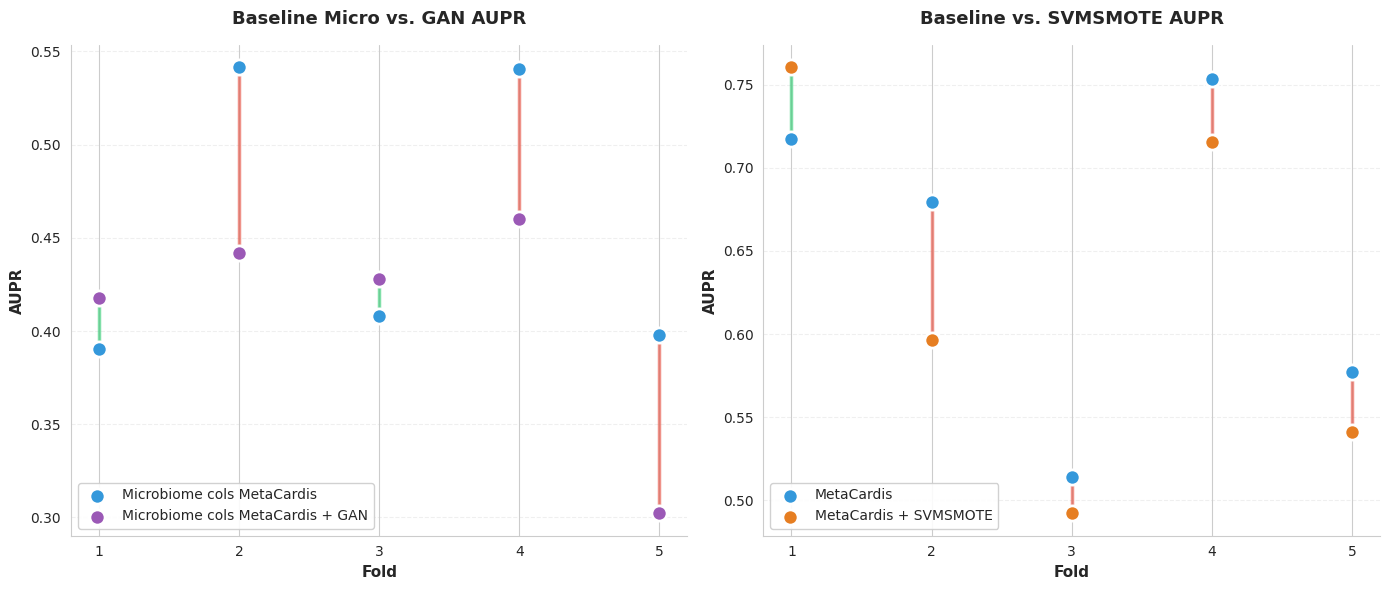

In [ ]:
# Set seaborn style
sns.set_style("whitegrid")

# Prepare data
samples = ['1', '2', '3', '4', '5']
baseline = res_syn_df['baseline_aupr']
base_micro = res_syn_df['base_micro_aupr']
gan = res_syn_df['gan_aupr']
svmsmote = res_syn_df['svmsmote_aupr']

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

x_pos = range(len(samples))

# Plot 1: Baseline Micro vs GAN
for i, sample in enumerate(samples):
    color = '#2ecc71' if gan[i] > base_micro[i] else '#e74c3c'
    # Draw connecting line
    ax1.plot([i, i], [base_micro[i], gan[i]],
            color=color, linewidth=2.5, alpha=0.6, zorder=1)
    # Draw markers
    ax1.scatter(i, base_micro[i], color='#3498db', s=120, zorder=2,
               label='Microbiome cols MetaCardis' if i == 0 else '', edgecolors='white', linewidths=2)
    ax1.scatter(i, gan[i], color='#9b59b6', s=120, zorder=2,
               label='Microbiome cols MetaCardis + GAN' if i == 0 else '', edgecolors='white', linewidths=2)

ax1.set_xticks(x_pos)
ax1.set_xticklabels(samples)
ax1.set_xlabel('Fold', fontsize=11, fontweight='bold')
ax1.set_title('Baseline Micro vs. GAN AUPR', fontsize=13, fontweight='bold', pad=15)
ax1.set_ylabel('AUPR', fontsize=11, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y', linestyle='--')
ax1.legend(loc='best', framealpha=0.9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Plot 2: Baseline vs SVMSMOTE
for i, sample in enumerate(samples):
    color = '#2ecc71' if svmsmote[i] > baseline[i] else '#e74c3c'
    # Draw connecting line
    ax2.plot([i, i], [baseline[i], svmsmote[i]],
            color=color, linewidth=2.5, alpha=0.6, zorder=1)
    # Draw markers
    ax2.scatter(i, baseline[i], color='#3498db', s=120, zorder=2,
               label='MetaCardis' if i == 0 else '', edgecolors='white', linewidths=2)
    ax2.scatter(i, svmsmote[i], color='#e67e22', s=120, zorder=2,
               label='MetaCardis + SVMSMOTE' if i == 0 else '', edgecolors='white', linewidths=2)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(samples)
ax2.set_xlabel('Fold', fontsize=11, fontweight='bold')
ax2.set_title('Baseline vs. SVMSMOTE AUPR', fontsize=13, fontweight='bold', pad=15)
ax2.set_ylabel('AUPR', fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y', linestyle='--')
ax2.legend(loc='best', framealpha=0.9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
